# Multilingual AI-Generated Text Detection Experiments

This notebook presents the multilingual AI-generated text detection experiments conducted using the processed MultiSocial benchmark dataset.

The study focuses on fine-tuning and analysing a multilingual mDeBERTa classifier across the multilingual social-media setting provided by MultiSocial. In addition to evaluating predictive performance, the notebook investigates model robustness across languages, social-media platforms and AI text generators, and applies both SHAP-based explainability and style-based analyses to examine the textual evidence underlying the classifier's predictions.

The experimental pipeline includes:

1. **Loading and inspecting** the processed MultiSocial benchmark dataset.
2. **Preparing** the multilingual training and benchmark test partitions.
3. **Constructing** a reproducible and language-aware development sample while preserving the benchmark test set.
4. **Fine-tuning** a multilingual mDeBERTa classifier for Human versus AI-generated text detection.
5. **Evaluating** overall, class-specific and probability-based detection performance.
6. **Comparing** detection performance across languages, social-media platforms and AI text generators.
7. **Conducting** leave-one-generator-out experiments to evaluate generator generalisation.
8. **Performing** global, directional, language-specific and generator-specific SHAP analyses to identify influential textual features.
9. **Examining** cross-language explanation consistency and language-dependent attribution patterns.
10. **Investigating** explanation patterns associated with correct predictions and prediction errors.
11. **Analysing** observable stylistic differences between Human-written and AI-generated texts using interpretable style features.
12. **Comparing** style characteristics across prediction outcomes and prediction error types.
13. **Examining** representative local SHAP explanations for correctly and incorrectly classified benchmark texts.

> **Repository data-safety note.** The MultiSocial dataset is access-restricted and is not included in this repository. Saved outputs that reproduced individual dataset texts were removed from this GitHub copy. Aggregate metrics, tables, figures, and other non-record-level outputs have been retained where possible. See the repository README for access and reproduction instructions.


## 1. Import Libraries

The required libraries are imported for data manipulation, numerical operations, reproducibility, visualisation and initial dataset inspection. Model-specific and explainability libraries are imported later when the corresponding experimental stages are introduced.

In [ ]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 120)

print("Random seed:", SEED)

Random seed: 42


## 2. Load the Processed MultiSocial Dataset

The processed MultiSocial benchmark dataset prepared during the preceding data-preparation stage is loaded for the multilingual experiments. The initial inspection verifies the dataset dimensions, available variables and predefined benchmark partitions before any model-development sampling is performed.



In [ ]:
df = pd.read_csv("multisocial_processed.csv")

print("Dataset shape:", df.shape)
print("\nAvailable columns:")
print(df.columns.tolist())

print("\nBenchmark split distribution:")
display(
    df["split"]
    .value_counts()
    .rename_axis("Split")
    .reset_index(name="Samples")
)

print("Number of languages:", df["language"].nunique())
print("Languages:", sorted(df["language"].dropna().unique()))

print("\nLabel distribution:")
display(
    df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("Label")
    .reset_index(name="Samples")
)

print("\nPlatforms:")
display(
    df["platform"]
    .value_counts()
    .rename_axis("Platform")
    .reset_index(name="Samples")
)

print("\nGenerator / source labels:")
display(
    df["multi_label"]
    .value_counts(dropna=False)
    .rename_axis("Generator")
    .reset_index(name="Samples")
)

Dataset shape: (472097, 9)

Available columns:
['text', 'label', 'multi_label', 'split', 'language', 'length', 'source', 'potential_noise', 'platform']

Benchmark split distribution:


,Split,Samples
0,train,331209
1,test,140888


Number of languages: 22
Languages: ['ar', 'bg', 'ca', 'cs', 'de', 'el', 'en', 'es', 'et', 'ga', 'gd', 'hr', 'hu', 'nl', 'pl', 'pt', 'ro', 'ru', 'sk', 'sl', 'uk', 'zh']

Label distribution:


,Label,Samples
0,0,57990
1,1,414107



Platforms:


,Platform,Samples
0,telegram,178091
1,discord,107785
2,gab,80968
3,twitter,74145
4,whatsapp,31108



Generator / source labels:


,Generator,Samples
0,Mistral-7B-Instruct-v0.2,61305
1,v5-Eagle-7B-HF,61057
2,vicuna-13b,60346
3,gemini,59559
4,gpt-3.5-turbo-0125,58851
5,human,57990
6,aya-101,57566
7,opt-iml-max-30b,55423


The processed dataset contains 472,097 social-media texts distributed across 22 languages and five social-media platforms. The predefined benchmark consists of 331,209 training samples and 140,888 benchmark test samples.

The overall dataset is substantially imbalanced, containing 414,107 AI-generated texts (87.72%) and 57,990 Human-written texts (12.28%). AI-generated samples originate from seven different text generators, whereas the Human-written class is represented by a dedicated source label.

Variation is also observed across languages, platforms and generator sources. Since model development is performed exclusively on the predefined training partition, these distributions are examined in greater detail after separating the benchmark train and test sets.

## 3. Preserve the Benchmark Train and Test Partitions

The predefined MultiSocial training and test partitions are separated before any sampling is performed. All sampling and model-development decisions are restricted to the original training partition, while the benchmark test partition is retained unchanged for final evaluation.

This separation prevents information from the benchmark test set from influencing model training, validation or model-selection decisions, thereby reducing the risk of data leakage and preserving the integrity of the final benchmark evaluation.

In [ ]:
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Benchmark test samples:", len(test_df))

assert len(train_df) == 331209
assert len(test_df) == 140888
assert len(train_df) + len(test_df) == len(df)

print("\nBenchmark partitions successfully preserved.")

Training samples: 331209
Benchmark test samples: 140888

Benchmark partitions successfully preserved.


## 4. Text Preprocessing Strategy

No additional text cleaning or linguistic normalisation is applied to the processed social-media texts. The textual characteristics retained during the data-preparation stage—including punctuation, casing, emojis, hashtags, URLs and other social-media-specific elements—are preserved throughout the experiment.

This decision is important because such characteristics may provide relevant signals for distinguishing Human-written and AI-generated texts and are subsequently examined through the explainability analyses. Removing or normalising these elements could alter the evidence available to the classifier and reduce the interpretability of its learned decision patterns.

The only subsequent transformations involve dataset sampling, partitioning and model-specific tokenisation. No text content is manually removed, rewritten or normalised before tokenisation.

## 5. Inspect the Training Distribution

Before defining the sampling strategy, the original training partition is examined in greater detail. Particular attention is given to class balance, language representation and generator coverage, since these dimensions are directly relevant to the multilingual experimental design.

The purpose of this inspection is to determine whether proportional sampling, class balancing or a language-aware sampling strategy is most appropriate, while avoiding unnecessary reductions in the representation of languages with fewer available training samples.

In [ ]:
# Class distribution in the original training partition

train_class_distribution = (
    train_df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("Label")
    .reset_index(name="Samples")
)

train_class_distribution["Class"] = train_class_distribution["Label"].map({
    0: "Human",
    1: "AI"
})

train_class_distribution["Percentage"] = (
    train_class_distribution["Samples"]
    / len(train_df)
    * 100
).round(2)

train_class_distribution = train_class_distribution[
    ["Label", "Class", "Samples", "Percentage"]
]

display(train_class_distribution)

,Label,Class,Samples,Percentage
0,0,Human,40591,12.26
1,1,AI,290618,87.74


In [ ]:
# Language distribution in the original training partition

train_language_distribution = (
    train_df["language"]
    .value_counts()
    .rename_axis("Language")
    .reset_index(name="Samples")
)

train_language_distribution["Percentage"] = (
    train_language_distribution["Samples"]
    / len(train_df)
    * 100
).round(2)

display(train_language_distribution)

,Language,Samples,Percentage
0,es,39081,11.80
1,en,39026,11.78
2,pt,33453,10.10
3,nl,30974,9.35
4,de,21245,6.41
5,pl,16720,5.05
6,ru,16064,4.85
7,ar,15596,4.71
8,bg,15485,4.68
9,ro,15143,4.57


In [ ]:
# Human and AI representation within each training language

language_class_distribution = pd.crosstab(
    train_df["language"],
    train_df["label"]
)

language_class_distribution = language_class_distribution.rename(
    columns={
        0: "Human",
        1: "AI"
    }
)

for column in ["Human", "AI"]:
    if column not in language_class_distribution.columns:
        language_class_distribution[column] = 0

language_class_distribution["Total"] = (
    language_class_distribution["Human"]
    + language_class_distribution["AI"]
)

language_class_distribution["Human %"] = (
    language_class_distribution["Human"]
    / language_class_distribution["Total"]
    * 100
).round(2)

language_class_distribution["AI %"] = (
    language_class_distribution["AI"]
    / language_class_distribution["Total"]
    * 100
).round(2)

language_class_distribution = (
    language_class_distribution
    .sort_values("Total", ascending=False)
)

display(language_class_distribution)

label,Human,AI,Total,Human %,AI %
language,,,,,
es,4918,34163,39081,12.58,87.42
en,4850,34176,39026,12.43,87.57
pt,4193,29260,33453,12.53,87.47
nl,3718,27256,30974,12.00,88.00
de,2605,18640,21245,12.26,87.74
pl,1872,14848,16720,11.20,88.80
ru,2033,14031,16064,12.66,87.34
ar,1967,13629,15596,12.61,87.39
bg,1960,13525,15485,12.66,87.34


In [ ]:
# Compare language coverage between the predefined train and test partitions

train_languages = set(train_df["language"].dropna().unique())
test_languages = set(test_df["language"].dropna().unique())

shared_languages = sorted(train_languages & test_languages)
train_only_languages = sorted(train_languages - test_languages)
test_only_languages = sorted(test_languages - train_languages)

print("Languages in training:", len(train_languages))
print("Languages in benchmark test:", len(test_languages))

print("\nShared languages:")
print(shared_languages)

print("\nTrain-only languages:")
print(train_only_languages)

print("\nTest-only languages:")
print(test_only_languages)

Languages in training: 18
Languages in benchmark test: 22

Shared languages:
['ar', 'bg', 'ca', 'cs', 'de', 'el', 'en', 'es', 'et', 'hr', 'hu', 'nl', 'pl', 'pt', 'ro', 'ru', 'uk', 'zh']

Train-only languages:
[]

Test-only languages:
['ga', 'gd', 'sk', 'sl']


In [ ]:
# Generator distribution in the original training partition

train_generator_distribution = (
    train_df["multi_label"]
    .value_counts(dropna=False)
    .rename_axis("Generator")
    .reset_index(name="Samples")
)

train_generator_distribution["Percentage"] = (
    train_generator_distribution["Samples"]
    / len(train_df)
    * 100
).round(2)

display(train_generator_distribution)

,Generator,Samples,Percentage
0,Mistral-7B-Instruct-v0.2,42954,12.97
1,v5-Eagle-7B-HF,42802,12.92
2,vicuna-13b,42274,12.76
3,gemini,42189,12.74
4,gpt-3.5-turbo-0125,41198,12.44
5,human,40591,12.26
6,aya-101,40355,12.18
7,opt-iml-max-30b,38846,11.73


In [ ]:
# Generator representation across training languages

language_generator_distribution = pd.crosstab(
    train_df["language"],
    train_df["multi_label"]
)

display(language_generator_distribution)

multi_label,Mistral-7B-Instruct-v0.2,aya-101,gemini,gpt-3.5-turbo-0125,human,opt-iml-max-30b,v5-Eagle-7B-HF,vicuna-13b
language,,,,,,,,
ar,1914,1912,1996,1950,1967,1898,1964,1995
bg,1970,1821,1970,1928,1960,1942,1956,1938
ca,1976,1741,1139,1911,1852,1727,1975,1820
cs,1476,1354,1471,1324,1324,1270,1463,1458
de,2729,2649,2728,2636,2605,2488,2705,2705
el,491,458,498,471,485,420,494,497
en,4998,4819,4989,4918,4850,4580,4948,4924
es,4997,4728,4990,4889,4918,4704,4971,4884
et,1984,1805,1988,1774,1569,1460,1972,1942


The original training partition is substantially imbalanced towards the AI-generated class, with a broadly similar class ratio across the 18 training languages. Generator representation is comparatively balanced, while language sample sizes vary considerably. Four languages—Irish, Scottish Gaelic, Slovak and Slovenian—are absent from training and occur only in the benchmark test partition.

### 5.1 Platform Representation in the Training Partition

Since platform-specific performance forms part of the subsequent robustness analysis, platform representation is also examined before constructing the training sample. This check determines whether the observed class imbalance remains broadly consistent across social-media platforms and whether the proposed language-aware sampling strategy could unintentionally distort platform representation.

In [ ]:
# Platform and class distribution in the original training partition

platform_class_distribution = pd.crosstab(
    train_df["platform"],
    train_df["label"]
)

platform_class_distribution = platform_class_distribution.rename(
    columns={
        0: "Human",
        1: "AI"
    }
)

platform_class_distribution["Total"] = (
    platform_class_distribution["Human"]
    + platform_class_distribution["AI"]
)

platform_class_distribution["Human %"] = (
    platform_class_distribution["Human"]
    / platform_class_distribution["Total"]
    * 100
).round(2)

platform_class_distribution["AI %"] = (
    platform_class_distribution["AI"]
    / platform_class_distribution["Total"]
    * 100
).round(2)

platform_class_distribution = (
    platform_class_distribution
    .sort_values("Total", ascending=False)
)

display(platform_class_distribution)

label,Human,AI,Total,Human %,AI %
platform,,,,,
telegram,17093,116151,133244,12.83,87.17
discord,8539,71079,79618,10.72,89.28
gab,6262,43615,49877,12.55,87.45
twitter,6146,42384,48530,12.66,87.34
whatsapp,2551,17389,19940,12.79,87.21


In [ ]:
# Language representation across platforms

language_platform_distribution = pd.crosstab(
    train_df["language"],
    train_df["platform"]
)

display(language_platform_distribution)

platform,discord,gab,telegram,twitter,whatsapp
language,,,,,
ar,0,0,7724,7872,0
bg,0,0,7555,7930,0
ca,6984,0,7157,0,0
cs,3450,0,7690,0,0
de,3407,7863,7880,2095,0
el,0,0,3814,0,0
en,7789,7760,7824,7871,7782
es,7588,7883,7884,7922,7804
et,6974,0,7520,0,0


The original training partition exhibits a broadly consistent Human–AI class ratio across all five platforms. Although languages are not uniformly represented across platforms, no platform shows an extreme class imbalance that would require platform-specific sampling. Therefore, the subsequent language-aware sampling strategy is expected to preserve the benchmark's platform composition without introducing substantial distortion.

## 6. Construct the Language-Aware Balanced Development Sample

The original training partition is substantially imbalanced towards AI-generated texts, with 87.74% AI-generated and 12.26% Human-written samples. A similar imbalance is observed across the individual training languages.

To reduce the computational requirements of model development without further reducing the minority Human-written class, a language-aware class-balancing strategy is applied.

All available Human-written training samples are retained. Within each of the 18 training languages, an equal number of AI-generated samples is selected from the set of seen generators. AI sampling is stratified by generator so that the relative generator composition within each language is approximately preserved. No oversampling or synthetic sample generation is applied.

Following the unseen-generator evaluation setup adopted in the MultiSocial benchmark, Gemini-generated samples are excluded from model development and reserved exclusively for unseen-generator evaluation. This benchmark design enables a controlled assessment of the model's ability to generalise to outputs produced by a previously unseen generator while preserving comparability with the original benchmark protocol.

Platform is not used as an additional sampling stratum because the class imbalance is broadly similar across platforms and platform availability differs substantially across languages. Instead, language, generator and platform distributions are examined after sampling to verify that the resulting development dataset remains representative of the original training partition.

The predefined benchmark test partition remains unchanged throughout the sampling procedure.

In [ ]:
from sklearn.model_selection import train_test_split

# Sampling configuration
HUMAN_LABEL = 0
AI_LABEL = 1

UNSEEN_GENERATOR = "gemini"
SAMPLING_RANDOM_STATE = 42

# Retain all Human-written training samples
human_train_df = (
    train_df[
        train_df["label"] == HUMAN_LABEL
    ]
    .copy()
    .reset_index(drop=True)
)

# Retain only seen-generator AI samples for model development
seen_ai_train_df = (
    train_df[
        (train_df["label"] == AI_LABEL)
        & (train_df["multi_label"] != UNSEEN_GENERATOR)
    ]
    .copy()
    .reset_index(drop=True)
)

# Keep Gemini samples separate for unseen-generator evaluation
gemini_train_df = (
    train_df[
        (train_df["label"] == AI_LABEL)
        & (train_df["multi_label"] == UNSEEN_GENERATOR)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Human training samples retained:", len(human_train_df))
print("Eligible seen-generator AI samples:", len(seen_ai_train_df))
print("Gemini samples excluded from model development:", len(gemini_train_df))

Human training samples retained: 40591
Eligible seen-generator AI samples: 248429
Gemini samples excluded from model development: 42189


In [ ]:
sampled_ai_parts = []
sampling_summary = []

training_languages = sorted(
    human_train_df["language"]
    .dropna()
    .unique()
)

for language in training_languages:

    # Retain all Human samples in the current language
    language_human_df = human_train_df[
        human_train_df["language"] == language
    ]

    n_human = len(language_human_df)

    # Eligible seen-generator AI samples in the same language
    language_ai_df = seen_ai_train_df[
        seen_ai_train_df["language"] == language
    ].copy()

    n_ai_available = len(language_ai_df)

    if n_ai_available < n_human:
        raise ValueError(
            f"Not enough eligible AI samples for language '{language}': "
            f"{n_ai_available} AI available for {n_human} Human samples."
        )

    # Select the same number of AI samples while preserving
    # the relative generator composition within the language
    sampled_language_ai_df, _ = train_test_split(
        language_ai_df,
        train_size=n_human,
        stratify=language_ai_df["multi_label"],
        random_state=SAMPLING_RANDOM_STATE
    )

    sampled_ai_parts.append(
        sampled_language_ai_df
    )

    sampling_summary.append({
        "Language": language,
        "Human retained": n_human,
        "Seen AI available": n_ai_available,
        "AI sampled": len(sampled_language_ai_df)
    })

sampling_summary_df = pd.DataFrame(
    sampling_summary
)

display(sampling_summary_df)

,Language,Human retained,Seen AI available,AI sampled
0,ar,1967,11633,1967
1,bg,1960,11555,1960
2,ca,1852,11150,1852
3,cs,1324,8345,1324
4,de,2605,15912,2605
5,el,485,2831,485
6,en,4850,29187,4850
7,es,4918,29173,4918
8,et,1569,10937,1569
9,hr,1762,10893,1762


In [ ]:
sampled_ai_df = pd.concat(
    sampled_ai_parts,
    ignore_index=True
)

# Confirm equal Human and AI sample counts
assert len(sampled_ai_df) == len(human_train_df)

# Combine and reproducibly shuffle the balanced dataset
development_df = (
    pd.concat(
        [
            human_train_df,
            sampled_ai_df
        ],
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=SAMPLING_RANDOM_STATE
    )
    .reset_index(drop=True)
)

print("Human samples retained:", len(human_train_df))
print("AI samples selected:", len(sampled_ai_df))
print("Development dataset size:", len(development_df))

Human samples retained: 40591
AI samples selected: 40591
Development dataset size: 81182


In [ ]:
# Overall class distribution

development_class_distribution = (
    development_df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("Label")
    .reset_index(name="Samples")
)

development_class_distribution["Class"] = (
    development_class_distribution["Label"]
    .map({
        0: "Human",
        1: "AI"
    })
)

development_class_distribution["Percentage"] = (
    development_class_distribution["Samples"]
    / len(development_df)
    * 100
).round(2)

development_class_distribution = (
    development_class_distribution[
        [
            "Label",
            "Class",
            "Samples",
            "Percentage"
        ]
    ]
)

print("Overall class distribution:")
display(development_class_distribution)


# Language-specific class distribution

development_language_class = pd.crosstab(
    development_df["language"],
    development_df["label"]
).rename(
    columns={
        0: "Human",
        1: "AI"
    }
)

development_language_class["Total"] = (
    development_language_class["Human"]
    + development_language_class["AI"]
)

development_language_class["Human %"] = (
    development_language_class["Human"]
    / development_language_class["Total"]
    * 100
).round(2)

development_language_class["AI %"] = (
    development_language_class["AI"]
    / development_language_class["Total"]
    * 100
).round(2)

development_language_class = (
    development_language_class
    .sort_values(
        "Total",
        ascending=False
    )
)

print("Class balance within each training language:")
display(development_language_class)

Overall class distribution:


,Label,Class,Samples,Percentage
0,0,Human,40591,50.0
1,1,AI,40591,50.0


Class balance within each training language:


label,Human,AI,Total,Human %,AI %
language,,,,,
es,4918,4918,9836,50.0,50.0
en,4850,4850,9700,50.0,50.0
pt,4193,4193,8386,50.0,50.0
nl,3718,3718,7436,50.0,50.0
de,2605,2605,5210,50.0,50.0
ru,2033,2033,4066,50.0,50.0
ar,1967,1967,3934,50.0,50.0
bg,1960,1960,3920,50.0,50.0
pl,1872,1872,3744,50.0,50.0


In [ ]:
original_seen_generator_proportions = (
    seen_ai_train_df["multi_label"]
    .value_counts(normalize=True)
    .rename("Original seen-AI %")
)

sampled_generator_proportions = (
    sampled_ai_df["multi_label"]
    .value_counts(normalize=True)
    .rename("Sampled AI %")
)

generator_proportion_comparison = pd.concat(
    [
        original_seen_generator_proportions,
        sampled_generator_proportions
    ],
    axis=1
).fillna(0)

generator_proportion_comparison = (
    generator_proportion_comparison
    * 100
).round(2)

generator_proportion_comparison[
    "Absolute difference (pp)"
] = (
    generator_proportion_comparison[
        "Original seen-AI %"
    ]
    - generator_proportion_comparison[
        "Sampled AI %"
    ]
).abs().round(2)

display(generator_proportion_comparison)

,Original seen-AI %,Sampled AI %,Absolute difference (pp)
multi_label,,,
Mistral-7B-Instruct-v0.2,17.29,17.28,0.01
v5-Eagle-7B-HF,17.23,17.22,0.01
vicuna-13b,17.02,17.00,0.02
gpt-3.5-turbo-0125,16.58,16.59,0.01
aya-101,16.24,16.24,0.00
opt-iml-max-30b,15.64,15.67,0.03


In [ ]:
# Compare language proportions before and after sampling

original_language_proportions = (
    train_df["language"]
    .value_counts(normalize=True)
    .rename("Original train %")
)

development_language_proportions = (
    development_df["language"]
    .value_counts(normalize=True)
    .rename("Development sample %")
)

language_proportion_comparison = pd.concat(
    [
        original_language_proportions,
        development_language_proportions
    ],
    axis=1
).fillna(0)

language_proportion_comparison = (
    language_proportion_comparison
    * 100
).round(2)

language_proportion_comparison[
    "Absolute difference (pp)"
] = (
    language_proportion_comparison[
        "Original train %"
    ]
    - language_proportion_comparison[
        "Development sample %"
    ]
).abs().round(2)

language_proportion_comparison = (
    language_proportion_comparison
    .sort_values(
        "Original train %",
        ascending=False
    )
)

print("Language representation before and after sampling:")
display(language_proportion_comparison)


# Compare platform proportions before and after sampling

original_platform_proportions = (
    train_df["platform"]
    .value_counts(normalize=True)
    .rename("Original train %")
)

development_platform_proportions = (
    development_df["platform"]
    .value_counts(normalize=True)
    .rename("Development sample %")
)

platform_proportion_comparison = pd.concat(
    [
        original_platform_proportions,
        development_platform_proportions
    ],
    axis=1
).fillna(0)

platform_proportion_comparison = (
    platform_proportion_comparison
    * 100
).round(2)

platform_proportion_comparison[
    "Absolute difference (pp)"
] = (
    platform_proportion_comparison[
        "Original train %"
    ]
    - platform_proportion_comparison[
        "Development sample %"
    ]
).abs().round(2)

print("Platform representation before and after sampling:")
display(platform_proportion_comparison)

Language representation before and after sampling:


,Original train %,Development sample %,Absolute difference (pp)
language,,,
es,11.80,12.12,0.32
en,11.78,11.95,0.17
pt,10.10,10.33,0.23
nl,9.35,9.16,0.19
de,6.41,6.42,0.01
pl,5.05,4.61,0.44
ru,4.85,5.01,0.16
ar,4.71,4.85,0.14
bg,4.68,4.83,0.15


Platform representation before and after sampling:


,Original train %,Development sample %,Absolute difference (pp)
platform,,,
telegram,40.23,41.07,0.84
discord,24.04,22.55,1.49
gab,15.06,15.22,0.16
twitter,14.65,14.95,0.30
whatsapp,6.02,6.21,0.19


In [ ]:
# Final sampling integrity checks

assert len(development_df) == 81182

assert (
    development_df["label"]
    .value_counts()[HUMAN_LABEL]
    ==
    development_df["label"]
    .value_counts()[AI_LABEL]
)

assert (
    development_df["multi_label"]
    .eq(UNSEEN_GENERATOR)
    .sum()
    == 0
)

assert (
    set(development_df["language"].unique())
    ==
    set(train_df["language"].unique())
)

assert len(test_df) == 140888

print("All sampling integrity checks passed.")
print("Development dataset:", len(development_df))
print("Training languages retained:", development_df["language"].nunique())
print("Gemini samples in development:", 0)
print("Benchmark test samples retained:", len(test_df))

All sampling integrity checks passed.
Development dataset: 81182
Training languages retained: 18
Gemini samples in development: 0
Benchmark test samples retained: 140888


In [ ]:
sampling_validation_summary = pd.DataFrame({
    "Validation criterion": [
        "Development dataset size",
        "Human-written samples",
        "AI-generated samples",
        "Human / AI distribution",
        "Training languages retained",
        "Maximum language proportion change",
        "Maximum generator proportion change",
        "Maximum platform proportion change",
        "Gemini samples in development",
        "Benchmark test samples retained"
    ],
    "Result": [
        f"{len(development_df):,}",
        f"{(development_df['label'] == HUMAN_LABEL).sum():,}",
        f"{(development_df['label'] == AI_LABEL).sum():,}",
        "50% / 50%",
        f"{development_df['language'].nunique()} / {train_df['language'].nunique()}",
        f"{language_proportion_comparison['Absolute difference (pp)'].max():.2f} pp",
        f"{generator_proportion_comparison['Absolute difference (pp)'].max():.2f} pp",
        f"{platform_proportion_comparison['Absolute difference (pp)'].max():.2f} pp",
        f"{development_df['multi_label'].eq(UNSEEN_GENERATOR).sum()}",
        f"{len(test_df):,} / 140,888"
    ]
})

display(sampling_validation_summary)

,Validation criterion,Result
0,Development dataset size,"81,182"
1,Human-written samples,"40,591"
2,AI-generated samples,"40,591"
3,Human / AI distribution,50% / 50%
4,Training languages retained,18 / 18
5,Maximum language proportion change,0.51 pp
6,Maximum generator proportion change,0.03 pp
7,Maximum platform proportion change,1.49 pp
8,Gemini samples in development,0
9,Benchmark test samples retained,"140,888 / 140,888"


The sampling procedure produced a balanced development dataset of 81,182 samples, containing 40,591 Human-written and 40,591 AI-generated texts. All 18 training languages were retained, and each language was independently balanced between the two classes.

The sampling procedure introduced only minor changes to the broader data composition. The maximum absolute differences between the original and sampled distributions were 0.03 percentage points for seen generators, 0.51 percentage points for languages and 1.49 percentage points for social-media platforms. This indicates that the reduction in training size and class balancing were achieved while largely preserving the multilingual, generator and platform characteristics of the original training partition.

No Gemini-generated samples were included in model development, and the complete benchmark test partition of 140,888 samples was retained unchanged for final evaluation. Consequently, the benchmark evaluation remains fully independent of all sampling decisions performed during model development, ensuring a fair assessment of the model's generalisation performance.

## 7. Create Training and Validation Sets

The balanced development dataset is divided into model training and validation subsets using a reproducible 90:10 split. Joint stratification by language and class label is applied so that each training language retains the same Human–AI class balance while preserving approximately the same language representation across both subsets.

The benchmark test partition remains completely separate throughout this procedure and is not used for model selection, hyperparameter tuning or any other development decisions.

In [ ]:
# Create a joint language-class stratification variable

development_df["stratify_group"] = (
    development_df["language"].astype(str)
    + "_"
    + development_df["label"].astype(str)
)

model_train_df, validation_df = train_test_split(
    development_df,
    test_size=0.10,
    stratify=development_df["stratify_group"],
    random_state=SEED
)

model_train_df = (
    model_train_df
    .drop(columns="stratify_group")
    .reset_index(drop=True)
)

validation_df = (
    validation_df
    .drop(columns="stratify_group")
    .reset_index(drop=True)
)

# Remove temporary column from the full development dataframe
development_df = (
    development_df
    .drop(columns="stratify_group")
)

print("Development dataset:", len(development_df))
print("Model training samples:", len(model_train_df))
print("Validation samples:", len(validation_df))
print("Benchmark test samples:", len(test_df))

Development dataset: 81182
Model training samples: 73063
Validation samples: 8119
Benchmark test samples: 140888


In [ ]:
# Verify class and language representation after splitting

split_class_comparison = pd.DataFrame({
    "Model train": (
        model_train_df["label"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ),
    "Validation": (
        validation_df["label"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )
}).round(2)

split_class_comparison.index = ["Human", "AI"]

print("Class distribution (%):")
display(split_class_comparison)


train_language_proportions = (
    model_train_df["language"]
    .value_counts(normalize=True)
    .rename("Model train %")
)

validation_language_proportions = (
    validation_df["language"]
    .value_counts(normalize=True)
    .rename("Validation %")
)

split_language_comparison = pd.concat(
    [
        train_language_proportions,
        validation_language_proportions
    ],
    axis=1
).fillna(0)

split_language_comparison = (
    split_language_comparison * 100
).round(2)

split_language_comparison["Absolute difference (pp)"] = (
    split_language_comparison["Model train %"]
    - split_language_comparison["Validation %"]
).abs().round(2)

display(
    split_language_comparison.sort_values(
        "Model train %",
        ascending=False
    )
)

Class distribution (%):


,Model train,Validation
Human,50.0,49.99
AI,50.0,50.01


,Model train %,Validation %,Absolute difference (pp)
language,,,
es,12.12,12.12,0.00
en,11.95,11.95,0.00
pt,10.33,10.32,0.01
nl,9.16,9.16,0.00
de,6.42,6.43,0.01
ru,5.01,5.00,0.01
ar,4.85,4.85,0.00
bg,4.83,4.83,0.00
pl,4.61,4.61,0.00


In [ ]:
# Final split integrity checks

assert len(model_train_df) + len(validation_df) == len(development_df)

assert set(model_train_df["language"].unique()) == set(
    development_df["language"].unique()
)

assert set(validation_df["language"].unique()) == set(
    development_df["language"].unique()
)

assert not model_train_df["multi_label"].eq(UNSEEN_GENERATOR).any()
assert not validation_df["multi_label"].eq(UNSEEN_GENERATOR).any()

print("Train-validation integrity checks passed.")

Train-validation integrity checks passed.


The 90:10 split produced 73,063 training samples and 8,119 validation samples. Joint stratification by language and class preserved the balanced Human–AI distribution and maintained nearly identical language proportions across the two subsets, with a maximum difference of 0.01 percentage points.

All 18 training languages remain represented in both subsets, while Gemini-generated samples remain excluded from model development. The benchmark test set remains completely separate and unchanged for final evaluation, ensuring that model selection and hyperparameter tuning are performed without reference to the benchmark data.

## 8. Load the mDeBERTa-v3-base Tokenizer

The tokenizer associated with mDeBERTa-v3-base is loaded to prepare multilingual social-media texts for transformer-based classification. Using the tokenizer corresponding to the selected pretrained model ensures that input texts are converted into the subword representations expected during model fine-tuning.

Before selecting the maximum input sequence length, token lengths are examined using only the model training subset. This enables the truncation threshold to be determined empirically from the training data while ensuring that the validation and benchmark test sets do not influence this preprocessing decision.

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/mdeberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Model:", MODEL_NAME)
print("Tokenizer vocabulary size:", tokenizer.vocab_size)
print("Tokenizer model maximum length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 4.31MB            

spm.model: downloading bytes:           |  0.00B            

Model: microsoft/mdeberta-v3-base
Tokenizer vocabulary size: 250101
Tokenizer model maximum length: 1000000000000000019884624838656


## 9. Analyse Token Sequence Lengths

Token sequence lengths are examined on the model training subset before padding or truncation is applied. Since multilingual subword tokenisation may produce different sequence lengths across languages, the distribution is analysed using the selected mDeBERTa tokenizer.

The objective is to determine an appropriate maximum input sequence length that preserves the vast majority of training texts while avoiding unnecessary computational cost associated with substantially longer sequences.

In [ ]:
train_texts = (
    model_train_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

encoded_train = tokenizer(
    train_texts,
    add_special_tokens=True,
    truncation=False,
    padding=False,
    return_attention_mask=False
)

train_token_lengths = np.array(
    [
        len(input_ids)
        for input_ids in encoded_train["input_ids"]
    ]
)

print(
    "Number of training texts:",
    len(train_token_lengths)
)

Number of training texts: 73063


In [ ]:
token_length_summary = pd.Series(
    train_token_lengths
).describe(
    percentiles=[
        0.50,
        0.90,
        0.95,
        0.99
    ]
)

display(token_length_summary)

,0
count,73063.000000
mean,33.239601
std,35.773675
min,5.000000
50%,22.000000
90%,73.000000
95%,96.000000
99%,184.000000
max,1566.000000


In [ ]:
length_thresholds = [
    64,
    128,
    256,
    512
]

threshold_summary = []

for threshold in length_thresholds:

    count = int(
        (train_token_lengths > threshold).sum()
    )

    percentage = (
        count
        / len(train_token_lengths)
        * 100
    )

    threshold_summary.append({
        "Threshold": f"> {threshold} tokens",
        "Samples": count,
        "Percentage": round(
            percentage,
            2
        )
    })

threshold_summary_df = pd.DataFrame(
    threshold_summary
)

display(threshold_summary_df)

,Threshold,Samples,Percentage
0,> 64 tokens,9133,12.50
1,> 128 tokens,1573,2.15
2,> 256 tokens,220,0.30
3,> 512 tokens,3,0.00




The token-length analysis indicates that the multilingual social-media texts are predominantly short. The median sequence length is 22 tokens, while 95% of the model training samples contain no more than 96 tokens and 99% contain no more than 184 tokens. Only 220 samples (0.30%) exceed 256 tokens, and only three samples exceed 512 tokens.

Based on this distribution, a maximum sequence length of 256 tokens is selected. This threshold preserves the complete token sequence for 99.70% of the model training samples while substantially reducing the computational cost and memory requirements associated with processing much longer input sequences.

In [ ]:
MAX_LENGTH = 256

print("Selected maximum sequence length:", MAX_LENGTH)

Selected maximum sequence length: 256


## 10. Tokenise the Multilingual Datasets

The model training, validation and benchmark test sets are converted into Hugging Face `Dataset` objects and tokenised using the mDeBERTa-v3-base tokenizer. Input sequences are truncated to the selected maximum length of 256 tokens.

Padding is not applied during tokenisation. Instead, sequences are padded dynamically at batch level in the subsequent training pipeline, thereby avoiding unnecessary padding for the predominantly short social-media texts.

The benchmark test set remains separate from model development and is prepared at this stage solely for subsequent final evaluation.

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    model_train_df[["text", "label"]],
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_df[["text", "label"]],
    preserve_index=False
)

benchmark_test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Benchmark test samples:", len(benchmark_test_dataset))

Training samples: 73063
Validation samples: 8119
Benchmark test samples: 140888


In [ ]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

In [ ]:
tokenized_train_dataset = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"]
)

tokenized_validation_dataset = validation_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"]
)

tokenized_test_dataset = benchmark_test_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"]
)

print("\nTokenisation complete.")
print("Tokenised training samples:", len(tokenized_train_dataset))
print("Tokenised validation samples:", len(tokenized_validation_dataset))
print("Tokenised benchmark test samples:", len(tokenized_test_dataset))

Map:   0%|          | 0/73063 [00:00<?, ? examples/s]

Map:   0%|          | 0/8119 [00:00<?, ? examples/s]

Map:   0%|          | 0/140888 [00:00<?, ? examples/s]


Tokenisation complete.
Tokenised training samples: 73063
Tokenised validation samples: 8119
Tokenised benchmark test samples: 140888


## 11. Configure Dynamic Padding

Dynamic padding is applied during batch construction so that the sequences in each batch are padded only to the length of the longest sequence in that batch, rather than to the global maximum length of 256 tokens.

This approach is computationally more efficient for the present dataset because most social-media texts are substantially shorter than the selected truncation threshold. The 256-token limit is therefore retained only as the maximum input sequence length, while the required padding length is determined dynamically for each batch during training and evaluation.

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Dynamic padding configured.")

Dynamic padding configured.


## 12. Load the mDeBERTa-v3-base Classifier

mDeBERTa-v3-base is selected as the main multilingual classifier based on its reported multilingual performance, suitability for cross-lingual text classification and computational feasibility within the available Tesla T4 environment.

The model provides a multilingual DeBERTa-based encoder while remaining more computationally manageable than substantially larger multilingual alternatives. This is particularly relevant to the present study, which requires model fine-tuning followed by repeated language-specific, generator-specific and token-level explainability analyses.

A binary sequence-classification head is added to the pretrained multilingual encoder to distinguish between Human-written and AI-generated social-media texts. The pretrained encoder parameters are loaded from the mDeBERTa-v3-base checkpoint, while the task-specific pooling and classification layers are newly initialised and subsequently learned during fine-tuning.

In [ ]:
import gc
import torch

from transformers import AutoModelForSequenceClassification

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={
        0: "Human",
        1: "AI"
    },
    label2id={
        "Human": 0,
        "AI": 1
    },
    dtype=torch.float32
)

model = model.to(device)

print("Model loaded:", MODEL_NAME)
print("Model dtype:", next(model.parameters()).dtype)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Device: cuda
GPU: Tesla T4


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.33GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Model loaded: microsoft/mdeberta-v3-base
Model dtype: torch.float32
Total parameters: 278,810,882
Trainable parameters: 278,810,882


## 13. Define Validation Metrics

Validation performance is monitored using accuracy, precision, recall and F1-score. Precision, recall and F1-score are calculated by treating the AI-generated class as the positive class, while accuracy measures overall classification performance across both classes.

Validation F1-score is used for best-checkpoint selection because it balances precision and recall for the AI-generated class. More comprehensive evaluation measures, including ROC-AUC, false positive rate and class-specific performance, are calculated subsequently using the unchanged benchmark test set.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=AI_LABEL,
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 14. Configure Fine-Tuning

The mDeBERTa-v3-base classifier is fine-tuned for three epochs using a learning rate of 2 × 10⁻⁵ and weight decay of 0.01. A per-device training batch size of 4 is combined with gradient accumulation over four steps, producing an effective training batch size of 16 in the single-GPU environment while keeping GPU-memory usage manageable.

Training is performed in FP32, with mixed-precision training disabled. Gradient checkpointing is not enabled because the selected batch configuration fits within the available Tesla T4 GPU memory without requiring this additional memory-saving mechanism.

Validation is performed at the end of each epoch. A checkpoint is saved after each validation stage, and the checkpoint achieving the highest validation F1-score is automatically restored for subsequent evaluation.

In [ ]:
from transformers import TrainingArguments

OUTPUT_DIR = "./mdeberta_multilingual_results"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=3,

    learning_rate=2e-5,
    weight_decay=0.01,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=4,
    gradient_checkpointing=False,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=False,
    bf16=False,

    logging_strategy="steps",
    logging_steps=200,

    save_total_limit=2,
    report_to="none",

    seed=SEED,
    data_seed=SEED
)

print("Fine-tuning configuration prepared.")
print("Training epochs:", training_args.num_train_epochs)
print(
    "Effective training batch size:",
    training_args.per_device_train_batch_size
    * training_args.gradient_accumulation_steps
)

Fine-tuning configuration prepared.
Training epochs: 3
Effective training batch size: 16


## 15. Create the Trainer

The Hugging Face `Trainer` is configured using the tokenised multilingual training and validation datasets, the dynamic-padding data collator and the previously defined validation metrics.

The validation subset is used only for performance monitoring and best-checkpoint selection during fine-tuning. The benchmark test set remains completely separate and is not accessed until the final evaluation stage.

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer configured successfully.")
print("Training samples:", len(tokenized_train_dataset))
print("Validation samples:", len(tokenized_validation_dataset))

Trainer configured successfully.
Training samples: 73063
Validation samples: 8119


## 16. Fine-Tune the Multilingual Classifier

The mDeBERTa-v3-base model is fine-tuned on the balanced multilingual training set for three epochs. Validation is performed at the end of each epoch using the previously defined performance metrics.

The checkpoint achieving the highest validation F1-score is automatically restored as the final model for subsequent benchmark evaluation. The benchmark test set is not accessed during fine-tuning or checkpoint selection.

In [ ]:
training_result = trainer.train()

print("Fine-tuning complete.")

print("\nTraining summary:")
print(training_result.metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.854821,0.283640,0.916862,0.888099,0.953941,0.919843
2,0.730072,0.335866,0.925976,0.903806,0.953448,0.927964
3,0.477083,0.410180,0.932504,0.924770,0.941626,0.933122


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete.

Training summary:
{'train_runtime': 6941.3829, 'train_samples_per_second': 31.577, 'train_steps_per_second': 1.974, 'total_flos': 7647793489714284.0, 'train_loss': 0.7479657565109156, 'epoch': 3.0}


In [ ]:
evaluation_log_df = pd.DataFrame(
    [
        log
        for log in trainer.state.log_history
        if "eval_f1" in log
    ]
)

evaluation_log_df = evaluation_log_df[
    [
        "epoch",
        "eval_loss",
        "eval_accuracy",
        "eval_precision",
        "eval_recall",
        "eval_f1"
    ]
].copy()

evaluation_log_df.columns = [
    "Epoch",
    "Validation Loss",
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

display(evaluation_log_df.round(6))

,Epoch,Validation Loss,Accuracy,Precision,Recall,F1
0,1.0,0.283640,0.916862,0.888099,0.953941,0.919843
1,2.0,0.335866,0.925976,0.903806,0.953448,0.927964
2,3.0,0.410180,0.932504,0.924770,0.941626,0.933122


Validation performance improved across the three training epochs. Accuracy increased from 91.69% at Epoch 1 to 93.25% at Epoch 3, while the AI clas F1-score increased from 0.9198 to approximately 0.9331. The highest validation F1-score was achieved at Epoch 3, which was therefore retained as the best checkpoint according to the predefined model-selection criterion.

Validation loss was lowest at Epoch 1 and increased during the subsequent epochs, despite continued improvements in accuracy and AI F1-score. This pattern may indicate increasingly confident probability estimates for a smaller number of incorrect predictions; however, the available validation metrics alone do not establish this conclusively. Since the validation AI F1-score was predefined as the checkpoint-selection metric, the Epoch 3 checkpoint was retained for subsequent benchmark evaluation.

## 17. Evaluate the Model on the Benchmark Test Set

The best-performing checkpoint selected according to validation F1-score is evaluated on the unchanged MultiSocial benchmark test set containing 140,888 samples.

The benchmark test set was kept completely separate from sampling, model training, validation and checkpoint selection. Its evaluation therefore provides an independent assessment of the final classifier's generalisation performance.

Overall and class-specific classification performance is examined first, followed by more detailed analyses across languages, social-media platforms and text generators.

### 17.1 Generate Benchmark Predictions

The final model is applied to the unchanged benchmark test set to generate predicted class labels and class probabilities. These predictions are computed once and retained for all subsequent overall, class-specific, language-specific, platform-specific and generator-specific analyses.

The probability assigned to the AI-generated class is additionally retained for ROC-AUC calculation and subsequent diagnostic analyses.

In [ ]:
from transformers import Trainer

evaluation_trainer = Trainer(
    model=model,
    data_collator=data_collator,
    processing_class=tokenizer
)

test_predictions = evaluation_trainer.predict(
    tokenized_test_dataset
)

test_logits = test_predictions.predictions
test_true_labels = test_predictions.label_ids

test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1
).numpy()

test_predicted_labels = np.argmax(
    test_logits,
    axis=1
)

ai_probabilities = test_probabilities[:, AI_LABEL]

print("Benchmark samples:", len(test_true_labels))
print("Predictions generated:", len(test_predicted_labels))
print("AI probabilities generated:", len(ai_probabilities))

Benchmark samples: 140888
Predictions generated: 140888
AI probabilities generated: 140888


### 17.2 Prepare the Benchmark Results Data

The generated predictions and AI-class probabilities are combined with the original benchmark metadata. This produces a single results dataframe containing the true label, predicted label, AI-class probability, language, platform and generator information for every benchmark sample.

The resulting dataframe provides the basis for all subsequent subgroup, robustness and error analyses.

In [ ]:
test_results_df = test_df.copy()

test_results_df["true_label"] = test_true_labels
test_results_df["predicted_label"] = test_predicted_labels
test_results_df["ai_probability"] = ai_probabilities

test_results_df["correct_prediction"] = (
    test_results_df["true_label"]
    == test_results_df["predicted_label"]
)

print("Results dataframe shape:", test_results_df.shape)

display(
    test_results_df[
        [
            "text",
            "true_label",
            "predicted_label",
            "ai_probability",
            "language",
            "platform",
            "multi_label",
            "correct_prediction"
        ]
    ].head()
)

### 17.3 Overall Benchmark Performance

Overall benchmark performance is evaluated using accuracy, precision, recall, F1-score and ROC-AUC. Precision, recall and F1-score treat the AI-generated class as the positive class.

The false positive rate is additionally reported because Human-written texts incorrectly classified as AI-generated represent a particularly important error type in practical AI-text detection settings.

In [ ]:
AI_LABEL = 1
HUMAN_LABEL = 0

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(
    test_true_labels,
    test_predicted_labels
)

precision = precision_score(
    test_true_labels,
    test_predicted_labels,
    pos_label=AI_LABEL,
    zero_division=0
)

recall = recall_score(
    test_true_labels,
    test_predicted_labels,
    pos_label=AI_LABEL,
    zero_division=0
)

f1 = f1_score(
    test_true_labels,
    test_predicted_labels,
    pos_label=AI_LABEL,
    zero_division=0
)

roc_auc = roc_auc_score(
    test_true_labels,
    ai_probabilities
)

tn, fp, fn, tp = confusion_matrix(
    test_true_labels,
    test_predicted_labels,
    labels=[0, 1]
).ravel()

false_positive_rate = (
    fp / (fp + tn)
)

overall_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AI Precision",
        "AI Recall",
        "AI F1",
        "ROC-AUC",
        "False Positive Rate"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        false_positive_rate
    ]
})

display(
    overall_metrics_df.style.format({
        "Score": "{:.4f}"
    })
)

,Metric,Score
0,Accuracy,0.9271
1,AI Precision,0.9854
2,AI Recall,0.9306
3,AI F1,0.9572
4,ROC-AUC,0.9721
5,False Positive Rate,0.0975


In [ ]:
print("Confusion matrix counts:")
print("Human → Human:", tn)
print("Human → AI:", fp)
print("AI → Human:", fn)
print("AI → AI:", tp)

Confusion matrix counts:
Human → Human: 15702
Human → AI: 1697
AI → Human: 8569
AI → AI: 114920


The model achieved an overall accuracy of 92.71% and a ROC-AUC score of 0.9721 on the unchanged benchmark test set. For the AI-generated class, precision was 98.54%, recall was 93.06% and F1-score was 95.72%, indicating strong performance in identifying AI-generated texts.

The false positive rate was 9.75%, with 1,697 Human-written texts incorrectly classified as AI-generated. By comparison, 8,569 AI-generated texts were classified as Human-written. Although the absolute number of false negatives was considerably larger, this partly reflects the substantially greater number of AI-generated samples in the benchmark test set. The remaining errors are therefore examined using class-specific and subgroup analyses to identify whether performance varies systematically across languages, platforms and text generators.

### 17.4 Class-Specific Performance

Class-specific precision, recall and F1-scores are examined separately for Human-written and AI-generated texts. This analysis is particularly important because the benchmark test set is class-imbalanced, meaning that strong overall performance may conceal differences in the model's ability to recognise the minority Human class.

Macro and weighted F1-scores are additionally reported to distinguish performance averaged equally across classes from performance weighted according to class support.

In [ ]:
from sklearn.metrics import classification_report

class_report = classification_report(
    test_true_labels,
    test_predicted_labels,
    labels=[HUMAN_LABEL, AI_LABEL],
    target_names=["Human", "AI"],
    output_dict=True,
    zero_division=0
)

class_metrics_df = pd.DataFrame({
    "Class": ["Human", "AI"],
    "Precision": [
        class_report["Human"]["precision"],
        class_report["AI"]["precision"]
    ],
    "Recall": [
        class_report["Human"]["recall"],
        class_report["AI"]["recall"]
    ],
    "F1": [
        class_report["Human"]["f1-score"],
        class_report["AI"]["f1-score"]
    ],
    "Support": [
        int(class_report["Human"]["support"]),
        int(class_report["AI"]["support"])
    ]
})

display(
    class_metrics_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Class,Precision,Recall,F1,Support
0,Human,0.6469,0.9025,0.7536,17399
1,AI,0.9854,0.9306,0.9572,123489


In [ ]:
summary_metrics_df = pd.DataFrame({
    "Metric": [
        "Macro F1",
        "Weighted F1"
    ],
    "Score": [
        class_report["macro avg"]["f1-score"],
        class_report["weighted avg"]["f1-score"]
    ]
})

display(
    summary_metrics_df.style.format({
        "Score": "{:.4f}"
    })
)

,Metric,Score
0,Macro F1,0.8554
1,Weighted F1,0.9321


Class-specific evaluation revealed a clear performance difference between the two classes. The model achieved an F1-score of 0.9572 for AI-generated texts, compared with 0.7536 for Human-written texts.

Human recall remained high at 0.9025, indicating that most Human-written texts were correctly recognised. However, Human precision was substantially lower at 0.6469 because many texts predicted as Human were in fact AI-generated. This class-level disparity is also reflected in the difference between macro F1 (0.8554) and weighted F1 (0.9321). The higher weighted F1 is influenced by the substantially larger AI-generated class, for which the model achieved stronger performance.

These results show that strong overall performance does not necessarily translate into balanced performance across both classes. Further subgroup analysis is therefore conducted to determine whether the remaining classification errors are concentrated in particular languages, social-media platforms or text generators.

### 17.5 Language Specific Performance and Robustness Analysis

To assess multilingual robustness, performance is evaluated separately across the 22 languages represented in the benchmark test set. For each language, overall accuracy, class-specific F1-scores and the false positive rate are reported.

The false positive rate measures the proportion of Human-written texts incorrectly classified as AI-generated and is included to identify whether this error is disproportionately concentrated in particular languages.

Since four benchmark languages were not represented in the model development data, seen- and unseen-language performance is examined separately in the subsequent analysis.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

language_results = []

for language, group in test_results_df.groupby("language"):

    y_true = group["true_label"].values
    y_pred = group["predicted_label"].values

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    human_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=HUMAN_LABEL,
        zero_division=0
    )

    ai_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=AI_LABEL,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[HUMAN_LABEL, AI_LABEL]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    language_results.append({
        "Language": language,
        "Samples": len(group),
        "Human samples": int((y_true == HUMAN_LABEL).sum()),
        "AI samples": int((y_true == AI_LABEL).sum()),
        "Accuracy": accuracy,
        "Human F1": human_f1,
        "AI F1": ai_f1,
        "FPR": fpr
    })

language_performance_df = (
    pd.DataFrame(language_results)
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    language_performance_df.style.format({
        "Accuracy": "{:.4f}",
        "Human F1": "{:.4f}",
        "AI F1": "{:.4f}",
        "FPR": "{:.4f}"
    })
)

,Language,Samples,Human samples,AI samples,Accuracy,Human F1,AI F1,FPR
0,hu,5968,690,5278,0.9765,0.9029,0.9867,0.0565
1,et,5419,603,4816,0.9581,0.8302,0.9761,0.0796
2,cs,6127,710,5417,0.9525,0.8164,0.9727,0.0887
3,bg,4893,623,4270,0.9518,0.8343,0.9718,0.0465
4,hr,6039,744,5295,0.9490,0.8140,0.9704,0.0941
5,sk,2033,257,1776,0.9484,0.8087,0.9701,0.1362
6,ro,9393,1156,8237,0.9378,0.7740,0.9640,0.1349
7,zh,3480,438,3042,0.9356,0.7825,0.9622,0.0799
8,es,11700,1475,10225,0.9344,0.7776,0.9616,0.0908
9,sl,3072,371,2701,0.9303,0.7084,0.9604,0.2992


Performance varied across the 22 benchmark languages, with accuracy ranging from 97.65% for Hungarian to 87.21% for Scottish Gaelic, indicating substantial variation across languages.

AI-class F1 remained consistently high across all languages, ranging from 0.9255 to 0.9867. In contrast, Human-class F1 showed considerably greater variation, ranging from 0.5484 to 0.9029. This indicates that the model detected AI-generated texts relatively consistently across languages, whereas the reliable recognition of Human-written texts was substantially more language-dependent.

False positive rates also differed markedly across languages. The highest values were observed for Scottish Gaelic (45.16%), Irish (31.09%) and Slovenian (29.92%), indicating that Human-written texts in these languages were considerably more likely to be misclassified as AI-generated. The Scottish Gaelic result should, however, be interpreted cautiously because only 31 Human-written benchmark samples were available for this language.

Overall, these findings indicate that the classifier's multilingual performance is not equally robust across all benchmark languages. While AI-generated texts are detected relatively consistently, the recognition of Human-written texts and the associated false-positive risk vary considerably between languages. These results demonstrate that strong overall benchmark performance can mask substantial language-specific differences in classification behaviour.

### 17.6 Seen vs Unseen Language Generalisation

The benchmark test set includes languages that were not represented during model development. To evaluate cross-lingual generalisation, benchmark languages are therefore divided into **seen languages**, which were included in the model development data, and **unseen languages**, which are encountered only during benchmark evaluation.

Performance under these two conditions is compared using overall accuracy, class-specific F1-scores and the false positive rate.

In [ ]:
seen_languages = set(
    development_df["language"]
    .dropna()
    .unique()
)

test_languages = set(
    test_results_df["language"]
    .dropna()
    .unique()
)

unseen_languages = (
    test_languages
    - seen_languages
)

print(
    "Seen development languages:",
    sorted(seen_languages)
)

print(
    "\nUnseen test languages:",
    sorted(unseen_languages)
)

print(
    "\nNumber of seen languages:",
    len(seen_languages)
)

print(
    "Number of unseen test languages:",
    len(unseen_languages)
)

Seen development languages: ['ar', 'bg', 'ca', 'cs', 'de', 'el', 'en', 'es', 'et', 'hr', 'hu', 'nl', 'pl', 'pt', 'ro', 'ru', 'uk', 'zh']

Unseen test languages: ['ga', 'gd', 'sk', 'sl']

Number of seen languages: 18
Number of unseen test languages: 4


In [ ]:
test_results_df["language_condition"] = (
    test_results_df["language"]
    .apply(
        lambda language:
        "Seen"
        if language in seen_languages
        else "Unseen"
    )
)

display(
    test_results_df[
        "language_condition"
    ].value_counts()
)

,count
language_condition,
Seen,132411
Unseen,8477


In [ ]:
language_condition_results = []

for condition, group in test_results_df.groupby(
    "language_condition"
):

    y_true = group["true_label"].values
    y_pred = group["predicted_label"].values

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    human_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=HUMAN_LABEL,
        zero_division=0
    )

    ai_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=AI_LABEL,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[HUMAN_LABEL, AI_LABEL]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    language_condition_results.append({
        "Condition": condition,
        "Samples": len(group),
        "Human samples": int(
            (y_true == HUMAN_LABEL).sum()
        ),
        "AI samples": int(
            (y_true == AI_LABEL).sum()
        ),
        "Accuracy": accuracy,
        "Human F1": human_f1,
        "AI F1": ai_f1,
        "FPR": fpr
    })

language_condition_df = pd.DataFrame(
    language_condition_results
)

display(
    language_condition_df.style.format({
        "Accuracy": "{:.4f}",
        "Human F1": "{:.4f}",
        "AI F1": "{:.4f}",
        "FPR": "{:.4f}"
    })
)

,Condition,Samples,Human samples,AI samples,Accuracy,Human F1,AI F1,FPR
0,Seen,132411,16338,116073,0.9274,0.7563,0.9573,0.0864
1,Unseen,8477,1061,7416,0.9234,0.7051,0.9560,0.2686


Overall performance remained relatively stable between seen and unseen languages. Accuracy decreased only slightly from 92.74% for seen languages to 92.34% for unseen languages, while AI-class F1 remained almost unchanged (0.9573 versus 0.9560). These results indicate that the model retained strong AI-generated text detection performance even for languages that were absent from model development.

However, the class-specific evaluation revealed a more noticeable generalisation gap for Human-written texts. Human F1 decreased from 0.7563 for seen languages to 0.7051 for unseen languages, while the false positive rate increased from 8.64% to 26.86%. This indicates that Human-written texts in previously unseen languages were substantially more likely to be misclassified as AI-generated.

Overall, these findings suggest that the model generalises well to previously unseen languages when detecting AI-generated texts, whereas recognising Human-written texts is more sensitive to language shift. This behaviour is consistent with the elevated false positive rates observed for several unseen languages in the preceding language-specific analysis.

### 17.7 Platform Specific Performance and Robustness Anlaysis

Performance is evaluated separately across the social-media platforms represented in the benchmark test set to assess whether classification robustness varies across platform-specific communication contexts.

For each platform, overall accuracy, class-specific F1-scores and the false positive rate are reported. The false positive rate is included to determine whether Human-written texts are disproportionately misclassified as AI-generated on particular platforms.

In [ ]:
platform_results = []

for platform, group in test_results_df.groupby("platform"):

    y_true = group["true_label"].values
    y_pred = group["predicted_label"].values

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    human_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=HUMAN_LABEL,
        zero_division=0
    )

    ai_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=AI_LABEL,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[HUMAN_LABEL, AI_LABEL]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    platform_results.append({
        "Platform": platform,
        "Samples": len(group),
        "Human samples": int(
            (y_true == HUMAN_LABEL).sum()
        ),
        "AI samples": int(
            (y_true == AI_LABEL).sum()
        ),
        "Accuracy": accuracy,
        "Human F1": human_f1,
        "AI F1": ai_f1,
        "FPR": fpr
    })

platform_performance_df = (
    pd.DataFrame(platform_results)
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    platform_performance_df.style.format({
        "Accuracy": "{:.4f}",
        "Human F1": "{:.4f}",
        "AI F1": "{:.4f}",
        "FPR": "{:.4f}"
    })
)

,Platform,Samples,Human samples,AI samples,Accuracy,Human F1,AI F1,FPR
0,discord,28167,2959,25208,0.9440,0.7831,0.9679,0.0379
1,telegram,44847,5774,39073,0.9335,0.7807,0.9608,0.0811
2,whatsapp,11168,1426,9742,0.9259,0.7642,0.9561,0.0603
3,twitter,25615,3276,22339,0.9211,0.7507,0.9531,0.0705
4,gab,31091,3964,27127,0.9080,0.6888,0.9461,0.2018


Performance varied across the five social-media platforms represented in the benchmark test set. Accuracy ranged from 94.40% on Discord to 90.80% on Gab, indicating variation across platform-specific communication contexts.

AI-class F1 remained consistently high across all platforms, ranging from 0.9461 to 0.9679. In contrast, Human-class F1 exhibited greater variation, ranging from 0.6888 on Gab to 0.7831 on Discord. This indicates that recognising Human-written texts was more sensitive to platform differences than detecting AI-generated texts.

False positive rates also varied substantially across platforms. The highest false positive rate was observed on Gab (20.18%), followed by Telegram (8.11%), whereas Discord exhibited the lowest false positive rate (3.79%). Overall, these findings indicate that the classifier's performance is not equally robust across social-media platforms. While AI-generated texts are detected consistently, the recognition of Human-written texts and the associated false-positive risk vary considerably between platforms.

### 17.8 Generator Specific Performance and Robustness Analysis

Performance is evaluated separately across AI text generators to assess whether the classifier's ability to detect AI-generated texts varies according to the source model.

This analysis is restricted to AI-generated benchmark samples. For each generator, the AI detection rate corresponds to the proportion of texts correctly classified as AI-generated. The number of samples misclassified as Human-written is additionally reported to identify generators whose outputs are more difficult to detect.

Gemini is retained for comparison but is treated as an unseen generator because all Gemini-generated samples were excluded from model development.

In [ ]:
ai_test_results_df = test_results_df[
    test_results_df["true_label"] == AI_LABEL
].copy()

generator_results = []

for generator, group in ai_test_results_df.groupby(
    "multi_label"
):

    total_samples = len(group)

    correctly_detected = (
        group["predicted_label"] == AI_LABEL
    ).sum()

    misclassified_as_human = (
        group["predicted_label"] == HUMAN_LABEL
    ).sum()

    detection_rate = (
        correctly_detected / total_samples
    )

    generator_results.append({
        "Generator": generator,
        "Samples": total_samples,
        "Correctly detected as AI": correctly_detected,
        "Misclassified as Human": misclassified_as_human,
        "AI detection rate": detection_rate
    })

generator_performance_df = (
    pd.DataFrame(generator_results)
    .sort_values(
        "AI detection rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    generator_performance_df.style.format({
        "AI detection rate": "{:.4f}"
    })
)

,Generator,Samples,Correctly detected as AI,Misclassified as Human,AI detection rate
0,v5-Eagle-7B-HF,18255,18022,233,0.9872
1,gpt-3.5-turbo-0125,17653,17400,253,0.9857
2,vicuna-13b,18072,17615,457,0.9747
3,Mistral-7B-Instruct-v0.2,18351,17812,539,0.9706
4,aya-101,17211,15169,2042,0.8814
5,opt-iml-max-30b,16577,14471,2106,0.8730
6,gemini,17370,14431,2939,0.8308


In [ ]:
generator_performance_df["Development condition"] = (
    generator_performance_df["Generator"]
    .apply(
        lambda generator:
        "Unseen"
        if generator == UNSEEN_GENERATOR
        else "Seen"
    )
)

generator_performance_df = (
    generator_performance_df[
        [
            "Generator",
            "Development condition",
            "Samples",
            "Correctly detected as AI",
            "Misclassified as Human",
            "AI detection rate"
        ]
    ]
)

display(
    generator_performance_df.style.format({
        "AI detection rate": "{:.4f}"
    })
)

,Generator,Development condition,Samples,Correctly detected as AI,Misclassified as Human,AI detection rate
0,v5-Eagle-7B-HF,Seen,18255,18022,233,0.9872
1,gpt-3.5-turbo-0125,Seen,17653,17400,253,0.9857
2,vicuna-13b,Seen,18072,17615,457,0.9747
3,Mistral-7B-Instruct-v0.2,Seen,18351,17812,539,0.9706
4,aya-101,Seen,17211,15169,2042,0.8814
5,opt-iml-max-30b,Seen,16577,14471,2106,0.8730
6,gemini,Unseen,17370,14431,2939,0.8308


A clear performance gap was observed between seen and unseen generators. The model correctly detected 94.69% of AI-generated texts produced by generators represented during model development, compared with 83.08% for the unseen Gemini generator. This corresponds to an absolute generalisation gap of 11.61 percentage points.

These results indicate reduced robustness when the classifier encounters outputs from a previously unseen generator. However, substantial variation was also observed among the seen generators, suggesting that generator-specific characteristics contribute to detection difficulty independently of whether a generator was represented during model development.

### 17.9 Seen vs Unseen Generator Generalisation

Generator generalisation is evaluated separately in Notebook 3 using a Leave-One-Generator-Out (LOGO) experimental design. In this setting, one baseline model and seven LOGO models are trained. For each LOGO experiment, all samples produced by one AI text generator are excluded from model development, and the resulting model is evaluated on the unchanged benchmark test set. This design enables a systematic assessment of the model's ability to generalise to previously unseen AI text generators. The corresponding methodology, experimental setup and results are presented in Notebook 3.

### 17.10 Overall Error Distribution

To characterise the model's remaining classification errors, benchmark predictions are separated into false positives and false negatives. False positives correspond to Human-written texts incorrectly classified as AI-generated, whereas false negatives correspond to AI-generated texts incorrectly classified as Human-written.

Examining these error types separately is important because they represent different practical failure modes and may exhibit different patterns across the subsequent subgroup analyses.

In [ ]:
test_results_df["error_type"] = "Correct"

test_results_df.loc[
    (test_results_df["true_label"] == HUMAN_LABEL)
    & (test_results_df["predicted_label"] == AI_LABEL),
    "error_type"
] = "False Positive"

test_results_df.loc[
    (test_results_df["true_label"] == AI_LABEL)
    & (test_results_df["predicted_label"] == HUMAN_LABEL),
    "error_type"
] = "False Negative"

print(
    test_results_df["error_type"]
    .value_counts()
)

error_type
Correct           130622
False Negative      8569
False Positive      1697
Name: count, dtype: int64


In [ ]:
total_samples = len(test_results_df)

correct_count = (
    test_results_df["error_type"] == "Correct"
).sum()

false_positive_count = (
    test_results_df["error_type"] == "False Positive"
).sum()

false_negative_count = (
    test_results_df["error_type"] == "False Negative"
).sum()

incorrect_count = (
    false_positive_count
    + false_negative_count
)

error_summary_df = pd.DataFrame({
    "Outcome": [
        "Correct",
        "Incorrect",
        "False Positive (Human → AI)",
        "False Negative (AI → Human)"
    ],
    "Samples": [
        correct_count,
        incorrect_count,
        false_positive_count,
        false_negative_count
    ],
    "Percentage of benchmark": [
        correct_count / total_samples * 100,
        incorrect_count / total_samples * 100,
        false_positive_count / total_samples * 100,
        false_negative_count / total_samples * 100
    ]
})

display(
    error_summary_df.style.format({
        "Percentage of benchmark": "{:.2f}%"
    })
)

,Outcome,Samples,Percentage of benchmark
0,Correct,130622,92.71%
1,Incorrect,10266,7.29%
2,False Positive (Human → AI),1697,1.20%
3,False Negative (AI → Human),8569,6.08%


In [ ]:
human_samples = (
    test_results_df["true_label"] == HUMAN_LABEL
).sum()

ai_samples = (
    test_results_df["true_label"] == AI_LABEL
).sum()

false_positive_rate = (
    false_positive_count / human_samples
)

false_negative_rate = (
    false_negative_count / ai_samples
)

error_rate_df = pd.DataFrame({
    "Error measure": [
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Rate": [
        false_positive_rate,
        false_negative_rate
    ]
})

display(
    error_rate_df.style.format({
        "Rate": "{:.4f}"
    })
)

,Error measure,Rate
0,False Positive Rate,0.0975
1,False Negative Rate,0.0694


Overall, 130,622 of the 140,888 benchmark samples (92.71%) were classified correctly, while 10,266 samples (7.29%) were misclassified. Among the incorrect predictions, false negatives (AI-generated texts misclassified as Human-written) were more frequent in absolute terms than false positives, accounting for 8,569 and 1,697 samples, respectively. However, this difference is partly explained by the substantially larger number of AI-generated texts in the benchmark test set.

When errors were normalised by their respective true class sizes, the false positive rate (9.75%) exceeded the false negative rate (6.94%). This indicates that, although fewer in absolute number, Human-written texts were proportionally more likely to be misclassified as AI-generated than AI-generated texts were to be misclassified as Human-written. These error categories provide the basis for the subsequent language-, platform- and generator-specific error analyses.

### 17.11 Error Concentration Analysis

To further investigate the model's remaining classification errors, false positive and false negative rates are compared across languages and social-media platforms. For AI-generated texts, false negative rates are additionally examined across generators.

Error rates rather than raw error counts are used for subgroup comparisons because the number of benchmark samples varies substantially across languages, platforms and generators.

In [ ]:
language_error_results = []

for language, group in test_results_df.groupby("language"):

    human_group = group[
        group["true_label"] == HUMAN_LABEL
    ]

    ai_group = group[
        group["true_label"] == AI_LABEL
    ]

    fpr = (
        (human_group["predicted_label"] == AI_LABEL).mean()
        if len(human_group) > 0
        else np.nan
    )

    fnr = (
        (ai_group["predicted_label"] == HUMAN_LABEL).mean()
        if len(ai_group) > 0
        else np.nan
    )

    language_error_results.append({
        "Language": language,
        "Human samples": len(human_group),
        "AI samples": len(ai_group),
        "FPR": fpr,
        "FNR": fnr
    })

language_error_df = (
    pd.DataFrame(language_error_results)
    .sort_values("FPR", ascending=False)
    .reset_index(drop=True)
)

display(
    language_error_df.style.format({
        "FPR": "{:.4f}",
        "FNR": "{:.4f}"
    })
)

,Language,Human samples,AI samples,FPR,FNR
0,gd,31,188,0.4516,0.0745
1,ga,402,2751,0.3109,0.0643
2,sl,371,2701,0.2992,0.0381
3,sk,257,1776,0.1362,0.0394
4,ro,1156,8237,0.1349,0.0520
5,uk,331,2255,0.1208,0.1051
6,ar,1009,6980,0.1150,0.0758
7,el,462,3188,0.0996,0.0778
8,hr,744,5295,0.0941,0.0449
9,es,1475,10225,0.0908,0.0619


In [ ]:
platform_error_results = []

for platform, group in test_results_df.groupby("platform"):

    human_group = group[
        group["true_label"] == HUMAN_LABEL
    ]

    ai_group = group[
        group["true_label"] == AI_LABEL
    ]

    fpr = (
        (human_group["predicted_label"] == AI_LABEL).mean()
        if len(human_group) > 0
        else np.nan
    )

    fnr = (
        (ai_group["predicted_label"] == HUMAN_LABEL).mean()
        if len(ai_group) > 0
        else np.nan
    )

    platform_error_results.append({
        "Platform": platform,
        "Human samples": len(human_group),
        "AI samples": len(ai_group),
        "FPR": fpr,
        "FNR": fnr
    })

platform_error_df = (
    pd.DataFrame(platform_error_results)
    .sort_values("FPR", ascending=False)
    .reset_index(drop=True)
)

display(
    platform_error_df.style.format({
        "FPR": "{:.4f}",
        "FNR": "{:.4f}"
    })
)

,Platform,Human samples,AI samples,FPR,FNR
0,gab,3964,27127,0.2018,0.0759
1,telegram,5774,39073,0.0811,0.0643
2,twitter,3276,22339,0.0705,0.0802
3,whatsapp,1426,9742,0.0603,0.0761
4,discord,2959,25208,0.0379,0.0581


In [ ]:
generator_error_df = (
    ai_test_results_df
    .groupby("multi_label")
    .agg(
        Samples=("predicted_label", "size"),
        False_Negatives=(
            "predicted_label",
            lambda x: (x == HUMAN_LABEL).sum()
        )
    )
    .reset_index()
    .rename(
        columns={
            "multi_label": "Generator",
            "False_Negatives": "False negatives"
        }
    )
)

generator_error_df["FNR"] = (
    generator_error_df["False negatives"]
    / generator_error_df["Samples"]
)

generator_error_df["Condition"] = (
    generator_error_df["Generator"]
    .apply(
        lambda generator:
        "Unseen"
        if generator == UNSEEN_GENERATOR
        else "Seen"
    )
)

generator_error_df = (
    generator_error_df[
        [
            "Generator",
            "Condition",
            "Samples",
            "False negatives",
            "FNR"
        ]
    ]
    .sort_values(
        "FNR",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    generator_error_df.style.format({
        "FNR": "{:.4f}"
    })
)

,Generator,Condition,Samples,False negatives,FNR
0,gemini,Unseen,17370,2939,0.1692
1,opt-iml-max-30b,Seen,16577,2106,0.1270
2,aya-101,Seen,17211,2042,0.1186
3,Mistral-7B-Instruct-v0.2,Seen,18351,539,0.0294
4,vicuna-13b,Seen,18072,457,0.0253
5,gpt-3.5-turbo-0125,Seen,17653,253,0.0143
6,v5-Eagle-7B-HF,Seen,18255,233,0.0128


Error rates exhibited distinct patterns across the benchmark subgroups.

At the language level, the highest false positive rates were observed for Scottish Gaelic (45.16%), Irish (31.09%) and Slovenian (29.92%), indicating that Human-written texts in these languages were substantially more likely to be misclassified as AI-generated. In contrast, false negative rates followed a different pattern, with Russian (11.99%) and Ukrainian (10.51%) exhibiting the highest values. This demonstrates that the languages most affected by Human-to-AI errors were not necessarily those with the highest AI-to-Human error rates. The Scottish Gaelic result should, however, be interpreted cautiously because it is based on only 31 Human-written benchmark samples.

At the platform level, Gab exhibited a substantially higher false positive rate (20.18%) than the remaining platforms (3.79%–8.11%), whereas false negative rates varied only modestly (5.81%–8.02%). This suggests that Human-written content on Gab was considerably more likely to be misclassified as AI-generated, while AI-generated text detection remained comparatively stable across platforms.

At the generator level, false negative rates also varied substantially across generators. Gemini exhibited the highest false negative rate (16.92%), followed by OPT-IML-Max-30B (12.70%) and Aya-101 (11.86%), whereas v5-Eagle-7B-HF (1.28%) and GPT-3.5-Turbo-0125 (1.43%) showed the lowest rates. These findings indicate that some generators are consistently more difficult to detect than others, providing additional motivation for the dedicated generator generalisation experiments presented in Notebook 3.

### 17.12 Misclassified Example Analysis

To complement the aggregate error analysis, representative high-confidence misclassifications are examined at the individual-text level.

False positives correspond to Human-written texts assigned a high probability of belonging to the AI-generated class, whereas false negatives correspond to AI-generated texts assigned a low probability of belonging to the AI-generated class. These examples are used to illustrate characteristic failure cases and to provide qualitative context for the subsequent local SHAP analysis.

Individual examples are interpreted cautiously and are not treated as evidence of general linguistic patterns.

In [ ]:
high_confidence_fp_df = (
    test_results_df[
        test_results_df["error_type"] == "False Positive"
    ]
    .sort_values(
        "ai_probability",
        ascending=False
    )
    .copy()
)

fp_examples = high_confidence_fp_df[
    [
        "text",
        "ai_probability",
        "language",
        "platform",
        "multi_label"
    ]
].head(10)

display(fp_examples)

In [ ]:
high_confidence_fn_df = (
    test_results_df[
        test_results_df["error_type"] == "False Negative"
    ]
    .sort_values(
        "ai_probability",
        ascending=True
    )
    .copy()
)

fn_examples = high_confidence_fn_df[
    [
        "text",
        "ai_probability",
        "language",
        "platform",
        "multi_label"
    ]
].head(10)

display(fn_examples)

nspection of the high-confidence misclassifications revealed several patterns broadly consistent with the aggregate subgroup analyses. Among the selected high-confidence false positives, Irish and Arabic texts appeared repeatedly, while multiple examples originated from the Gab platform. Scottish Gaelic was also represented among the selected high-confidence false positives. These observations are consistent with the elevated false positive rates previously identified for these languages and for the Gab platform.

The selected false negatives were generally short or fragmentary social-media texts. Most were generated by OPT-IML-Max-30B, which also exhibited one of the highest false negative rates among the seen generators. Notably, these examples received extremely low AI probabilities despite being AI-generated, indicating that some misclassifications were made with high model confidence rather than occurring only near the decision threshold.

These examples are illustrative rather than representative and should not be interpreted as evidence of general linguistic characteristics. Instead, they provide qualitative context for the aggregate error patterns and motivate the subsequent local SHAP analysis.

## 18. SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) is employed to investigate the token-level evidence underlying the multilingual classifier's predictions. While the preceding benchmark evaluation identified variations in performance across languages, social-media platforms and AI text generators, the explainability analysis examines which textual features contribute to these prediction patterns and associated classification errors.

Both the magnitude and direction of feature contributions are analysed. Mean absolute SHAP values are used to identify the features with the greatest overall influence on the model's predictions, whereas mean signed SHAP values are used to determine whether individual features consistently shift predictions towards the Human-written or AI-generated class.

The explainability analysis is conducted at multiple levels. Global explanations are first used to characterise the model's overall feature reliance, followed by analyses of prediction errors, language-specific behaviour and platform-specific behaviour. Generator-specific explainability and generator generalisation are investigated separately in Notebook 3 using the Leave-One-Generator-Out (LOGO) experiments. This multi-level analysis complements the quantitative benchmark evaluation by providing interpretable evidence for the robustness and generalisation patterns identified throughout the study.

Because token-level SHAP computation is computationally expensive for transformer-based models, explanations are generated using carefully controlled and reproducibly sampled subsets of the benchmark test partition rather than the complete 140,888-sample test set.

### 18.1 Construct the Global SHAP Sample

A class-balanced subset of the benchmark test set is constructed for the global explainability analysis. Equal numbers of Human-written and AI-generated texts are sampled to prevent the considerably larger AI-generated class from dominating the aggregated SHAP attributions.

Samples are selected reproducibly using a fixed random seed without conditioning on prediction correctness. Consequently, the resulting subset provides a class-balanced basis for analysing the classifier's overall feature reliance, while prediction-specific explainability analyses are conducted separately in subsequent sections.

In [ ]:
SHAP_RANDOM_STATE = 42
GLOBAL_SHAP_PER_CLASS = 100

human_shap_pool = test_results_df[
    test_results_df["true_label"] == HUMAN_LABEL
]

ai_shap_pool = test_results_df[
    test_results_df["true_label"] == AI_LABEL
]

global_human_sample = human_shap_pool.sample(
    n=GLOBAL_SHAP_PER_CLASS,
    random_state=SHAP_RANDOM_STATE
)

global_ai_sample = ai_shap_pool.sample(
    n=GLOBAL_SHAP_PER_CLASS,
    random_state=SHAP_RANDOM_STATE
)

global_shap_df = (
    pd.concat(
        [
            global_human_sample,
            global_ai_sample
        ],
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=SHAP_RANDOM_STATE
    )
    .reset_index(drop=True)
)

print(
    "Global SHAP sample size:",
    len(global_shap_df)
)

print("\nClass distribution:")

print(
    global_shap_df["true_label"]
    .value_counts()
    .rename(index={
        HUMAN_LABEL: "Human",
        AI_LABEL: "AI"
    })
)

Global SHAP sample size: 200

Class distribution:
true_label
Human    100
AI       100
Name: count, dtype: int64


In [ ]:
global_shap_language_distribution = (
    global_shap_df["language"]
    .value_counts()
    .rename_axis("Language")
    .reset_index(name="Samples")
)

display(
    global_shap_language_distribution
)

print(
    "Languages represented:",
    global_shap_df["language"].nunique()
)

,Language,Samples
0,es,19
1,de,16
2,en,16
3,nl,16
4,pt,16
5,ar,15
6,hu,13
7,ca,11
8,et,10
9,ru,10


Languages represented: 21


The resulting global SHAP subset contains an equal number of Human-written and AI-generated samples (100 per class), ensuring that the aggregated feature-importance estimates are not influenced by the class imbalance present in the full benchmark test set.

The subset represents 21 of the 22 benchmark languages, providing broad multilingual coverage despite its relatively small size. The only language not selected was Scottish Gaelic, which accounts for 219 of the 140,888 benchmark test samples (approximately 0.16%). Its absence results from the fixed random sampling procedure, which is stratified by class rather than by language, and is therefore unlikely to materially influence the aggregated global feature-importance estimates.

Nevertheless, language frequencies within the subset remain uneven because sampling is not stratified by language. Consequently, the global SHAP analysis is intended to characterise the classifier's overall feature reliance rather than provide fair comparisons between individual languages. Dedicated language-level explainability analyses are performed later using separately controlled sampling procedures to enable meaningful cross-language comparisons.

### 18.2 Configure the SHAP Prediction Function

SHAP requires a prediction function that returns class probabilities for arbitrary input texts. The function reuses the fine-tuned multilingual mDeBERTa classifier together with the tokenizer and maximum sequence length used during benchmark evaluation, ensuring that explanations are generated under the same inference configuration as the performance experiments.

For each input text, the function returns the predicted probabilities for the two output classes: Human-written (class 0) and AI-generated (class 1). A small batch of texts from the global SHAP subset is used to verify the output shape, probability normalization and absence of invalid values before constructing the SHAP explainer.

In [ ]:
import shap
import torch

model.eval()

def shap_predict(texts):

    texts = list(texts)

    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():

        outputs = model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )

    return probabilities.cpu().numpy()

In [ ]:
shap_test_texts = (
    global_shap_df["text"]
    .iloc[:4]
    .tolist()
)

shap_test_probabilities = shap_predict(
    shap_test_texts
)

print(
    "Prediction shape:",
    shap_test_probabilities.shape
)

print(
    "Probability sums valid:",
    np.allclose(
        shap_test_probabilities.sum(axis=1),
        1.0
    )
)

print(
    "NaN present:",
    np.isnan(
        shap_test_probabilities
    ).any()
)

Prediction shape: (4, 2)
Probability sums valid: True
NaN present: False


### 18.3 Initialise and Validate the SHAP Text Explainer

A text-based SHAP explainer is initialised using the multilingual mDeBERTa tokenizer together with the previously defined prediction function. The explainer employs SHAP's Partition algorithm, which is well suited to text explainability because it approximates Shapley values while exploiting the hierarchical structure of token sequences.

Before conducting the full explainability analysis, the explainer is validated using a small number of texts from the global SHAP subset to confirm that token-level SHAP values can be generated successfully. This validation step serves only to verify the explainability pipeline and is not intended for substantive interpretation.

In [ ]:
text_masker = shap.maskers.Text(tokenizer)

shap_explainer = shap.Explainer(
    shap_predict,
    masker=text_masker,
    output_names=["Human", "AI"],
    algorithm="partition"
)

shap_sanity_values = shap_explainer(
    global_shap_df["text"].iloc[:2].tolist()
)

for i in range(len(shap_sanity_values)):
    values = np.asarray(
        shap_sanity_values[i].values,
        dtype=float
    )

    print(
        f"Sample {i + 1} SHAP shape: {values.shape}, "
        f"NaN present: {np.isnan(values).any()}"
    )

Sample 1 SHAP shape: (8, 2), NaN present: False
Sample 2 SHAP shape: (32, 2), NaN present: False


### 18.4 Compute Global SHAP Explanations

Token-level SHAP values are computed for the 200-sample class-balanced global subset. These explanations form the basis for examining the classifier's overall feature reliance and the direction of individual token contributions towards Human-written and AI-generated predictions.

The same SHAP configuration validated in the preceding sanity check is applied consistently to all texts in the global SHAP subset. The resulting explanations are subsequently aggregated across samples to perform global feature-importance and directional analyses.

In [ ]:
global_shap_texts = (
    global_shap_df["text"]
    .astype(str)
    .tolist()
)

global_shap_values = shap_explainer(
    global_shap_texts
)

print(
    "Global SHAP explanations generated:",
    len(global_shap_values)
)

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

Global SHAP explanations generated: 200


Token-level SHAP explanations were successfully generated for all 200 texts in the class-balanced global subset without computational errors. These explanations form the basis for the subsequent global feature-importance and directional analyses by quantifying the contribution of individual tokens to the Human-written and AI-generated predictions.

### 18.5 Global SHAP Feature Importance

Global token importance is examined to identify the textual features that contribute most strongly to the multilingual classifier's predictions across the class-balanced explainability subset. By aggregating token-level attributions over many samples, this analysis provides an overall summary of the model's feature reliance rather than explanations for individual predictions.

Mean absolute SHAP values are computed by averaging the absolute token-level SHAP values across all occurrences of each token, thereby quantifying the overall importance of individual features irrespective of whether their contributions increase or decrease the probability of the AI-generated class.

Because the explainability subset contains multiple languages with unequal language frequencies, language-specific lexical tokens appearing in the global ranking are not interpreted as universal multilingual indicators. Instead, the resulting feature-importance rankings provide a descriptive overview of the multilingual classifier's overall feature reliance.

Token representations produced by SHAP are retained without additional normalisation. This preserves tokenisation boundaries, spelling variation, punctuation, emojis and other stylistic features that may contribute to the classifier's decisions. Exploratory sensitivity analyses using alternative minimum occurrence thresholds indicated that lower thresholds retained a large number of infrequently observed tokens, allowing low-frequency lexical features to exert a disproportionate influence on the aggregated rankings. A minimum occurrence threshold of five was therefore adopted because it reduced the influence of low-frequency token attributions while retaining a sufficiently diverse set of multilingual lexical and non-lexical features for meaningful global interpretation. Empty technical entries are excluded before aggregation.

In [2]:
HUMAN_LABEL = 0
AI_LABEL = 1

In [16]:
MIN_GLOBAL_TOKEN_OCCURRENCES = 5

global_absolute_records = []

for sample_idx in range(len(global_shap_values)):

    sample_values = np.asarray(
        global_shap_values[sample_idx].values,
        dtype=float
    )

    sample_tokens = np.asarray(
        global_shap_values[sample_idx].data
    )

    # Absolute attribution for the AI-generated output (class 1)
    ai_absolute_shap = np.abs(
        sample_values[:, AI_LABEL]
    )

    for token, shap_value in zip(
        sample_tokens,
        ai_absolute_shap
    ):
        global_absolute_records.append({
            "Token": str(token),
            "Absolute SHAP": float(shap_value)
        })


global_absolute_df = pd.DataFrame(
    global_absolute_records
)

# Remove only empty technical entries
global_absolute_df = (
    global_absolute_df[
        global_absolute_df["Token"] != ""
    ]
    .reset_index(drop=True)
)

print(
    "Token occurrences analysed:",
    len(global_absolute_df)
)


# Aggregate absolute SHAP values across all occurrences of each token
global_absolute_summary_all_df = (
    global_absolute_df
    .groupby(
        "Token",
        as_index=False
    )
    .agg(
        Occurrences=(
            "Token",
            "size"
        ),
        Mean_Absolute_SHAP=(
            "Absolute SHAP",
            "mean"
        )
    )
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Unique tokens before occurrence filtering:",
    len(global_absolute_summary_all_df)
)


# Retain tokens appearing at least five times in the global SHAP sample
global_absolute_summary_df = (
    global_absolute_summary_all_df[
        global_absolute_summary_all_df["Occurrences"]
        >= MIN_GLOBAL_TOKEN_OCCURRENCES
    ]
    .reset_index(drop=True)
)

print(
    "Unique tokens retained after occurrence filtering:",
    len(global_absolute_summary_df)
)


def classify_token_type(token):

    if any(
        character.isalpha()
        for character in token
    ):
        return "Lexical"

    return "Non-lexical"


global_absolute_summary_df["Token type"] = (
    global_absolute_summary_df["Token"]
    .apply(classify_token_type)
)

display(
    global_absolute_summary_df[
        [
            "Token",
            "Token type",
            "Occurrences",
            "Mean_Absolute_SHAP"
        ]
    ].head(30)
)

Token occurrences analysed: 7435
Unique tokens before occurrence filtering: 3594
Unique tokens retained after occurrence filtering: 167


,Token,Token type,Occurrences,Mean_Absolute_SHAP
0,co,Lexical,7,0.152231
1,ă,Lexical,6,0.147169
2,…,Non-lexical,6,0.142640
3,"""",Non-lexical,5,0.130148
4,[,Non-lexical,20,0.121268
5,M,Lexical,5,0.112936
6,],Non-lexical,34,0.107013
7,ist,Lexical,6,0.103706
8,#,Non-lexical,12,0.103079
9,h,Lexical,8,0.099855


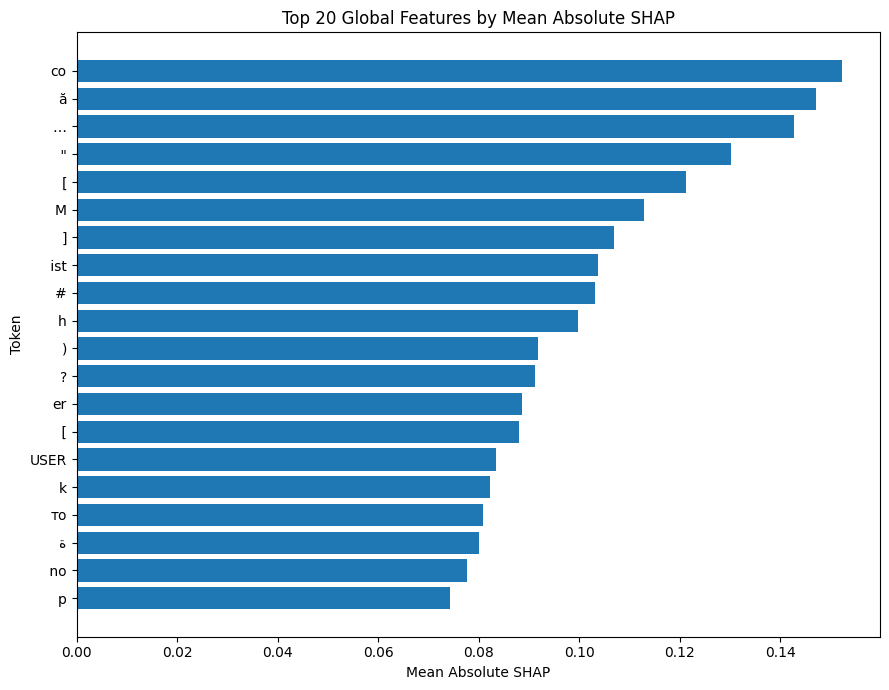

In [15]:
TOP_N_GLOBAL_FEATURES = 20

top_global_features_df = (
    global_absolute_summary_df
    .head(TOP_N_GLOBAL_FEATURES)
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_global_features_df["Token"],
    top_global_features_df["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP")
plt.ylabel("Token")
plt.title("Top 20 Global Features by Mean Absolute SHAP")

plt.tight_layout()
plt.show()

After retaining only tokens occurring at least five times in the global explainability subset, 167 recurrent features remained from the 3,594 unique tokens identified across 7,435 token occurrences. The resulting feature-importance ranking comprises both lexical tokens and non-lexical elements, including punctuation, brackets, hashtags and special markers (e.g., USER), indicating that the multilingual classifier relies on both linguistic content and stylistic cues when distinguishing Human-written and AI-generated texts.

Applying the minimum occurrence threshold reduced the influence of infrequently observed, sample-specific tokens, resulting in a more stable and interpretable global feature ranking. Nevertheless, because the explainability subset combines multiple languages with unequal language frequencies, globally important lexical tokens are interpreted as an overall summary of multilingual feature reliance rather than as universal indicators of Human-written or AI-generated text. Language-specific feature behaviour is therefore examined separately in the subsequent language-conditioned analyses.

### 18.6 Global Directional SHAP Analysis

To complement the global feature-importance analysis, signed SHAP values are examined to identify whether recurrent token-level features consistently shift predictions towards the Human-written or AI-generated classes. Positive SHAP values indicate that a token contributes towards the AI-generated prediction, whereas negative SHAP values indicate a contribution towards the Human-written prediction.

Mean signed SHAP values are computed by averaging the signed token-level SHAP values across all occurrences of each token. The same minimum occurrence threshold applied in the preceding global feature-importance analysis is retained to improve the stability of the aggregated directional attributions by reducing the influence of infrequently observed token-level contributions. Empty technical entries are excluded before aggregation.

As with the preceding global analysis, the multilingual composition of the explainability subset limits direct linguistic interpretation of individual lexical tokens. The purpose of this analysis is therefore to provide an exploratory overview of attribution direction before examining model behaviour under more controlled error-specific and language-conditioned settings.

In [17]:
global_directional_records = []

for sample_idx in range(len(global_shap_values)):

    sample_values = np.asarray(
        global_shap_values[sample_idx].values,
        dtype=float
    )

    sample_tokens = np.asarray(
        global_shap_values[sample_idx].data
    )

    # Signed attribution for the AI-generated output (class 1)
    ai_shap_values = sample_values[:, AI_LABEL]

    for token, shap_value in zip(
        sample_tokens,
        ai_shap_values
    ):
        global_directional_records.append({
            "Token": str(token),
            "AI_SHAP": float(shap_value)
        })


global_directional_df = pd.DataFrame(
    global_directional_records
)

# Remove empty technical entries
global_directional_df = (
    global_directional_df[
        global_directional_df["Token"] != ""
    ]
    .reset_index(drop=True)
)

print(
    "Directional token occurrences analysed:",
    len(global_directional_df)
)


Directional token occurrences analysed: 7435


In [18]:
# Aggregate signed and absolute SHAP values across token occurrences
global_directional_summary_all_df = (
    global_directional_df
    .groupby(
        "Token",
        as_index=False
    )
    .agg(
        Occurrences=(
            "AI_SHAP",
            "size"
        ),
        Mean_Signed_SHAP=(
            "AI_SHAP",
            "mean"
        ),
        Mean_Absolute_SHAP=(
            "AI_SHAP",
            lambda values: np.mean(np.abs(values))
        )
    )
)

print(
    "Unique tokens before occurrence filtering:",
    len(global_directional_summary_all_df)
)


Unique tokens before occurrence filtering: 3594


In [19]:
MIN_DIRECTIONAL_OCCURRENCES = 5

global_directional_summary_df = (
    global_directional_summary_all_df[
        global_directional_summary_all_df["Occurrences"]
        >= MIN_DIRECTIONAL_OCCURRENCES
    ]
    .reset_index(drop=True)
)

print(
    "Unique tokens retained after occurrence filtering:",
    len(global_directional_summary_df)
)





Unique tokens retained after occurrence filtering: 167


In [20]:
top_ai_direction_df = (
    global_directional_summary_df
    .sort_values(
        "Mean_Signed_SHAP",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

print("Strongest contributions towards AI:")
display(top_ai_direction_df)



Strongest contributions towards AI:


,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
0,ă,6,0.134616,0.147169
1,"""",5,0.128872,0.130148
2,[,20,0.112044,0.121268
3,ist,6,0.103430,0.103706
4,#,12,0.088846,0.103079
5,[,21,0.081872,0.088119
6,#,41,0.060585,0.069927
7,:,35,0.055897,0.058704
8,una,10,0.054117,0.054452
9,à,7,0.053518,0.053627


In [21]:
top_human_direction_df = (
    global_directional_summary_df
    .sort_values(
        "Mean_Signed_SHAP",
        ascending=True
    )
    .head(15)
    .reset_index(drop=True)
)

print("Strongest contributions towards Human:")
display(top_human_direction_df)

Strongest contributions towards Human:


,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
0,co,7,-0.152231,0.152231
1,…,6,-0.142035,0.142640
2,],34,-0.106315,0.107013
3,),5,-0.091814,0.091814
4,?,24,-0.091203,0.091203
5,er,8,-0.086982,0.088656
6,то,5,-0.080878,0.080878
7,USER,36,-0.080077,0.083516
8,ة,19,-0.078084,0.080062
9,no,7,-0.077760,0.077761


After retaining only tokens occurring at least five times in the global explainability subset, recurrent token-level contributions were identified in both attribution directions. Features contributing towards the AI-generated class comprised both lexical tokens and non-lexical elements, including punctuation, brackets, hashtags and other stylistic markers, whereas the strongest Human-oriented contributions likewise consisted of a mixture of lexical tokens together with recurrent stylistic features such as ellipses, brackets, question marks and the USER placeholder. These findings indicate that the multilingual classifier relies on both linguistic content and stylistic cues when shifting predictions towards either class.

Because the analysis aggregates token-level attributions across multiple languages with unequal language frequencies, the resulting directional rankings are interpreted as an exploratory summary of attribution direction rather than evidence that individual lexical tokens universally indicate Human-written or AI-generated text. More meaningful linguistic interpretation is therefore deferred to the subsequent error-specific and language-conditioned analyses, where token attributions are examined under more controlled conditions.

### 18.7 Error-Specific SHAP Analysis
To connect model interpretability with the benchmark error analysis, SHAP explanations are examined across different prediction outcomes. The objective is to investigate whether the features influencing correct predictions differ from those associated with false positives and false negatives.

Before constructing an error-specific explainability subset, the distribution of prediction outcomes within the existing global SHAP subset is first examined. This assessment determines whether the class-balanced global subset contains sufficient correctly and incorrectly classified samples for meaningful attribution comparisons or whether a dedicated error-specific sampling strategy is required.

In [ ]:
error_shap_distribution = (
    global_shap_df["error_type"]
    .value_counts()
    .rename_axis("Prediction outcome")
    .reset_index(name="Samples")
)

display(error_shap_distribution)

,Prediction outcome,Samples
0,Correct,179
1,False Positive,13
2,False Negative,8


In [ ]:
global_shap_df["shap_outcome"] = np.select(
    [
        (global_shap_df["true_label"] == 0) &
        (global_shap_df["predicted_label"] == 0),

        (global_shap_df["true_label"] == 1) &
        (global_shap_df["predicted_label"] == 1),

        (global_shap_df["true_label"] == 0) &
        (global_shap_df["predicted_label"] == 1),

        (global_shap_df["true_label"] == 1) &
        (global_shap_df["predicted_label"] == 0)
    ],
    [
        "Correct Human",
        "Correct AI",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

display(
    global_shap_df["shap_outcome"]
    .value_counts()
    .rename_axis("Prediction outcome")
    .reset_index(name="Samples")
)

,Prediction outcome,Samples
0,Correct AI,92
1,Correct Human,87
2,False Positive,13
3,False Negative,8


The existing global SHAP subset contained 92 Correct AI and 87 Correct Human predictions but only 13 False Positives and 8 False Negatives. This imbalance indicates that, although the global explainability subset is appropriate for characterising overall feature reliance, it does not contain sufficient misclassified samples to support stable comparisons of attribution patterns across different prediction outcomes. A dedicated error-specific explainability subset was therefore constructed for the subsequent analyses.

In [ ]:
error_language_counts = (
    test_results_df[
        test_results_df["error_type"].isin(
            ["False Positive", "False Negative"]
        )
    ]
    .groupby(
        ["language", "error_type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

error_language_counts["Total Errors"] = (
    error_language_counts.get("False Positive", 0)
    + error_language_counts.get("False Negative", 0)
)

error_language_counts = (
    error_language_counts
    .sort_values(
        "Total Errors",
        ascending=False
    )
    .reset_index(drop=True)
)

display(error_language_counts)

error_type,language,False Negative,False Positive,Total Errors
0,pt,810,132,942
1,ru,839,85,924
2,nl,820,103,923
3,en,728,101,829
4,de,712,95,807
5,es,633,134,767
6,ar,529,116,645
7,ca,553,50,603
8,pl,526,70,596
9,ro,428,156,584


False positives and false negatives were observed across all benchmark languages, although their frequencies varied considerably. For example, Portuguese contained 942 misclassified samples, whereas Scottish Gaelic contained only 28. Such differences in language-specific error frequencies could influence the resulting SHAP explanations if left uncontrolled. A language-controlled sampling strategy was therefore adopted to reduce language composition as a potential confounding factor in the subsequent attribution comparisons.

In [ ]:
error_shap_source_df = test_results_df.copy()

error_shap_source_df["shap_outcome"] = np.select(
    [
        (error_shap_source_df["true_label"] == 0) &
        (error_shap_source_df["predicted_label"] == 0),

        (error_shap_source_df["true_label"] == 1) &
        (error_shap_source_df["predicted_label"] == 1),

        (error_shap_source_df["true_label"] == 0) &
        (error_shap_source_df["predicted_label"] == 1),

        (error_shap_source_df["true_label"] == 1) &
        (error_shap_source_df["predicted_label"] == 0)
    ],
    [
        "Correct Human",
        "Correct AI",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

display(
    error_shap_source_df["shap_outcome"]
    .value_counts()
)

,count
shap_outcome,
Correct AI,114920
Correct Human,15702
False Negative,8569
False Positive,1697


In [ ]:
fp_language_counts = (
    error_shap_source_df[
        error_shap_source_df["shap_outcome"]
        == "False Positive"
    ]["language"]
    .value_counts()
)

fn_language_counts = (
    error_shap_source_df[
        error_shap_source_df["shap_outcome"]
        == "False Negative"
    ]["language"]
    .value_counts()
)

common_language_weights = (
    fp_language_counts / fp_language_counts.sum()
    +
    fn_language_counts / fn_language_counts.sum()
) / 2

common_language_weights = (
    common_language_weights
    / common_language_weights.sum()
)

display(
    common_language_weights
    .rename("Sampling weight")
    .reset_index()
    .rename(columns={"index": "Language"})
)

,language,Sampling weight
0,ar,0.065045
1,bg,0.020623
2,ca,0.046999
3,cs,0.031866
4,de,0.069536
5,el,0.028024
6,en,0.072237
7,es,0.076417
8,et,0.024587
9,ga,0.047158


Sampling weights were derived by averaging the normalised language distributions of the False Positive and False Negative groups. This approach reflects the multilingual composition of both error types rather than allowing either group to determine the sampling distribution independently. The resulting common language weights are subsequently applied to all four prediction-outcome groups, ensuring an identical language allocation and reducing language composition as a potential confounding factor in attribution comparisons.

In [ ]:
TARGET_PER_OUTCOME = 50

# Initial allocation
language_allocation = (
    common_language_weights * TARGET_PER_OUTCOME
).apply(np.floor).astype(int)

# Distribute the remaining samples according to
# the largest fractional remainders
remaining = (
    TARGET_PER_OUTCOME
    - language_allocation.sum()
)

fractional_remainders = (
    common_language_weights * TARGET_PER_OUTCOME
    - language_allocation
)

for language in (
    fractional_remainders
    .sort_values(ascending=False)
    .head(remaining)
    .index
):
    language_allocation.loc[language] += 1

language_allocation_df = (
    language_allocation
    .rename("Samples per outcome")
    .reset_index()
)

display(language_allocation_df)

print(
    "Samples per outcome:",
    language_allocation.sum()
)

,language,Samples per outcome
0,ar,3
1,bg,1
2,ca,2
3,cs,2
4,de,3
5,el,1
6,en,4
7,es,4
8,et,1
9,ga,2


Samples per outcome: 50


In [ ]:
RANDOM_STATE = 42

outcomes = [
    "Correct Human",
    "Correct AI",
    "False Positive",
    "False Negative"
]

sampled_groups = []

for outcome in outcomes:

    outcome_df = error_shap_source_df[
        error_shap_source_df["shap_outcome"] == outcome
    ]

    for language, n_samples in language_allocation.items():

        if n_samples == 0:
            continue

        language_group = outcome_df[
            outcome_df["language"] == language
        ]

        sampled = language_group.sample(
            n=n_samples,
            random_state=RANDOM_STATE
        )

        sampled_groups.append(sampled)

error_shap_df = (
    pd.concat(sampled_groups)
    .reset_index(drop=True)
)

print(
    "Error-specific SHAP sample size:",
    len(error_shap_df)
)

display(
    error_shap_df["shap_outcome"]
    .value_counts()
    .rename_axis("Prediction outcome")
    .reset_index(name="Samples")
)

Error-specific SHAP sample size: 200


,Prediction outcome,Samples
0,Correct Human,50
1,Correct AI,50
2,False Positive,50
3,False Negative,50


In [ ]:
error_language_check = pd.crosstab(
    error_shap_df["language"],
    error_shap_df["shap_outcome"]
)

display(error_language_check)

shap_outcome,Correct AI,Correct Human,False Negative,False Positive
language,,,,
ar,3,3,3,3
bg,1,1,1,1
ca,2,2,2,2
cs,2,2,2,2
de,3,3,3,3
el,1,1,1,1
en,4,4,4,4
es,4,4,4,4
et,1,1,1,1


The resulting error-specific explainability subset contains 200 samples, comprising 50 examples from each prediction outcome. The same language allocation is applied across all four groups, with each included language represented by an identical number of samples within Correct Human, Correct AI, False Positive and False Negative outcomes. Scottish Gaelic is not represented because its calculated allocation was zero at the selected sample size. This controlled sampling design reduces language composition as a potential confounding factor, allowing subsequent differences in SHAP attributions to be interpreted more directly in relation to prediction outcome rather than differences in multilingual language distribution.

In [ ]:
error_shap_texts = (
    error_shap_df["text"]
    .astype(str)
    .tolist()
)

error_shap_values = shap_explainer(
    error_shap_texts
)

print(
    "Error-specific SHAP explanations generated:",
    len(error_shap_values)
)

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

Error-specific SHAP explanations generated: 200


SHAP explanations were successfully generated for all 200 texts in the language-controlled error-specific explainability subset without computational errors. These explanations provide the basis for comparing token-level attribution patterns across Correct Human, Correct AI, False Positive and False Negative prediction outcomes while holding the multilingual language distribution constant.

### 18.8 Attribution Magnitude Across Prediction Outcomes

The overall strength of token-level attributions is compared across the four prediction outcomes using the language-controlled error-specific explainability subset. Comparisons are performed within the same true class: Correct Human predictions are compared with False Positives, while Correct AI predictions are compared with False Negatives.

This design examines whether prediction errors are associated with differences in attribution magnitude while holding both language composition and the underlying true class constant. For each sample, the mean absolute SHAP value summarises the average attribution strength across all tokens, whereas the maximum absolute SHAP value captures the strength of the single most influential token within that sample.

In [ ]:
error_attribution_records = []

for sample_idx in range(len(error_shap_values)):

    sample_values = np.asarray(
        error_shap_values[sample_idx].values,
        dtype=float
    )

    # AI-output SHAP values
    ai_shap_values = sample_values[:, AI_LABEL]

    error_attribution_records.append({
        "Prediction outcome":
            error_shap_df.iloc[sample_idx]["shap_outcome"],

        "Mean_Absolute_SHAP":
            np.mean(np.abs(ai_shap_values)),

        "Max_Absolute_SHAP":
            np.max(np.abs(ai_shap_values))
    })


error_attribution_df = pd.DataFrame(
    error_attribution_records
)


error_attribution_summary_df = (
    error_attribution_df
    .groupby(
        "Prediction outcome",
        as_index=False
    )
    .agg(
        Samples=(
            "Mean_Absolute_SHAP",
            "size"
        ),
        Mean_Attribution=(
            "Mean_Absolute_SHAP",
            "mean"
        ),
        Median_Attribution=(
            "Mean_Absolute_SHAP",
            "median"
        ),
        Mean_Max_Attribution=(
            "Max_Absolute_SHAP",
            "mean"
        )
    )
)


outcome_order = [
    "Correct Human",
    "False Positive",
    "Correct AI",
    "False Negative"
]

error_attribution_summary_df[
    "Prediction outcome"
] = pd.Categorical(
    error_attribution_summary_df[
        "Prediction outcome"
    ],
    categories=outcome_order,
    ordered=True
)

error_attribution_summary_df = (
    error_attribution_summary_df
    .sort_values("Prediction outcome")
    .reset_index(drop=True)
)

display(error_attribution_summary_df)

,Prediction outcome,Samples,Mean_Attribution,Median_Attribution,Mean_Max_Attribution
0,Correct Human,50,0.053514,0.051353,0.241061
1,False Positive,50,0.100729,0.101407,0.394887
2,Correct AI,50,0.061919,0.040661,0.232193
3,False Negative,50,0.066029,0.058013,0.271735


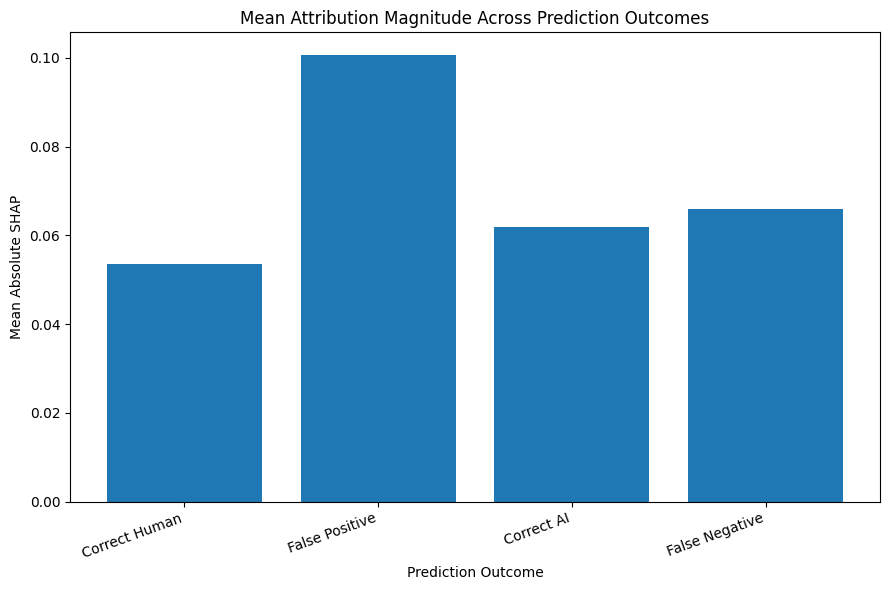

In [ ]:
plt.figure(figsize=(9, 6))

plt.bar(
    error_attribution_summary_df[
        "Prediction outcome"
    ].astype(str),
    error_attribution_summary_df[
        "Mean_Attribution"
    ]
)

plt.xlabel("Prediction Outcome")
plt.ylabel("Mean Absolute SHAP")
plt.title(
    "Mean Attribution Magnitude Across Prediction Outcomes"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

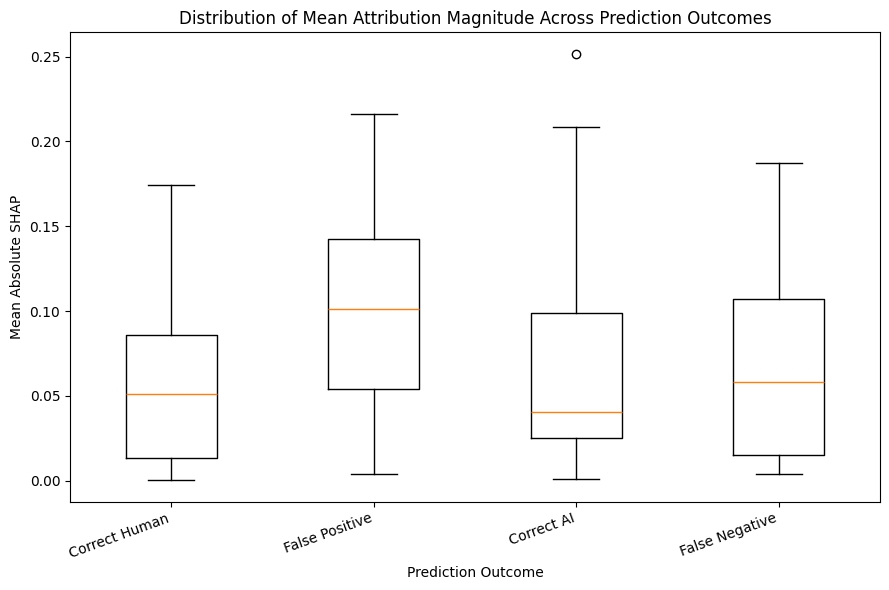

In [ ]:
# Distribution of Mean Attribution Magnitude
plot_data = [
    error_attribution_df.loc[
        error_attribution_df["Prediction outcome"] == outcome,
        "Mean_Absolute_SHAP"
    ].values
    for outcome in outcome_order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    plot_data,
    tick_labels=outcome_order,
    showfliers=True
)

plt.xlabel("Prediction Outcome")
plt.ylabel("Mean Absolute SHAP")
plt.title(
    "Distribution of Mean Attribution Magnitude Across Prediction Outcomes"
)

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

Within the Human-written class, False Positives exhibited substantially higher attribution magnitudes than Correct Human predictions. The mean absolute SHAP value increased from 0.0535 for Correct Human samples to 0.1007 for False Positives, indicating that these misclassifications were associated with considerably stronger token-level attributions.

Within the AI-generated class, False Negatives also showed slightly higher attribution magnitudes than Correct AI predictions (0.0660 versus 0.0619). However, the difference was much smaller than that observed for the Human-written class, and the attribution distributions exhibited substantial overlap.

A similar pattern was observed for the maximum token-level attribution. False Positives produced the highest mean maximum attribution (0.3949), whereas False Negatives showed only a modest increase relative to Correct AI predictions (0.2717 versus 0.2322). These findings suggest that some prediction errors—particularly False Positives—are associated with strong reliance on a limited number of influential token-level features rather than uniformly weak feature attributions.

Attribution magnitude alone, however, does not identify which specific features are responsible for these prediction errors. The following analysis therefore examines the directional token-level attributions associated with each prediction outcome.

### 18.9 Directional Token Contributions Across Prediction Outcomes

To investigate which token-level features are associated with model errors, signed SHAP contributions are compared within each true class. Correct Human predictions are compared with False Positives, while Correct AI predictions are compared with False Negatives.

Because the language composition is identical across the four prediction-outcome groups, this comparison reduces the influence of differences in language distribution. Nevertheless, individual lexical tokens remain language-specific and are therefore interpreted cautiously. The primary objective is to identify attribution patterns associated with successful and unsuccessful classification rather than universal linguistic markers.

Most token representations occurred only once within each prediction-outcome group, reflecting the substantial lexical diversity of the multilingual explainability subset despite the language-controlled sampling strategy. Consistent with the global token-level analyses, only tokens occurring at least five times within the corresponding prediction-outcome group are retained for the subsequent comparisons. The observed occurrence distribution within the error-specific subset further supports this choice by indicating that most token-level attributions are based on isolated observations.

In [ ]:
error_directional_records = []

for sample_idx in range(len(error_shap_values)):

    sample_values = np.asarray(
        error_shap_values[sample_idx].values,
        dtype=float
    )

    sample_tokens = np.asarray(
        error_shap_values[sample_idx].data
    )

    outcome = error_shap_df.iloc[
        sample_idx
    ]["shap_outcome"]

    ai_shap_values = sample_values[:, AI_LABEL]

    for token, shap_value in zip(
        sample_tokens,
        ai_shap_values
    ):

        token = str(token)

        # Remove only empty technical entries
        if token == "":
            continue

        error_directional_records.append({
            "Prediction outcome": outcome,
            "Token": token,
            "AI_SHAP": float(shap_value)
        })


error_directional_df = pd.DataFrame(
    error_directional_records
)

print(
    "Error-analysis token occurrences:",
    len(error_directional_df)
)

Error-analysis token occurrences: 9841


In [ ]:
token_occurrence_summary = (
    error_directional_df
    .groupby(
        ["Prediction outcome", "Token"]
    )
    .size()
    .reset_index(name="Occurrences")
)

occurrence_check = (
    token_occurrence_summary
    .groupby("Prediction outcome")["Occurrences"]
    .describe()
)

display(occurrence_check)

,count,mean,std,min,25%,50%,75%,max
Prediction outcome,,,,,,,,
Correct AI,1482.0,1.805668,7.482685,1.0,1.0,1.0,1.0,261.0
Correct Human,990.0,1.594949,4.380831,1.0,1.0,1.0,1.0,114.0
False Negative,1991.0,1.947263,7.895787,1.0,1.0,1.0,1.0,307.0
False Positive,951.0,1.797056,6.199307,1.0,1.0,1.0,1.0,171.0


Most token representations occurred only once within each prediction-outcome group, with a median occurrence of one token across all four groups. This reflects the substantial lexical diversity of the multilingual explainability subset despite the language-controlled sampling strategy and indicates that many token-level SHAP attributions are highly sample-specific.

To improve the stability of the aggregated directional comparisons, subsequent analyses retain only tokens occurring at least five times within the corresponding prediction-outcome group. The observed occurrence distribution supports this choice by showing that most token-level attributions are based on isolated observations. Applying the occurrence threshold therefore reduces the influence of infrequently observed token-level attributions while focusing the comparisons on recurrent attribution patterns that are more suitable for comparison across prediction outcomes.

### 18.10 Correct vs Error Token Attribution Differences

To examine how token-level attributions change when classification fails, mean signed SHAP values are compared between correct and incorrect predictions within the same true class. Human-written texts are compared between Correct Human and False Positive outcomes, while AI-generated texts are compared between Correct AI and False Negative outcomes.

Only tokens occurring at least five times within each prediction-outcome group are retained before identifying tokens shared by both groups in the corresponding comparison. The resulting SHAP difference therefore reflects changes in the average attribution assigned to the same recurrent token under correct and incorrect prediction conditions, rather than indicating that the token itself is universally associated with either class.

Whitespace entries arising from the tokenisation and SHAP text-masking representation are retained unchanged during the analysis but displayed as `<whitespace>` in the resulting tables for readability.

In [ ]:
MIN_ERROR_TOKEN_OCCURRENCES = 5

error_token_summary_df = (
    error_directional_df
    .groupby(
        ["Prediction outcome", "Token"]
    )
    .agg(
        Occurrences=(
            "AI_SHAP",
            "size"
        ),
        Mean_Signed_SHAP=(
            "AI_SHAP",
            "mean"
        ),
        Mean_Absolute_SHAP=(
            "AI_SHAP",
            lambda x: np.mean(np.abs(x))
        )
    )
    .reset_index()
)

error_token_summary_df = (
    error_token_summary_df[
        error_token_summary_df["Occurrences"]
        >= MIN_ERROR_TOKEN_OCCURRENCES
    ]
    .reset_index(drop=True)
)

retained_token_counts_df = (
    error_token_summary_df
    .groupby("Prediction outcome")
    .size()
    .rename("Retained tokens")
    .reset_index()
)

display(retained_token_counts_df)

,Prediction outcome,Retained tokens
0,Correct AI,54
1,Correct Human,30
2,False Negative,88
3,False Positive,36


In [ ]:
correct_human_tokens = (
    error_token_summary_df[
        error_token_summary_df["Prediction outcome"]
        == "Correct Human"
    ][
        [
            "Token",
            "Occurrences",
            "Mean_Signed_SHAP"
        ]
    ]
    .rename(columns={
        "Occurrences":
            "Correct_Human_Occurrences",
        "Mean_Signed_SHAP":
            "Correct_Human_SHAP"
    })
)

false_positive_tokens = (
    error_token_summary_df[
        error_token_summary_df["Prediction outcome"]
        == "False Positive"
    ][
        [
            "Token",
            "Occurrences",
            "Mean_Signed_SHAP"
        ]
    ]
    .rename(columns={
        "Occurrences":
            "FP_Occurrences",
        "Mean_Signed_SHAP":
            "FP_SHAP"
    })
)

human_error_comparison_df = (
    correct_human_tokens
    .merge(
        false_positive_tokens,
        on="Token",
        how="inner"
    )
)

human_error_comparison_df[
    "SHAP_Difference_FP_minus_Correct"
] = (
    human_error_comparison_df["FP_SHAP"]
    - human_error_comparison_df[
        "Correct_Human_SHAP"
    ]
)

human_error_comparison_df = (
    human_error_comparison_df
    .sort_values(
        "SHAP_Difference_FP_minus_Correct",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Tokens available for Human correct-vs-FP comparison:",
    len(human_error_comparison_df)
)

Tokens available for Human correct-vs-FP comparison: 16


In [ ]:
correct_ai_tokens = (
    error_token_summary_df[
        error_token_summary_df["Prediction outcome"]
        == "Correct AI"
    ][
        [
            "Token",
            "Occurrences",
            "Mean_Signed_SHAP"
        ]
    ]
    .rename(columns={
        "Occurrences":
            "Correct_AI_Occurrences",
        "Mean_Signed_SHAP":
            "Correct_AI_SHAP"
    })
)

false_negative_tokens = (
    error_token_summary_df[
        error_token_summary_df["Prediction outcome"]
        == "False Negative"
    ][
        [
            "Token",
            "Occurrences",
            "Mean_Signed_SHAP"
        ]
    ]
    .rename(columns={
        "Occurrences":
            "FN_Occurrences",
        "Mean_Signed_SHAP":
            "FN_SHAP"
    })
)

ai_error_comparison_df = (
    correct_ai_tokens
    .merge(
        false_negative_tokens,
        on="Token",
        how="inner"
    )
)

ai_error_comparison_df[
    "SHAP_Difference_FN_minus_Correct"
] = (
    ai_error_comparison_df["FN_SHAP"]
    - ai_error_comparison_df[
        "Correct_AI_SHAP"
    ]
)

ai_error_comparison_df = (
    ai_error_comparison_df
    .sort_values(
        "SHAP_Difference_FN_minus_Correct",
        ascending=True
    )
    .reset_index(drop=True)
)

print(
    "Tokens available for AI correct-vs-FN comparison:",
    len(ai_error_comparison_df)
)

Tokens available for AI correct-vs-FN comparison: 30


In [ ]:
def make_token_display_friendly(df):
    display_df = df.copy()

    display_df["Token"] = (
        display_df["Token"]
        .apply(
            lambda token:
                "<whitespace>"
                if str(token).isspace()
                else token
        )
    )

    return display_df

In [ ]:
print(
    "Largest attribution shifts:"
    " Correct Human → False Positive"
)

display(
    make_token_display_friendly(
        human_error_comparison_df
    ).head(15)
)

Largest attribution shifts: Correct Human → False Positive


,Token,Correct_Human_Occurrences,Correct_Human_SHAP,FP_Occurrences,FP_SHAP,SHAP_Difference_FP_minus_Correct
0,],13,-0.233029,23,-0.115631,0.117397
1,in,6,-0.053914,6,0.003338,0.057252
2,",",29,-0.023744,41,0.016889,0.040633
3,.,53,-0.054358,51,-0.018263,0.036095
4,s,21,-0.044528,24,-0.008736,0.035792
5,e,5,-0.015916,10,0.012463,0.028379
6,USER,14,-0.125906,23,-0.104205,0.021700
7,-,32,0.001387,14,0.015874,0.014487
8,i,8,0.007633,9,0.020191,0.012558
9,a,18,-0.008941,19,0.001490,0.010431


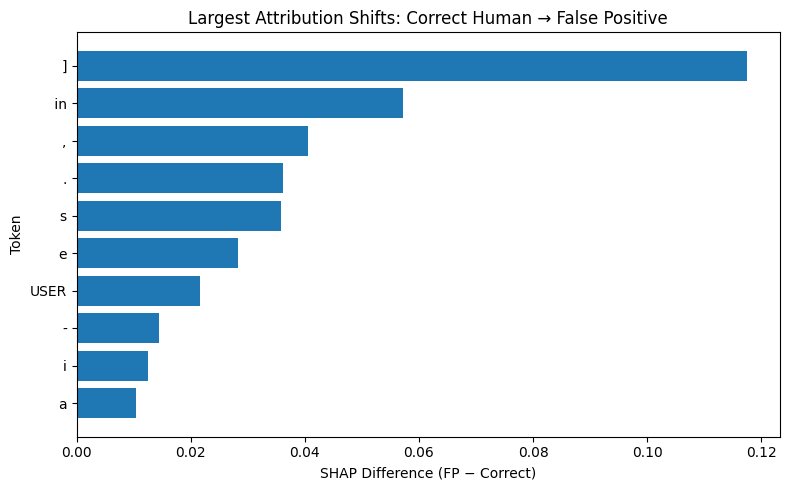

In [ ]:
# Human: Largest Attribution Shifts

plot_df = (
    human_error_comparison_df
    .head(10)
    .copy()
)

plot_df["Token"] = plot_df["Token"].apply(
    lambda x: "<whitespace>"
    if str(x).isspace()
    else x
)

plt.figure(figsize=(8,5))

plt.barh(
    plot_df["Token"],
    plot_df["SHAP_Difference_FP_minus_Correct"]
)

plt.xlabel("SHAP Difference (FP − Correct)")
plt.ylabel("Token")
plt.title(
    "Largest Attribution Shifts: Correct Human → False Positive"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
print(
    "Largest attribution shifts:"
    " Correct AI → False Negative"
)

display(
    make_token_display_friendly(
        ai_error_comparison_df
    ).head(15)
)

Largest attribution shifts: Correct AI → False Negative


,Token,Correct_AI_Occurrences,Correct_AI_SHAP,FN_Occurrences,FN_SHAP,SHAP_Difference_FN_minus_Correct
0,/,12,0.049988,20,-0.022508,-0.072496
1,l,7,0.002211,6,-0.051727,-0.053938
2,d,5,-0.027177,6,-0.070153,-0.042977
3,',7,0.046050,11,0.003281,-0.042769
4,i,8,0.010069,18,-0.024897,-0.034966
5,en,12,0.010478,15,-0.016917,-0.027395
6,**,15,-0.000084,9,-0.017961,-0.017878
7,de,23,0.020074,27,0.007293,-0.012782
8,een,5,0.015347,5,0.004568,-0.010779
9,a,32,-0.006148,39,-0.013514,-0.007367


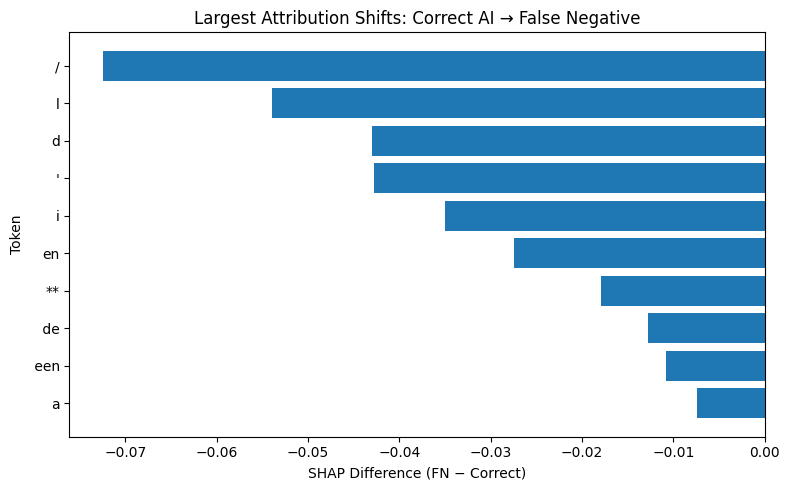

In [ ]:
# AI: Largest Attribution Shifts

plot_df = (
    ai_error_comparison_df
    .head(10)
    .copy()
)

plot_df["Token"] = plot_df["Token"].apply(
    lambda x: "<whitespace>"
    if str(x).isspace()
    else x
)

plt.figure(figsize=(8,5))

plt.barh(
    plot_df["Token"],
    plot_df["SHAP_Difference_FN_minus_Correct"]
)

plt.xlabel("SHAP Difference (FN − Correct)")
plt.ylabel("Token")
plt.title(
    "Largest Attribution Shifts: Correct AI → False Negative"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The controlled token-level comparison revealed measurable attribution shifts between correct and incorrect predictions within the same true class.

For Human-written texts, several shared recurrent features received stronger AI-oriented attribution in False Positive cases than in Correct Human predictions. The largest shift was observed for the closing bracket token (]), whose mean signed SHAP value increased from −0.233 to −0.116 (Δ = 0.117). Other shared features, including in, ',', '.', s, e, and USER, also shifted towards more AI-oriented attributions. In contrast, features such as '[' and de exhibited stronger Human-oriented attribution in False Positive cases, indicating that misclassification does not arise from a uniform directional shift across all shared features.

For AI-generated texts, several shared recurrent features exhibited reduced AI-oriented attribution in False Negative cases. The largest decrease was observed for the forward slash token (/), whose mean signed SHAP value changed from 0.050 to −0.023 (Δ = −0.072). Additional features, including l, d, ', i, en, and de, likewise showed reduced AI-oriented attribution, with several shifting towards Human-oriented contributions. Whitespace representations exhibited only minor attribution differences and are not interpreted as standalone linguistic features.

Only 16 recurrent tokens satisfied the occurrence criterion in both Human comparison groups, while 30 satisfied the criterion in both AI comparison groups. Consequently, these comparisons provide exploratory evidence that classification errors may be associated with changes in how recurrent shared token-level evidence is weighted, rather than solely reflecting the presence of entirely different lexical features. Given the limited number of shared recurrent tokens, the observed attribution shifts should be interpreted as indicative attribution patterns rather than universal linguistic markers of misclassification.

## 18.11 Language-Conditioned SHAP Analysis

The preceding global and error-specific SHAP analyses combine samples from multiple languages. Although this provides an overall view of model behaviour, the multilingual setting limits the linguistic interpretation of individual lexical and subword features because the aggregated attribution patterns may reflect features originating from different languages.

To provide a more interpretable assessment of feature reliance, SHAP explanations are therefore examined separately within five selected languages. Rather than selecting languages solely according to dataset frequency, the selection combines literature relevance, observed model performance, and the benchmark's seen and unseen language conditions to represent contrasting multilingual settings.

English (en) is included as a reference language because AI-generated text detection research has predominantly focused on English and an English-only experiment was also conducted separately in this study. Hungarian (hu) represents a high-performing seen language, while Russian (ru) represents a comparatively challenging seen language, particularly with respect to AI-to-Human errors. Slovak (sk) represents a relatively high-performing unseen language, whereas Slovenian (sl) represents a more challenging unseen language characterised by an elevated Human-to-AI false positive rate.

This targeted selection enables within-language interpretation while also supporting comparisons across a reference language, contrasting performance profiles, and seen versus unseen language conditions. Rather than characterising all 22 benchmark languages, the objective is to investigate whether the model's feature-attribution patterns remain consistent or vary across representative multilingual conditions.

### 18.11.1 Construct Language-Conditioned Samples

A class-balanced subset is constructed for the five selected languages. For each language, 50 Human-written and 50 AI-generated benchmark samples are randomly selected using a fixed random seed, resulting in 500 samples in total. Equal class representation ensures that subsequent within-language SHAP comparisons are not influenced by class imbalance.

In [ ]:

LANGUAGE_SHAP_SELECTION = {
    "en": "Seen – reference language",
    "hu": "Seen – high performance",
    "ru": "Seen – challenging",
    "sk": "Unseen – relatively robust",
    "sl": "Unseen – high FPR"
}

LANGUAGE_SHAP_PER_CLASS = 50
LANGUAGE_SHAP_RANDOM_STATE = 42

language_shap_samples = []

for language, condition in LANGUAGE_SHAP_SELECTION.items():

    language_df = test_results_df[
        test_results_df["language"] == language
    ]

    human_pool = language_df[
        language_df["true_label"] == HUMAN_LABEL
    ]

    ai_pool = language_df[
        language_df["true_label"] == AI_LABEL
    ]

    human_sample = human_pool.sample(
        n=LANGUAGE_SHAP_PER_CLASS,
        random_state=LANGUAGE_SHAP_RANDOM_STATE
    ).copy()

    ai_sample = ai_pool.sample(
        n=LANGUAGE_SHAP_PER_CLASS,
        random_state=LANGUAGE_SHAP_RANDOM_STATE
    ).copy()

    human_sample["SHAP language condition"] = condition
    ai_sample["SHAP language condition"] = condition

    language_shap_samples.extend([
        human_sample,
        ai_sample
    ])

language_shap_df = (
    pd.concat(
        language_shap_samples,
        ignore_index=True
    )
    .reset_index(drop=True)
)

print(
    "Language-conditioned SHAP sample size:",
    len(language_shap_df)
)

Language-conditioned SHAP sample size: 500


The resulting language-conditioned explainability subset contains 500 benchmark test samples, comprising 100 samples for each selected language and an equal number of Human-written and AI-generated texts. This balanced sampling design ensures identical sample sizes and class distributions across all five language conditions, enabling fair within-language SHAP analyses while facilitating more comparable cross-language interpretation of feature-attribution patterns.

### 18.11.2 Verify the Sampling Design

The resulting subset is checked to confirm equal representation of Human-written and AI-generated samples within each selected language and to verify the language-condition labels used in the subsequent analysis.

In [ ]:

language_class_check = pd.crosstab(
    language_shap_df["language"],
    language_shap_df["true_label"]
)

language_class_check = (
    language_class_check
    .rename(
        columns={
            HUMAN_LABEL: "Human",
            AI_LABEL: "AI"
        }
    )
)

display(language_class_check)

true_label,Human,AI
language,,
en,50,50
hu,50,50
ru,50,50
sk,50,50
sl,50,50


The verification confirms that each selected language contributes exactly 50 Human-written and 50 AI-generated samples, resulting in identical class distributions across all language-specific explainability subsets. This balanced sampling design removes class imbalance as a potential source of variation, allowing subsequent within-language SHAP comparisons to focus on language-specific attribution patterns.

In [ ]:
language_condition_check = (
    language_shap_df[
        [
            "language",
            "SHAP language condition"
        ]
    ]
    .drop_duplicates()
    .sort_values("language")
    .reset_index(drop=True)
)

display(language_condition_check)

,language,SHAP language condition
0,en,Seen – reference language
1,hu,Seen – high performance
2,ru,Seen – challenging
3,sk,Unseen – relatively robust
4,sl,Unseen – high FPR


The verification confirms that the selected languages have been assigned to the intended experimental conditions. English serves as the reference language, Hungarian and Russian represent contrasting performance profiles within the seen-language condition, while Slovak and Slovenian represent contrasting performance profiles within the unseen-language condition. These language-condition labels provide the basis for subsequent within-language SHAP analyses and cross-language comparisons under representative multilingual settings.

### 18.11.3 Compute Language-Conditioned SHAP Explanations

SHAP explanations are generated for the 500-sample class-balanced language-conditioned explainability subset using the same text explainer and AI-output attribution framework employed in the preceding analyses. Applying an identical explainability configuration ensures methodological consistency across languages, allowing observed attribution differences to be examined without variation in the SHAP procedure itself.

The resulting token-level explanations are subsequently analysed separately within each language rather than aggregated across the multilingual sample.

In [ ]:
language_shap_texts = (
    language_shap_df["text"]
    .astype(str)
    .tolist()
)

language_shap_values = shap_explainer(
    language_shap_texts
)

print(
    "Language-conditioned SHAP explanations generated:",
    len(language_shap_values)
)

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

Language-conditioned SHAP explanations generated: 500


SHAP explanations were successfully generated for all 500 samples in the language-conditioned explainability subset without computational errors. These explanations provide the basis for the subsequent within-language analyses, enabling feature-attribution patterns to be examined separately for each selected language under an identical explainability configuration.

### 18.11.4 Within-Language Directional SHAP Analysis

To improve the interpretability of lexical and subword features, token-level signed SHAP values are analysed separately within each selected language. Positive signed SHAP values indicate contributions towards the AI-generated output, whereas negative values indicate contributions towards the Human-written output.

Token occurrences are aggregated independently for each language. This within-language approach avoids directly combining lexical features from different languages, enabling feature-attribution patterns to be interpreted within individual language contexts while supporting comparisons across the selected language conditions.

In [ ]:
language_directional_records = []

for sample_idx in range(len(language_shap_values)):

    sample_values = np.asarray(
        language_shap_values[sample_idx].values,
        dtype=float
    )

    sample_tokens = np.asarray(
        language_shap_values[sample_idx].data
    )

    language = (
        language_shap_df
        .iloc[sample_idx]["language"]
    )

    true_label = (
        language_shap_df
        .iloc[sample_idx]["true_label"]
    )

    ai_shap_values = (
        sample_values[:, AI_LABEL]
    )

    for token, shap_value in zip(
        sample_tokens,
        ai_shap_values
    ):

        token = str(token)

        # Remove only empty technical entries
        if token == "":
            continue

        language_directional_records.append({
            "Language": language,
            "True label": true_label,
            "Token": token,
            "AI_SHAP": float(shap_value)
        })


language_directional_df = pd.DataFrame(
    language_directional_records
)

print(
    "Language-conditioned token occurrences analysed:",
    len(language_directional_df)
)

Language-conditioned token occurrences analysed: 22760


In [ ]:
language_token_occurrence_df = (
    language_directional_df
    .groupby(
        ["Language", "Token"]
    )
    .size()
    .reset_index(name="Occurrences")
)

language_occurrence_summary_df = (
    language_token_occurrence_df
    .groupby("Language")["Occurrences"]
    .describe()
)

display(language_occurrence_summary_df)

,count,mean,std,min,25%,50%,75%,max
Language,,,,,,,,
en,1861.0,2.415905,11.034552,1.0,1.0,1.0,2.0,393.0
hu,1186.0,2.222597,8.702841,1.0,1.0,1.0,2.0,248.0
ru,1887.0,2.641759,13.420791,1.0,1.0,1.0,2.0,513.0
sk,1675.0,2.823284,12.059086,1.0,1.0,1.0,2.0,413.0
sl,2044.0,2.893346,12.385881,1.0,1.0,1.0,2.0,363.0


Most token representations occurred only once or twice within each selected language, with a median occurrence of one token across all five language-conditioned explainability subsets. This indicates that substantial lexical diversity remains even after conditioning the analysis by language, and that many token-level SHAP attributions continue to be highly sample-specific.

To improve the robustness of the within-language directional analyses, subsequent comparisons retain only tokens occurring at least five times within the corresponding language. Consistent with the preceding error-specific analyses, this occurrence threshold focuses the interpretation on repeatedly observed attribution patterns while reducing the influence of isolated token-level explanations.

Applying the same occurrence threshold across all selected languages ensures methodological consistency, enabling observed differences in attribution patterns to be interpreted more confidently as language-specific model behaviour rather than differences introduced by feature filtering.

### 18.11.5 Within-Language Directional Feature Summary

For each selected language, token-level SHAP values are aggregated independently. Tokens occurring at least five times within the corresponding language are retained, and their mean signed SHAP values are used to identify features contributing most strongly towards the AI-generated and Human-written outputs.

Because the analysis is performed separately within each language, lexical and subword features can be interpreted within a more appropriate linguistic context. Nevertheless, the resulting rankings remain exploratory and reflect attribution patterns within the sampled benchmark texts rather than universal linguistic markers of Human-written or AI-generated text, even within the corresponding language.

In [ ]:
MIN_LANGUAGE_TOKEN_OCCURRENCES = 5

language_token_summary_df = (
    language_directional_df
    .groupby(
        ["Language", "Token"]
    )
    .agg(
        Occurrences=("AI_SHAP", "size"),
        Mean_Signed_SHAP=("AI_SHAP", "mean"),
        Mean_Absolute_SHAP=(
            "AI_SHAP",
            lambda x: np.mean(np.abs(x))
        )
    )
    .reset_index()
)

language_token_summary_df = (
    language_token_summary_df[
        language_token_summary_df["Occurrences"]
        >= MIN_LANGUAGE_TOKEN_OCCURRENCES
    ]
    .reset_index(drop=True)
)

retained_language_tokens_df = (
    language_token_summary_df
    .groupby("Language")
    .size()
    .rename("Retained tokens")
    .reset_index()
)

display(retained_language_tokens_df)

,Language,Retained tokens
0,en,104
1,hu,67
2,ru,149
3,sk,151
4,sl,180


The occurrence filtering retained different numbers of recurrent token-level features across the five selected languages, ranging from 67 features for Hungarian to 180 for Slovenian. These differences reflect variation in lexical diversity and token repetition within the sampled benchmark texts rather than differences in the filtering procedure, which was applied identically across all languages.

Applying the same occurrence threshold ensures that subsequent within-language directional comparisons are based on repeatedly observed features while maintaining methodological consistency across languages. Consequently, differences in the resulting directional SHAP rankings can be interpreted more confidently as differences in language-specific attribution patterns rather than artefacts introduced by inconsistent feature filtering.

### 18.11.6 Compare Directional Features Within Languages

The strongest directional features are examined separately for each selected language. Tokens with the highest positive mean signed SHAP values represent features that, on average, contributed most strongly towards the AI-generated output, whereas the most negative values represent features contributing towards the Human-written output.

The comparison focuses on within-language attribution patterns rather than directly comparing the semantic meaning of lexical or subword features across languages.

In [ ]:
TOP_LANGUAGE_FEATURES = 10

for language in LANGUAGE_SHAP_SELECTION.keys():

    language_summary = (
        language_token_summary_df[
            language_token_summary_df["Language"]
            == language
        ]
        .copy()
    )

    strongest_ai = (
        language_summary[
            language_summary["Mean_Signed_SHAP"] > 0
        ]
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=False
        )
        .head(TOP_LANGUAGE_FEATURES)
        .copy()
    )

    strongest_human = (
        language_summary[
            language_summary["Mean_Signed_SHAP"] < 0
        ]
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=True
        )
        .head(TOP_LANGUAGE_FEATURES)
        .copy()
    )

    # Display whitespace representations clearly
    strongest_ai["Token"] = (
        strongest_ai["Token"]
        .apply(
            lambda token:
                "<whitespace>"
                if str(token).isspace()
                else token
        )
    )

    strongest_human["Token"] = (
        strongest_human["Token"]
        .apply(
            lambda token:
                "<whitespace>"
                if str(token).isspace()
                else token
        )
    )

    print(
        f"\nLanguage: {language}"
    )

    print("\nStrongest contributions towards AI:")
    display(
        strongest_ai[
            [
                "Token",
                "Occurrences",
                "Mean_Signed_SHAP",
                "Mean_Absolute_SHAP"
            ]
        ]
    )

    print("\nStrongest contributions towards Human:")
    display(
        strongest_human[
            [
                "Token",
                "Occurrences",
                "Mean_Signed_SHAP",
                "Mean_Absolute_SHAP"
            ]
        ]
    )


Language: en

Strongest contributions towards AI:


,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
2,#,15,0.130695,0.130695
16,are,6,0.081010,0.081010
61,:,32,0.064380,0.069490
72,able,7,0.039204,0.039204
18,at,7,0.034850,0.034850
28,http,9,0.032111,0.038852
11,about,5,0.031017,0.031236
51,you,27,0.029903,0.034494
85,ly,11,0.029473,0.032995
1,"""",6,0.028357,0.033986



Strongest contributions towards Human:


,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
69,],9,-0.083028,0.083028
86,m,17,-0.064093,0.064100
75,c,6,-0.055057,0.055216
76,com,10,-0.047506,0.047925
41,so,7,-0.045591,0.045591
53,!,28,-0.045290,0.075233
87,n,6,-0.040585,0.040585
77,d,15,-0.036458,0.036562
59,.,138,-0.035042,0.042973
39,or,6,-0.034745,0.045571



Language: hu

Strongest contributions towards AI:


...

,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
370,),5,-0.324018,0.324018
382,Gab,5,-0.141214,0.141214
398,https,5,-0.083046,0.084933
387,],8,-0.081834,0.081834
375,...,10,-0.074216,0.074216
379,?,28,-0.071508,0.096862
366,čo,12,-0.063828,0.067429
368,!,23,-0.057214,0.064435
340,ma,5,-0.054310,0.059484
360,to,19,-0.053112,0.055410



Language: sl

Strongest contributions towards AI:


,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
478,Slovenij,7,0.207301,0.207301
642,tudi,8,0.120516,0.133988
513,mlad,5,0.110014,0.110014
482,[,8,0.106147,0.106147
575,Ne,6,0.075447,0.078756
617,naša,8,0.064638,0.064978
608,kaj,6,0.062265,0.075415
592,en,13,0.048033,0.059603
586,daj,5,0.037280,0.063177
644,ujejo,7,0.037038,0.037043



Strongest contributions towards Human:


,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
579,],10,-0.117043,0.117043
628,p,5,-0.096748,0.096748
570,...,7,-0.084071,0.084071
585,co,5,-0.082191,0.082191
577,USER,7,-0.075893,0.095144
505,ko,7,-0.071536,0.071669
573,://,10,-0.058555,0.061997
645,v,7,-0.056849,0.056875
641,to,5,-0.044806,0.048990
560,če,5,-0.043577,0.044306


The within-language analysis reveals substantial language-specific variation in the lexical and subword features that most strongly influence the classifier. As expected in a multilingual setting, many of the highest-ranked lexical features differ across the five selected languages, reflecting differences in vocabulary, morphology and subword tokenisation.

Despite these linguistic differences, several recurrent structural and punctuation-based features appear to exhibit similar attribution directions across multiple languages. Closing square brackets repeatedly appear among the strongest Human-oriented features, while question marks and exclamation marks also contribute towards the Human-written output in several languages. Conversely, opening square brackets, colons and hashtags appear among the strongest AI-oriented features in more than one language, although their relative attribution strengths vary.

These findings suggest that the classifier combines language-specific lexical evidence with partially transferable stylistic and structural cues when distinguishing Human-written from AI-generated texts. Nevertheless, the rankings remain specific to the selected language subsets, and the recurrence of individual features across languages should not be interpreted as evidence of universal multilingual indicators. The consistency of shared attribution directions is examined more systematically in the following cross-language analysis.

### 18.11.7 Cross-Language Attribution Consistency

The preceding within-language analysis suggested that some structural and punctuation-based features may exhibit similar attribution directions across languages, whereas lexical and subword features appear more language-specific.

To examine this pattern systematically, tokens retained in at least two of the five selected languages are compared according to the direction of their mean signed SHAP attribution. A token is considered directionally consistent when its mean signed attribution has the same sign across all selected languages in which it satisfies the minimum occurrence threshold. Tokens with a zero mean signed attribution are treated as neutral and excluded from the directional comparison.

Shared features are additionally classified as lexical or non-lexical according to whether they contain at least one alphabetic character. Under this operational definition, the lexical category includes complete words, alphabetic subword units and alphabetic structural fragments, whereas the non-lexical category predominantly comprises punctuation, symbols and whitespace-related tokens.

Directional consistency is summarised both by token type and by the number of languages in which each token is retained. The latter comparison recognises that maintaining the same attribution direction across five languages represents a stricter consistency criterion than agreement across only two languages. This analysis evaluates attribution consistency across the selected multilingual conditions and does not imply that the identified features are universal markers of Human-written or AI-generated text.

In [ ]:
# Prepare Cross-Language Token Data

def classify_token_type(token):
    """
    Classify a token as lexical when it contains at least one
    alphabetic character; otherwise classify it as non-lexical.
    """

    if any(
        character.isalpha()
        for character in str(token)
    ):
        return "Lexical"

    return "Non-lexical"


cross_language_df = (
    language_token_summary_df.copy()
)

cross_language_df["Token type"] = (
    cross_language_df["Token"]
    .apply(classify_token_type)
)

cross_language_df["Direction"] = np.select(
    [
        cross_language_df["Mean_Signed_SHAP"] > 0,
        cross_language_df["Mean_Signed_SHAP"] < 0
    ],
    [
        "AI",
        "Human"
    ],
    default="Neutral"
)

# Exclude tokens with exactly zero mean signed attribution
cross_language_df = (
    cross_language_df[
        cross_language_df["Direction"] != "Neutral"
    ]
    .copy()
)

print(
    "Language-conditioned token records retained:",
    len(cross_language_df)
)

Language-conditioned token records retained: 651


In [ ]:
# Identify Tokens Shared Across Selected Languages

shared_token_summary_df = (
    cross_language_df
    .groupby(
        [
            "Token",
            "Token type"
        ],
        as_index=False
    )
    .agg(
        Languages=(
            "Language",
            "nunique"
        ),
        Language_list=(
            "Language",
            lambda values: ", ".join(
                sorted(
                    values.astype(str).unique()
                )
            )
        ),
        Directions=(
            "Direction",
            lambda values: ", ".join(
                sorted(
                    values.astype(str).unique()
                )
            )
        ),
        Direction_count=(
            "Direction",
            "nunique"
        )
    )
)

# Retain tokens occurring in at least two selected languages
shared_token_summary_df = (
    shared_token_summary_df[
        shared_token_summary_df["Languages"] >= 2
    ]
    .copy()
)

shared_token_summary_df[
    "Directionally consistent"
] = np.where(
    shared_token_summary_df["Direction_count"] == 1,
    "Yes",
    "No"
)

print(
    "Shared tokens retained:",
    len(shared_token_summary_df)
)

Shared tokens retained: 88


In [ ]:
# Display Shared Cross-Language Tokens

shared_token_display_df = (
    shared_token_summary_df.copy()
)

shared_token_display_df["Token"] = (
    shared_token_display_df["Token"]
    .apply(
        lambda token:
            "<whitespace>"
            if str(token).isspace()
            else token
    )
)

shared_token_display_df = (
    shared_token_display_df[
        [
            "Token",
            "Token type",
            "Languages",
            "Language_list",
            "Directions",
            "Directionally consistent"
        ]
    ]
    .sort_values(
        [
            "Languages",
            "Token"
        ],
        ascending=[
            False,
            True
        ]
    )
)

display(
    shared_token_display_df.head(30)
)

,Token,Token type,Languages,Language_list,Directions,Directionally consistent
61,https,Lexical,5,"en, hu, ru, sk, sl","AI, Human",No
222,!,Non-lexical,5,"en, hu, ru, sk, sl",Human,Yes
231,",",Non-lexical,5,"en, hu, ru, sk, sl",Human,Yes
232,-,Non-lexical,5,"en, hu, ru, sk, sl",AI,Yes
233,.,Non-lexical,5,"en, hu, ru, sk, sl",Human,Yes
236,/,Non-lexical,5,"en, hu, ru, sk, sl","AI, Human",No
238,:,Non-lexical,5,"en, hu, ru, sk, sl",AI,Yes
239,://,Non-lexical,5,"en, hu, ru, sk, sl",Human,Yes
0,<whitespace>,Non-lexical,5,"en, hu, ru, sk, sl","AI, Human",No
240,?,Non-lexical,5,"en, hu, ru, sk, sl",Human,Yes


In [ ]:
# Summarise Attribution Consistency by Token Type

consistency_by_type_df = (
    shared_token_summary_df
    .groupby(
        "Token type",
        as_index=False
    )
    .agg(
        Shared_tokens=(
            "Token",
            "size"
        ),
        Consistent_tokens=(
            "Directionally consistent",
            lambda values:
                (values == "Yes").sum()
        )
    )
)

consistency_by_type_df[
    "Consistency_rate"
] = (
    consistency_by_type_df["Consistent_tokens"]
    / consistency_by_type_df["Shared_tokens"]
)

consistency_by_type_display_df = (
    consistency_by_type_df.copy()
)

consistency_by_type_display_df[
    "Consistency (%)"
] = (
    consistency_by_type_display_df[
        "Consistency_rate"
    ] * 100
)

consistency_by_type_display_df = (
    consistency_by_type_display_df[
        [
            "Token type",
            "Shared_tokens",
            "Consistent_tokens",
            "Consistency (%)"
        ]
    ]
    .rename(
        columns={
            "Shared_tokens": "Shared tokens",
            "Consistent_tokens": "Consistent tokens"
        }
    )
)

display(
    consistency_by_type_display_df.round(2)
)

,Token type,Shared tokens,Consistent tokens,Consistency (%)
0,Lexical,66,43,65.15
1,Non-lexical,22,16,72.73


In [ ]:
# Summarise Attribution Consistency by Language Coverage

consistency_by_coverage_df = (
    shared_token_summary_df
    .groupby(
        "Languages",
        as_index=False
    )
    .agg(
        Shared_tokens=(
            "Token",
            "size"
        ),
        Consistent_tokens=(
            "Directionally consistent",
            lambda values:
                (values == "Yes").sum()
        )
    )
)

consistency_by_coverage_df[
    "Consistency_rate"
] = (
    consistency_by_coverage_df["Consistent_tokens"]
    / consistency_by_coverage_df["Shared_tokens"]
)

consistency_by_coverage_display_df = (
    consistency_by_coverage_df.copy()
)

consistency_by_coverage_display_df[
    "Consistency (%)"
] = (
    consistency_by_coverage_display_df[
        "Consistency_rate"
    ] * 100
)

consistency_by_coverage_display_df = (
    consistency_by_coverage_display_df[
        [
            "Languages",
            "Shared_tokens",
            "Consistent_tokens",
            "Consistency (%)"
        ]
    ]
    .rename(
        columns={
            "Languages": "Number of languages",
            "Shared_tokens": "Shared tokens",
            "Consistent_tokens": "Consistent tokens"
        }
    )
)

display(
    consistency_by_coverage_display_df.round(2)
)

,Number of languages,Shared tokens,Consistent tokens,Consistency (%)
0,2,53,34,64.15
1,3,13,8,61.54
2,4,9,7,77.78
3,5,13,10,76.92


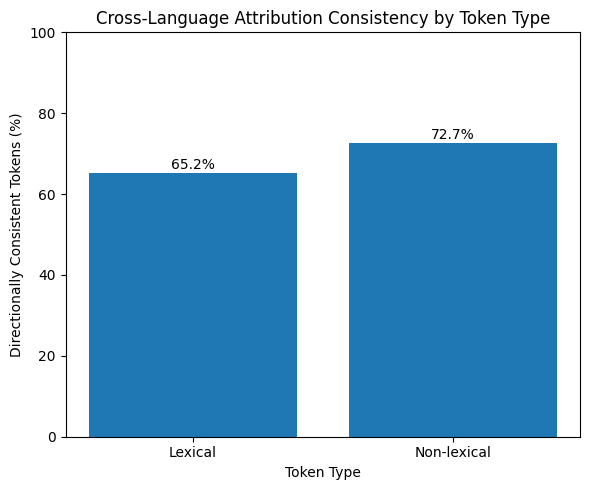

In [ ]:
# Visualise Attribution Consistency by Token Type

plot_df = (
    consistency_by_type_df.copy()
)

plot_df["Consistency (%)"] = (
    plot_df["Consistency_rate"] * 100
)

plt.figure(
    figsize=(6, 5)
)

plt.bar(
    plot_df["Token type"],
    plot_df["Consistency (%)"]
)

plt.ylim(
    0,
    100
)

plt.xlabel(
    "Token Type"
)

plt.ylabel(
    "Directionally Consistent Tokens (%)"
)

plt.title(
    "Cross-Language Attribution Consistency by Token Type"
)

for index, value in enumerate(
    plot_df["Consistency (%)"]
):
    plt.text(
        index,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

The cross-language comparison retained 651 language-conditioned token records and identified 88 unique tokens that satisfied the minimum occurrence threshold in at least two of the five selected languages. Of these shared tokens, 66 were classified as lexical features and 22 as non-lexical features.

Directional consistency was observed for 43 of the 66 lexical features (65.15%) and for 16 of the 22 non-lexical features (72.73%). Although non-lexical features exhibited a moderately higher consistency rate, the difference between the two categories was relatively small, suggesting that cross-language directional stability was not restricted to punctuation and structural features but was also observed for a substantial proportion of recurrent lexical features.

Consistency also varied according to the number of languages in which a token was retained. Tokens shared across two and three languages achieved consistency rates of 64.15% and 61.54%, respectively, whereas those retained across four and five languages reached 77.78% and 76.92%. However, because the four- and five-language groups contained only nine and thirteen shared tokens, respectively, these percentages should be interpreted descriptively rather than as evidence of a systematic relationship between language coverage and attribution consistency.

Several non-lexical features retained across all five selected languages exhibited stable attribution directions. Exclamation marks, commas, full stops, question marks and the closing square bracket consistently contributed towards the Human-written output, whereas hyphens and colons consistently contributed towards the AI-generated output. In contrast, whitespace representations, forward slashes and the token https changed attribution direction across languages, demonstrating that even widely shared structural features were not interpreted uniformly by the multilingual classifier.

The lexical category comprised complete words, alphabetic subword units and alphabetic structural fragments. Consequently, apparent consistency for alphabetic features should not be interpreted as semantic equivalence across languages. Overall, the findings suggest that the multilingual classifier combines transferable stylistic cues with language-conditioned lexical evidence, rather than relying exclusively on either language-specific vocabulary or universally shared structural features.


### 18.11.8 Cross-Language Lexical Overlap (Jaccard Similarity)

The preceding analysis examined whether tokens shared across multiple languages exhibited consistent attribution directions. However, directional consistency alone does not indicate the overall extent to which the explanatory vocabularies of individual languages overlap.

To provide a complementary comparison, pairwise lexical overlap between the language-specific explanation vocabularies is quantified using the Jaccard similarity coefficient. For each selected language, a language-specific explanation vocabulary is constructed from the recurrent lexical tokens retained by the within-language occurrence threshold. Non-lexical features are excluded so that shared punctuation and structural symbols do not artificially inflate the estimated similarity between languages.

For each pair of languages, Jaccard similarity is calculated as the number of lexical tokens appearing in both language-specific vocabularies divided by the total number of unique lexical tokens appearing in either vocabulary. A value of 1 indicates identical token sets, whereas a value of 0 indicates no shared lexical tokens.

This analysis compares the presence of recurrent explanatory features rather than their SHAP magnitude or attribution direction. It therefore complements, rather than replaces, the preceding cross-language directional consistency analysis.

In [ ]:
# Construct Language-Specific Lexical Token Sets

jaccard_source_df = language_token_summary_df.copy()


jaccard_source_df["Token type"] = (
    jaccard_source_df["Token"]
    .apply(classify_token_type)
)

# Retain lexical features only
lexical_jaccard_df = (
    jaccard_source_df[
        jaccard_source_df["Token type"] == "Lexical"
    ]
    .copy()
)

# Normalise only leading and trailing whitespace.
# Token casing is preserved because the tokenizer may treat
# differently cased forms as separate explanatory features.
lexical_jaccard_df["Token_normalised"] = (
    lexical_jaccard_df["Token"]
    .astype(str)
    .str.strip()
)

# Remove empty token representations
lexical_jaccard_df = (
    lexical_jaccard_df[
        lexical_jaccard_df["Token_normalised"] != ""
    ]
    .copy()
)

# Detect the language column safely
possible_language_columns = [
    "Language",
    "language"
]

language_column = next(
    (
        column
        for column in possible_language_columns
        if column in lexical_jaccard_df.columns
    ),
    None
)

if language_column is None:
    raise KeyError(
        "No language column was found. Expected either "
        "'Language' or 'language' in language_token_summary_df."
    )

# Construct one lexical token set per language
language_lexical_sets = {
    language: set(
        group["Token_normalised"]
        .dropna()
        .tolist()
    )
    for language, group in lexical_jaccard_df.groupby(
        language_column
    )
}

selected_jaccard_languages = list(
    language_lexical_sets.keys()
)

print(
    "Languages included in the Jaccard analysis:",
    selected_jaccard_languages
)

lexical_set_size_df = pd.DataFrame({
    "Language": selected_jaccard_languages,
    "Retained lexical tokens": [
        len(language_lexical_sets[language])
        for language in selected_jaccard_languages
    ]
})

display(
    lexical_set_size_df.sort_values(
        "Retained lexical tokens",
        ascending=False
    )
)

Languages included in the Jaccard analysis: ['en', 'hu', 'ru', 'sk', 'sl']


,Language,Retained lexical tokens
4,sl,151
2,ru,117
3,sk,115
0,en,75
1,hu,51


In [ ]:
# Compute Pairwise Jaccard Similarity

jaccard_similarity_df = pd.DataFrame(
    index=selected_jaccard_languages,
    columns=selected_jaccard_languages,
    dtype=float
)

shared_lexical_count_df = pd.DataFrame(
    index=selected_jaccard_languages,
    columns=selected_jaccard_languages,
    dtype=int
)

for language_a in selected_jaccard_languages:

    tokens_a = language_lexical_sets[language_a]

    for language_b in selected_jaccard_languages:

        tokens_b = language_lexical_sets[language_b]

        intersection = tokens_a.intersection(tokens_b)
        union = tokens_a.union(tokens_b)

        if len(union) == 0:
            jaccard_similarity = np.nan
        else:
            jaccard_similarity = (
                len(intersection)
                / len(union)
            )

        jaccard_similarity_df.loc[
            language_a,
            language_b
        ] = jaccard_similarity

        shared_lexical_count_df.loc[
            language_a,
            language_b
        ] = len(intersection)

print("Pairwise Jaccard similarity matrix:")

display(
    jaccard_similarity_df.round(3)
)

print("Number of shared lexical tokens:")

display(
    shared_lexical_count_df.astype(int)
)

Pairwise Jaccard similarity matrix:


,en,hu,ru,sk,sl
en,1.000,0.178,0.021,0.098,0.076
hu,0.178,1.000,0.024,0.145,0.104
ru,0.021,0.024,1.000,0.018,0.015
sk,0.098,0.145,0.018,1.000,0.182
sl,0.076,0.104,0.015,0.182,1.000


Number of shared lexical tokens:


,en,hu,ru,sk,sl
en,75,19,4,17,16
hu,19,51,4,21,19
ru,4,4,117,4,4
sk,17,21,4,115,41
sl,16,19,4,41,151


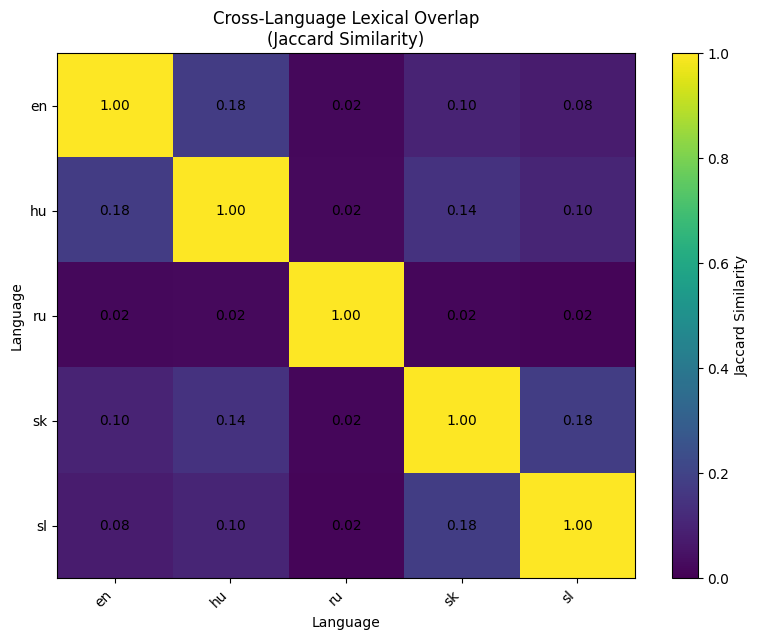

In [ ]:
# Visualise Pairwise Jaccard Similarity

jaccard_values = (
    jaccard_similarity_df
    .astype(float)
    .values
)

fig, ax = plt.subplots(
    figsize=(8, 6.5)
)

heatmap = ax.imshow(
    jaccard_values,
    vmin=0,
    vmax=1,
    aspect="auto"
)

ax.set_xticks(
    np.arange(
        len(selected_jaccard_languages)
    )
)

ax.set_yticks(
    np.arange(
        len(selected_jaccard_languages)
    )
)

ax.set_xticklabels(
    selected_jaccard_languages,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    selected_jaccard_languages
)

ax.set_xlabel("Language")
ax.set_ylabel("Language")

ax.set_title(
    "Cross-Language Lexical Overlap\n"
    "(Jaccard Similarity)"
)

# Add similarity values inside each cell
for row_index in range(
    len(selected_jaccard_languages)
):

    for column_index in range(
        len(selected_jaccard_languages)
    ):

        similarity_value = (
            jaccard_values[
                row_index,
                column_index
            ]
        )

        if np.isnan(similarity_value):
            display_value = "NA"
        else:
            display_value = (
                f"{similarity_value:.2f}"
            )

        ax.text(
            column_index,
            row_index,
            display_value,
            ha="center",
            va="center"
        )

colour_bar = fig.colorbar(
    heatmap,
    ax=ax
)

colour_bar.set_label(
    "Jaccard Similarity"
)

plt.tight_layout()
plt.show()

In [ ]:
# Summarise Most and Least Similar Language Pairs

language_pair_records = []

for first_index, language_a in enumerate(
    selected_jaccard_languages
):

    for language_b in (
        selected_jaccard_languages[
            first_index + 1:
        ]
    ):

        tokens_a = language_lexical_sets[
            language_a
        ]

        tokens_b = language_lexical_sets[
            language_b
        ]

        shared_tokens = (
            tokens_a.intersection(tokens_b)
        )

        union_tokens = (
            tokens_a.union(tokens_b)
        )

        similarity = (
            len(shared_tokens)
            / len(union_tokens)
            if len(union_tokens) > 0
            else np.nan
        )

        language_pair_records.append({
            "Language 1": language_a,
            "Language 2": language_b,
            "Shared lexical tokens": len(
                shared_tokens
            ),
            "Union lexical tokens": len(
                union_tokens
            ),
            "Jaccard similarity": similarity
        })

language_pair_similarity_df = pd.DataFrame(
    language_pair_records
)

language_pair_similarity_df = (
    language_pair_similarity_df
    .sort_values(
        "Jaccard similarity",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    language_pair_similarity_df
    .round({
        "Jaccard similarity": 3
    })
)

,Language 1,Language 2,Shared lexical tokens,Union lexical tokens,Jaccard similarity
0,sk,sl,41,225,0.182
1,en,hu,19,107,0.178
2,hu,sk,21,145,0.145
3,hu,sl,19,183,0.104
4,en,sk,17,173,0.098
5,en,sl,16,210,0.076
6,hu,ru,4,164,0.024
7,en,ru,4,188,0.021
8,ru,sk,4,228,0.018
9,ru,sl,4,264,0.015


The pairwise Jaccard analysis demonstrated that the explanatory lexical vocabularies were only partially shared across the five selected languages. Among the ten language pairs, the highest lexical overlap was observed between Slovak (sk) and Slovenian (sl), with a Jaccard similarity of 0.182, followed by English (en) and Hungarian (hu) with a similarity of 0.178. The lowest overlap occurred between Russian (ru) and Slovenian (sl), with a similarity of 0.015, while similarly low values were observed for Russian–Slovak (0.018) and Russian–English (0.021).

Across all language pairs, Jaccard similarity remained below 0.20, indicating that no two selected languages relied on highly similar sets of recurrent lexical explanatory features. Even the most similar language pair (Slovak and Slovenian) shared only 41 lexical tokens out of a combined vocabulary of 225 retained lexical features. These findings suggest that the multilingual classifier relied predominantly on language-specific lexical evidence, with only limited overlap in recurrent explanatory vocabularies across the selected languages.

The Jaccard analysis complements the preceding cross-language directional consistency analysis. Section 18.11.7 demonstrated that several shared structural features, particularly punctuation and formatting symbols, maintained consistent attribution directions across multiple languages. In contrast, the present analysis shows that the overall lexical explanation vocabularies remain largely distinct. Together, these findings indicate that the multilingual classifier combines transferable structural attribution patterns with language-specific lexical explanations rather than relying on a common cross-language lexical feature set.

These findings are specific to the five selected languages and to the recurrent lexical features retained under the predefined occurrence threshold.

### 18.11.9 Language-wise Most Influential Directional Features

To provide a concise qualitative summary of the preceding language-conditioned analyses, the strongest recurrent lexical features contributing towards the AI-generated and Human-written outputs are identified for each selected language. These features correspond to the highest positive and most negative mean signed SHAP values obtained after applying the within-language occurrence filtering described previously.

Only lexical features are included in this comparison so that language-specific explanatory vocabularies can be examined without the influence of shared punctuation or structural features. The resulting summary is intended to facilitate qualitative comparison across languages rather than provide an additional quantitative evaluation.

In [ ]:
# Comparative Summary of Language-wise Directional Features


TOP_FEATURES_PER_DIRECTION = 5

language_summary_source_df = (
    language_token_summary_df.copy()
)

# Use the same lexical / non-lexical definition
language_summary_source_df["Token type"] = (
    language_summary_source_df["Token"]
    .apply(classify_token_type)
)

# Retain lexical features only
language_summary_source_df = (
    language_summary_source_df[
        language_summary_source_df["Token type"] == "Lexical"
    ]
    .copy()
)

# Detect language column
possible_language_columns = [
    "Language",
    "language"
]

language_column = next(
    (
        column
        for column in possible_language_columns
        if column in language_summary_source_df.columns
    ),
    None
)

if language_column is None:
    raise KeyError(
        "No language column was found in "
        "language_token_summary_df."
    )

# Clean token display
language_summary_source_df["Token_display"] = (
    language_summary_source_df["Token"]
    .astype(str)
    .str.strip()
)

language_summary_source_df = (
    language_summary_source_df[
        language_summary_source_df["Token_display"] != ""
    ]
    .copy()
)

language_summary_records = []

for language, language_df in (
    language_summary_source_df
    .groupby(language_column)
):

    # Strongest AI-oriented lexical features
    top_ai_features = (
        language_df[
            language_df["Mean_Signed_SHAP"] > 0
        ]
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=False
        )
        .head(TOP_FEATURES_PER_DIRECTION)
    )

    # Strongest Human-oriented lexical features
    top_human_features = (
        language_df[
            language_df["Mean_Signed_SHAP"] < 0
        ]
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=True
        )
        .head(TOP_FEATURES_PER_DIRECTION)
    )

    ai_feature_text = ", ".join(
        top_ai_features["Token_display"].tolist()
    )

    human_feature_text = ", ".join(
        top_human_features["Token_display"].tolist()
    )

    language_summary_records.append({
        "Language": language,
        "Strongest AI-oriented lexical features": (
            ai_feature_text
        ),
        "Strongest Human-oriented lexical features": (
            human_feature_text
        )
    })

language_directional_summary_df = pd.DataFrame(
    language_summary_records
)

display(language_directional_summary_df)

,Language,Strongest AI-oriented lexical features,Strongest Human-oriented lexical features
0,en,"are, able, at, http, about","m, c, com, so, n"
1,hu,"vagy, meg, hogy, A, át","USER, o, ny, n, e"
2,ru,"В, на, ует, люд, ты","ый, USER, что, ю, ка"
3,sk,"mô, exp, íska, som, náj","Gab, https, čo, ma, to"
4,sl,"Slovenij, tudi, mlad, Ne, naša","p, co, USER, ko, v"


The qualitative summary highlights clear differences in the recurrent lexical features that most strongly influenced the multilingual classifier across the five selected languages. Although each language contained highly influential recurrent lexical features, the dominant explanatory vocabularies differed substantially from one language to another.

Only a small number of lexical features, most notably the placeholder token USER, appeared among the strongest Human-oriented features in more than one language. In contrast, most highly ranked lexical features were unique to individual languages, reflecting language-specific vocabulary, morphology and subword tokenisation. For example, the highest-ranked English features included common function words and web-related tokens, whereas Hungarian, Russian, Slovak and Slovenian were characterised by distinct language-specific lexical items and subword units.

These qualitative observations are consistent with the preceding Jaccard similarity analysis, which demonstrated limited lexical overlap across the selected languages, while also complementing the cross-language directional consistency analysis by illustrating the recurrent lexical features that exerted the strongest influence within each language. Overall, the qualitative summaries reinforce the conclusion that the multilingual classifier relies predominantly on language-specific lexical evidence, with only limited recurrence of individual lexical features across the selected languages.

### 18.12 Local SHAP Case Studies

While the preceding analyses examine attribution patterns at aggregate and subgroup levels, local explanations are used to illustrate how individual token contributions combine within specific model decisions.

Four benchmark cases are examined: one correctly classified Human-written text, one correctly classified AI-generated text, one False Positive and one False Negative. The purpose of these examples is not to generalise from individual texts, but to provide qualitative illustrations of the decision patterns identified in the preceding global, error-specific and language-conditioned analyses.

Cases are selected directly from the previously constructed language-controlled error-specific SHAP subset, ensuring that no additional SHAP computation is required and that the local explanations remain aligned with the controlled error analysis presented earlier. Within each prediction-outcome group, samples are ordered by their predicted AI probability and the observation at the middle position is selected. This procedure reduces the likelihood of choosing only unusually extreme or visually convenient cases, although the selected examples remain illustrative rather than statistically representative of the full outcome groups.

For each selected case, the strongest positive and negative token-level SHAP contributions are extracted from the explanations previously generated for the error-specific subset. Positive contributions shift the model output towards the AI-generated class, whereas negative contributions shift it towards the Human-written class.

Only the largest absolute token-level contributions are displayed in tabular and graphical form to provide a concise view of the local decision structure. Whitespace representations are retained in the underlying explanations but displayed explicitly for readability.

In [ ]:
# Select Representative Local SHAP Cases

LOCAL_OUTCOME_ORDER = [
    "Correct Human",
    "Correct AI",
    "False Positive",
    "False Negative"
]

local_case_indices = []

for outcome in LOCAL_OUTCOME_ORDER:

    outcome_subset = (
        error_shap_df[
            error_shap_df["shap_outcome"] == outcome
        ]
        .sort_values(
            "ai_probability",
            ascending=True
        )
    )

    if outcome_subset.empty:
        print(
            f"Warning: No samples were available for "
            f"the outcome '{outcome}'."
        )
        continue

    # Select the middle observation from the ordered
    # AI-probability distribution
    middle_position = len(outcome_subset) // 2

    selected_index = (
        outcome_subset
        .index[middle_position]
    )

    local_case_indices.append(selected_index)


# Display Selected Cases


local_cases_df = (
    error_shap_df
    .loc[local_case_indices]
    [
        [
            "shap_outcome",
            "text",
            "true_label",
            "predicted_label",
            "ai_probability",
            "language",
            "platform",
            "multi_label"
        ]
    ]
    .copy()
)

# Preserve the intended outcome order
local_cases_df["shap_outcome"] = pd.Categorical(
    local_cases_df["shap_outcome"],
    categories=LOCAL_OUTCOME_ORDER,
    ordered=True
)

local_cases_df = (
    local_cases_df
    .sort_values("shap_outcome")
)

display(local_cases_df)

In [ ]:
# Extract and Visualise Local SHAP Contributions

TOP_LOCAL_FEATURES = 8

for sample_idx in local_case_indices:

    # Retrieve sample metadata

    row = error_shap_df.loc[sample_idx]

    # Identify the sample's positional location within
    # the SHAP explanation collection
    shap_position = (
        error_shap_df.index
        .get_loc(sample_idx)
    )

    sample_explanation = (
        error_shap_values[shap_position]
    )

    sample_values = np.asarray(
        sample_explanation.values,
        dtype=float
    )

    sample_tokens = np.asarray(
        sample_explanation.data
    )

    # Extract SHAP values for the AI-generated class

    if sample_values.ndim == 2:
        ai_shap_values = (
            sample_values[:, AI_LABEL]
        )

    elif sample_values.ndim == 1:
        ai_shap_values = sample_values

    else:
        raise ValueError(
            "Unexpected SHAP value dimensions: "
            f"{sample_values.shape}"
        )


    # Construct local feature table

    local_feature_df = pd.DataFrame({
        "Token": sample_tokens.astype(str),
        "AI_SHAP": ai_shap_values
    })

    # Remove only empty technical entries
    local_feature_df = (
        local_feature_df[
            local_feature_df["Token"] != ""
        ]
        .copy()
    )

    local_feature_df["Absolute_SHAP"] = (
        local_feature_df["AI_SHAP"].abs()
    )

    # Display whitespace tokens explicitly
    local_feature_df["Token"] = (
        local_feature_df["Token"]
        .apply(
            lambda token:
                "<whitespace>"
                if str(token).isspace()
                else token
        )
    )

    # Retain the strongest absolute contributions
    local_feature_df = (
        local_feature_df
        .sort_values(
            "Absolute_SHAP",
            ascending=False
        )
        .head(TOP_LOCAL_FEATURES)
        .reset_index(drop=True)
    )

    # Add a readable direction column
    local_feature_df["Direction"] = np.where(
        local_feature_df["AI_SHAP"] > 0,
        "Towards AI",
        "Towards Human"
    )

    # Display sample information

    print("\n" + "=" * 75)

    print(
        "Prediction outcome:",
        row["shap_outcome"]
    )

    print(
        "True label:",
        row["true_label"]
    )

    print(
        "Predicted label:",
        row["predicted_label"]
    )

    print(
        "Language:",
        row["language"]
    )

    print(
        "Platform:",
        row["platform"]
    )

    print(
        "Generator / source:",
        row["multi_label"]
    )

    print(
        "AI probability:",
        round(
            float(row["ai_probability"]),
            6
        )
    )

    print("\nText:")
    print(row["text"])

    print(
        "\nStrongest local token contributions:"
    )

    display(
        local_feature_df[
            [
                "Token",
                "AI_SHAP",
                "Absolute_SHAP",
                "Direction"
            ]
        ]
    )


    # Visualise local directional contributions

    plot_df = (
        local_feature_df
        .sort_values(
            "AI_SHAP",
            ascending=True
        )
        .copy()
    )

    bar_colours = [
        "tab:red"
        if value > 0
        else "tab:blue"
        for value in plot_df["AI_SHAP"]
    ]

    plt.figure(figsize=(8, 4.8))

    bars = plt.barh(
        plot_df["Token"],
        plot_df["AI_SHAP"],
        color=bar_colours
    )

    plt.axvline(
        x=0,
        color="black",
        linewidth=1
    )

    plt.xlabel(
        "SHAP Contribution Towards the AI-Generated Output"
    )

    plt.ylabel("Token")

    plt.title(
        f"{row['shap_outcome']} – "
        "Local Token Contributions"
    )

    # Add contribution values beside each bar
    maximum_absolute_value = (
        plot_df["AI_SHAP"]
        .abs()
        .max()
    )

    annotation_offset = (
        maximum_absolute_value * 0.03
        if maximum_absolute_value > 0
        else 0.001
    )

    for bar, value in zip(
        bars,
        plot_df["AI_SHAP"]
    ):

        horizontal_position = (
            value + annotation_offset
            if value >= 0
            else value - annotation_offset
        )

        horizontal_alignment = (
            "left"
            if value >= 0
            else "right"
        )

        plt.text(
            horizontal_position,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va="center",
            ha=horizontal_alignment,
            fontsize=9
        )

    # Provide sufficient space for value annotations
    plt.xlim(
        -maximum_absolute_value * 1.25,
        maximum_absolute_value * 1.25
    )

    plt.figtext(
        0.5,
        -0.02,
        "Negative values support Human; "
        "positive values support AI.",
        ha="center",
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

In [27]:
from html import escape
from IPython.display import HTML, display


def display_colour_coded_shap_text(
    explanation,
    ai_label=1,
    title=None
):
    """
    Display a complete local SHAP explanation as colour-coded text.

    Red: contribution towards AI-generated.
    Blue: contribution towards Human-written.
    Darker shading: stronger absolute attribution.
    """

    sample_values = np.asarray(
        explanation.values,
        dtype=float
    )

    sample_tokens = np.asarray(
        explanation.data
    ).astype(str)

    if sample_values.ndim == 2:
        ai_shap_values = sample_values[:, ai_label]

    elif sample_values.ndim == 1:
        ai_shap_values = sample_values

    else:
        raise ValueError(
            "Unexpected SHAP value dimensions: "
            f"{sample_values.shape}"
        )

    valid_mask = sample_tokens != ""

    sample_tokens = sample_tokens[valid_mask]
    ai_shap_values = ai_shap_values[valid_mask]

    maximum_absolute_value = np.max(
        np.abs(ai_shap_values)
    )

    if maximum_absolute_value == 0:
        maximum_absolute_value = 1.0

    token_html = []

    for token, shap_value in zip(
        sample_tokens,
        ai_shap_values
    ):

        relative_magnitude = min(
            abs(shap_value) / maximum_absolute_value,
            1.0
        )

        opacity = 0.08 + 0.72 * relative_magnitude

        if shap_value > 0:
            background = (
                f"rgba(220, 53, 69, {opacity:.3f})"
            )
            direction = "Towards AI"

        elif shap_value < 0:
            background = (
                f"rgba(13, 110, 253, {opacity:.3f})"
            )
            direction = "Towards Human"

        else:
            background = (
                "rgba(150, 150, 150, 0.08)"
            )
            direction = "Neutral"

        safe_token = escape(token)

        token_html.append(
            "<span "
            f"title='{direction}; SHAP={shap_value:.5f}' "
            "style='"
            f"background-color:{background};"
            "white-space:pre-wrap;"
            "padding:2px 1px;"
            "border-radius:2px;"
            "'>"
            f"{safe_token}"
            "</span>"
        )

    display_title = (
        escape(title)
        if title is not None
        else "Local SHAP explanation"
    )

    html = f"""
    <div style="
        border:1px solid #cfcfcf;
        border-radius:8px;
        padding:14px;
        margin:10px 0 18px 0;
    ">
        <div style="
            font-weight:600;
            margin-bottom:10px;
        ">
            {display_title}
        </div>

        <div dir="auto" style="
            font-size:16px;
            line-height:2.1;
            white-space:pre-wrap;
            overflow-wrap:anywhere;
        ">
            {''.join(token_html)}
        </div>

        <div style="
            margin-top:12px;
            font-size:13px;
        ">
            <span style="
                background-color:rgba(220,53,69,0.45);
                padding:3px 7px;
                border-radius:3px;
            ">
                Towards AI
            </span>

            <span style="
                background-color:rgba(13,110,253,0.45);
                padding:3px 7px;
                border-radius:3px;
                margin-left:8px;
            ">
                Towards Human
            </span>

            <span style="margin-left:10px;">
                Darker shading indicates a stronger
                absolute contribution.
            </span>
        </div>
    </div>
    """

    display(HTML(html))

In [ ]:
print("Colour-Coded Local SHAP Visualisations")

for sample_idx in local_case_indices:

    row = error_shap_df.loc[sample_idx]

    shap_position = (
        error_shap_df.index
        .get_loc(sample_idx)
    )

    explanation = error_shap_values[
        shap_position
    ]

    print("\n" + "=" * 75)

    print(
        "Prediction outcome:",
        row["shap_outcome"]
    )

    print(
        "Language:",
        row["language"]
    )

    print(
        "Platform:",
        row["platform"]
    )

    print(
        "AI probability:",
        round(
            float(row["ai_probability"]),
            6
        )
    )

    display_colour_coded_shap_text(
        explanation=explanation,
        ai_label=1,
        title=(
            f"{row['shap_outcome']} – "
            "Colour-Coded Token Contributions"
        )
    )

The local explanations illustrate how individual predictions reflect combinations of AI-oriented and Human-oriented token-level evidence. All four selected cases contain contributions in both directions, although the relative balance and concentration of these contributions differ across prediction outcomes. In several examples, one or two tokens provide particularly strong local evidence, while the remaining features contribute smaller competing signals.

In the Correct Human example, the closing square bracket produced the strongest Human-oriented contribution, outweighing several weaker AI-oriented contributions associated with the opening bracket, the placeholder token USER and individual lexical fragments. The resulting balance of evidence strongly favoured the Human-written class, leading to an AI probability of 0.000560.

The Correct AI example also contained mixed attribution signals. Repeated occurrences of the token tá, together with hios and agam, contributed towards the AI-generated output, whereas fragments such as f, head and leath contributed towards the Human-written output. The model nevertheless assigned an AI probability of 0.999977. Because only the eight strongest absolute token-level contributions are displayed, the visible features represent a concise summary of the local explanation rather than a complete decomposition of the prediction.

The False Positive example illustrates how strong AI-oriented lexical and subword contributions can outweigh competing Human-oriented evidence. Although the placeholder token USER, the full stop and the closing square bracket contributed towards the Human-written output, stronger positive contributions from several Arabic lexical and subword features shifted the local explanation towards the AI-generated output. The classifier consequently assigned an AI probability of 0.998955 to a Human-written text.

Conversely, the False Negative example was dominated by Human-oriented evidence. Although the token aqui contributed towards the AI-generated output, its influence was outweighed by stronger negative contributions from com, the full stop and several URL-related fragments. The classifier therefore assigned an AI probability of only 0.002174 to an AI-generated text.

These illustrative cases are consistent with the preceding aggregate analyses, showing that highly confident predictions, including both correct classifications and misclassifications, can arise from strong combinations of opposing token-level evidence rather than uniformly supportive features. In particular, the False Positive and False Negative examples reinforce the earlier finding that prediction errors may occur despite strong local attribution patterns, reflecting how the relative weighting of competing token-level evidence can dominate the final decision. Nevertheless, the four cases are qualitative illustrations selected from the middle positions of their respective outcome-specific probability distributions. Their token-level patterns should therefore not be interpreted as representative linguistic characteristics of the corresponding languages, platforms, generators or prediction outcomes.

### 18.13 SHAP Summary

The SHAP analyses provided a comprehensive interpretation of the multilingual classifier at global, subgroup and local levels. Global explanations showed that the classifier relied on a combination of lexical, structural and punctuation-based features rather than on isolated keywords, indicating that the model learned distributed decision patterns across multilingual social-media texts.

The directional SHAP analysis further demonstrated that individual features systematically shifted predictions towards either the Human-written or AI-generated class. Error-specific analyses showed that prediction errors were not characterised by weak explanations. Instead, misclassifications frequently resulted from strong but competing token-level contributions, with False Positive predictions exhibiting particularly strong attribution magnitudes. These findings indicate that incorrect predictions arise from the relative weighting of multiple influential features rather than from the absence of informative evidence. Comparisons between correct and incorrect predictions further suggested that classification errors were often associated with changes in the weighting of recurrent shared features rather than entirely different explanatory vocabularies.

Language-conditioned analyses revealed substantial variation in the lexical features contributing to model decisions across the selected languages. Nevertheless, several structural and punctuation-based features exhibited consistent attribution directions, suggesting that the multilingual classifier combined transferable stylistic cues with language-dependent lexical evidence. This interpretation was further supported by the cross-language consistency analysis and the Jaccard similarity analysis, which showed that pairwise lexical overlap remained below 0.20 across all selected language pairs. Together, these findings indicate that structural attribution patterns transferred more consistently across languages than lexical explanatory features.

Finally, the local SHAP case studies illustrated how these aggregate attribution patterns manifested within individual predictions. Both correctly classified and misclassified examples contained competing Human-oriented and AI-oriented evidence, although the relative balance of these contributions differed across cases. The local explanations further demonstrated that highly confident misclassifications can arise from strong competing token-level evidence rather than only from uncertain predictions close to the decision boundary.

Overall, the SHAP analyses indicate that the multilingual classifier learned a combination of cross-language transferable structural patterns and language-specific lexical representations. Together, these findings improve the interpretability of the proposed detection framework, explain the mechanisms underlying both successful and erroneous predictions, and provide complementary evidence supporting the quantitative performance evaluation presented in the preceding sections.

## 19. Complementary Style-Level Analysis

The preceding SHAP analyses explained how individual token-level features influenced the multilingual classifier's predictions. Although these explanations provide insight into the model's internal decision-making process, they do not directly characterise the measurable stylistic properties of Human-written and AI-generated texts.

To complement the explainability analysis, this section examines a set of interpretable writing-style features extracted directly from the multilingual benchmark test set. These features capture complementary stylistic dimensions, including text length, lexical diversity, punctuation usage, formatting behaviour, social-media-specific content and numerical information.

The analyses investigate whether systematic stylistic differences exist between Human-written and AI-generated texts, whether these characteristics are associated with correct and incorrect model predictions, and whether similar patterns remain observable across different languages.

Unlike SHAP, which explains model behaviour through token-level feature attributions, the present analysis focuses on directly observable properties of the texts themselves. Together, the SHAP and style-level analyses provide a more comprehensive understanding of both the multilingual classifier's decision-making behaviour and the measurable stylistic characteristics of the underlying benchmark texts.

## 19.1 Style Feature Extraction

To enable quantitative comparisons of writing style, a set of interpretable stylistic features is extracted for every text in the multilingual benchmark test set. The analysis uses the previously constructed test-results data frame, which contains the original benchmark texts together with their true labels, predicted labels, AI-class probabilities and relevant metadata.

The features are computed directly from the original benchmark text field without applying additional text normalisation or preprocessing. This preserves punctuation, capitalisation, whitespace, URLs, mentions, hashtags and emojis, all of which may represent meaningful stylistic characteristics in social-media communication.

The extracted feature set includes text-length measures, lexical characteristics, punctuation usage, formatting behaviour, social-media-specific indicators and numerical content. These features are subsequently used to compare Human-written and AI-generated texts, prediction-outcome groups and language-specific patterns.

In [ ]:
# Prepare the Style Analysis Dataset

style_analysis_df = test_results_df.copy()

required_columns = [
    "text",
    "label",
    "predicted_label",
    "ai_probability",
    "language",
    "platform",
    "multi_label"
]

missing_columns = [
    column
    for column in required_columns
    if column not in style_analysis_df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

print("Benchmark texts:", len(style_analysis_df))
print("Available columns:", len(style_analysis_df.columns))

Benchmark texts: 140888
Available columns: 15


In [ ]:
# Define Style Feature Patterns

import re
import string


URL_PATTERN = re.compile(
    r"https?://\S+|www\.\S+",
    flags=re.IGNORECASE
)

MENTION_PATTERN = re.compile(
    r"@\w+",
    flags=re.UNICODE
)

HASHTAG_PATTERN = re.compile(
    r"#\w+",
    flags=re.UNICODE
)

WORD_PATTERN = re.compile(
    r"\b\w+\b",
    flags=re.UNICODE
)

EMOJI_PATTERN = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002700-\U000027BF"
    "]",
    flags=re.UNICODE
)

In [ ]:
# Define the Style Feature Extraction Function

def extract_style_features(text):
    """
    Extract interpretable writing-style features from a text.
    """

    text = "" if pd.isna(text) else str(text)

    words = WORD_PATTERN.findall(text)

    word_count = len(words)
    character_count = len(text)

    average_word_length = (
        np.mean([len(word) for word in words])
        if word_count > 0
        else 0.0
    )

    lexical_diversity = (
        len({word.lower() for word in words}) / word_count
        if word_count > 0
        else 0.0
    )

    punctuation_count = sum(
        character in string.punctuation
        for character in text
    )

    punctuation_ratio = (
        punctuation_count / character_count
        if character_count > 0
        else 0.0
    )

    uppercase_count = sum(
        character.isupper()
        for character in text
    )

    alphabetic_count = sum(
        character.isalpha()
        for character in text
    )

    uppercase_ratio = (
        uppercase_count / alphabetic_count
        if alphabetic_count > 0
        else 0.0
    )

    whitespace_count = sum(
        character.isspace()
        for character in text
    )

    whitespace_ratio = (
        whitespace_count / character_count
        if character_count > 0
        else 0.0
    )

    digit_count = sum(
        character.isdigit()
        for character in text
    )

    digit_ratio = (
        digit_count / character_count
        if character_count > 0
        else 0.0
    )

    return pd.Series(
        {
            "word_count": word_count,
            "character_count": character_count,
            "average_word_length": average_word_length,
            "lexical_diversity": lexical_diversity,
            "punctuation_count": punctuation_count,
            "punctuation_ratio": punctuation_ratio,
            "uppercase_ratio": uppercase_ratio,
            "whitespace_ratio": whitespace_ratio,
            "url_count": len(URL_PATTERN.findall(text)),
            "mention_count": len(MENTION_PATTERN.findall(text)),
            "hashtag_count": len(HASHTAG_PATTERN.findall(text)),
            "emoji_count": len(EMOJI_PATTERN.findall(text)),
            "digit_ratio": digit_ratio
        }
    )

In [ ]:
# Extract Style Features

style_feature_df = (
    style_analysis_df["text"]
    .apply(extract_style_features)
)

style_analysis_df = pd.concat(
    [
        style_analysis_df,
        style_feature_df
    ],
    axis=1
)

print("Style features extracted successfully.")
print("Number of texts:", len(style_analysis_df))
print(
    "Number of extracted style features:",
    len(style_feature_df.columns)
)

Style features extracted successfully.
Number of texts: 140888
Number of extracted style features: 13


In [ ]:
# Define the Style Feature List

style_features = [
    "word_count",
    "character_count",
    "average_word_length",
    "lexical_diversity",
    "punctuation_count",
    "punctuation_ratio",
    "uppercase_ratio",
    "whitespace_ratio",
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

In [ ]:
# Create Prediction Outcome Labels

style_analysis_df["prediction_outcome"] = np.select(
    [
        (
            style_analysis_df["label"] == 0
        )
        &
        (
            style_analysis_df["predicted_label"] == 0
        ),

        (
            style_analysis_df["label"] == 1
        )
        &
        (
            style_analysis_df["predicted_label"] == 1
        ),

        (
            style_analysis_df["label"] == 0
        )
        &
        (
            style_analysis_df["predicted_label"] == 1
        ),

        (
            style_analysis_df["label"] == 1
        )
        &
        (
            style_analysis_df["predicted_label"] == 0
        )
    ],
    [
        "Correct Human",
        "Correct AI",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

display(
    style_analysis_df[
        "prediction_outcome"
    ]
    .value_counts()
    .rename_axis("Prediction outcome")
    .reset_index(name="Samples")
)

,Prediction outcome,Samples
0,Correct AI,114920
1,Correct Human,15702
2,False Negative,8569
3,False Positive,1697


In [ ]:
# Validate the Extracted Features

missing_feature_values = (
    style_analysis_df[
        style_features
    ]
    .isna()
    .sum()
)

display(
    missing_feature_values
    .rename("Missing values")
    .to_frame()
)

print(
    "Total missing feature values:",
    int(missing_feature_values.sum())
)

print(
    "Any infinite values:",
    np.isinf(
        style_analysis_df[
            style_features
        ].to_numpy()
    ).any()
)

,Missing values
word_count,0
character_count,0
average_word_length,0
lexical_diversity,0
punctuation_count,0
punctuation_ratio,0
uppercase_ratio,0
whitespace_ratio,0
url_count,0
mention_count,0


Total missing feature values: 0
Any infinite values: False


In [ ]:
# Display Summary Statistics

style_summary_df = (
    style_analysis_df[
        style_features
    ]
    .describe()
    .T
    .reset_index()
    .rename(
        columns={
            "index": "Style feature"
        }
    )
)

display(
    style_summary_df.round(3)
)

,Style feature,count,mean,std,min,25%,50%,75%,max
0,word_count,140888.0,23.268,30.086,0.0,7.000,13.000,25.000,477.000
1,character_count,140888.0,143.219,191.617,4.0,42.000,82.000,157.000,16094.000
2,average_word_length,140888.0,4.992,2.298,0.0,4.202,4.833,5.517,617.846
3,lexical_diversity,140888.0,0.923,0.115,0.0,0.878,1.000,1.000,1.000
4,punctuation_count,140888.0,5.670,8.583,0.0,1.000,3.000,6.000,204.000
5,punctuation_ratio,140888.0,0.043,0.038,0.0,0.020,0.034,0.056,0.870
6,uppercase_ratio,140888.0,0.064,0.102,0.0,0.020,0.038,0.070,1.000
7,whitespace_ratio,140888.0,0.149,0.042,0.0,0.131,0.152,0.170,0.915
8,url_count,140888.0,0.066,0.292,0.0,0.000,0.000,0.000,17.000
9,mention_count,140888.0,0.001,0.041,0.0,0.000,0.000,0.000,4.000


In [ ]:
# Display Example Style Records

example_style_columns = [
    "text",
    "language",
    "label",
    "predicted_label",
    "ai_probability",
    "prediction_outcome"
] + style_features

display(
    style_analysis_df[
        example_style_columns
    ]
    .head()
)

The style-feature extraction pipeline was successfully applied to all 140,888 texts in the multilingual benchmark test set. Thirteen interpretable stylistic features were generated for every sample, capturing complementary aspects of text length, lexical characteristics, punctuation usage, formatting behaviour, social-media-specific content and numerical information.

Validation confirmed that all style features were computed successfully without missing or infinite values, indicating that the extraction pipeline operated consistently across the entire multilingual benchmark test set. The resulting dataset combines the original benchmark texts, model predictions and extracted stylistic characteristics within a single structured data frame, providing the foundation for all subsequent style-level analyses presented in this section.

## 19.2 Feature Distribution Overview

Before comparing Human-written and AI-generated texts, the overall distributions of the extracted style features are examined across the multilingual benchmark test set. This exploratory analysis provides a general overview of the stylistic characteristics present in the dataset and helps identify the typical ranges, variability and distributional behaviour of each feature.

Given the highly heterogeneous nature of social-media texts, several style features are expected to exhibit positively skewed distributions with a relatively small number of extreme observations. These observations are retained because they represent authentic benchmark samples evaluated by the classifier.

To improve interpretability, the extracted style features are organised into five categories: text length, lexical characteristics, punctuation usage, formatting behaviour and social-media-specific content. Within each category, feature distributions are visualised using boxplots with outliers suppressed for visual clarity, although all observations remain included in the underlying data.

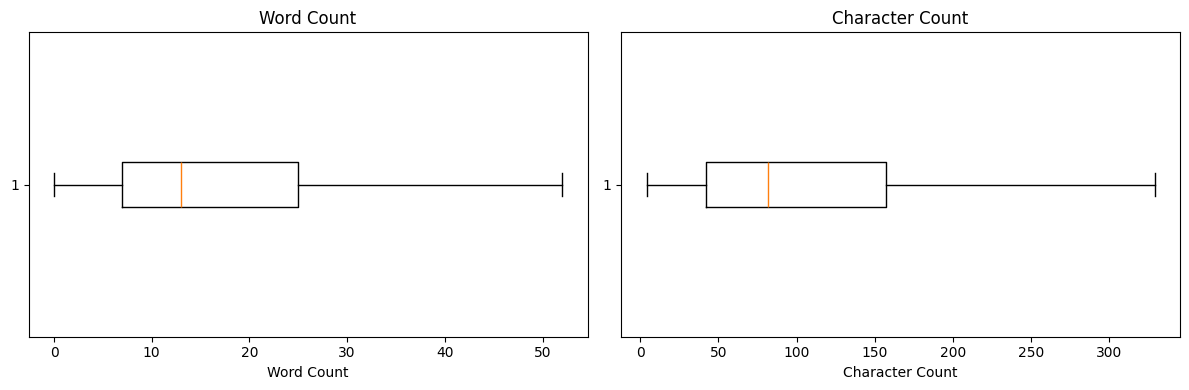

In [ ]:
# Text Length Feature Distributions

fig, axes = plt.subplots(1, 2, figsize=(12,4))

features = [
    "word_count",
    "character_count"
]

titles = [
    "Word Count",
    "Character Count"
]

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    ax.boxplot(
        style_analysis_df[feature],
        vert=False,
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel(title)

plt.tight_layout()
plt.show()

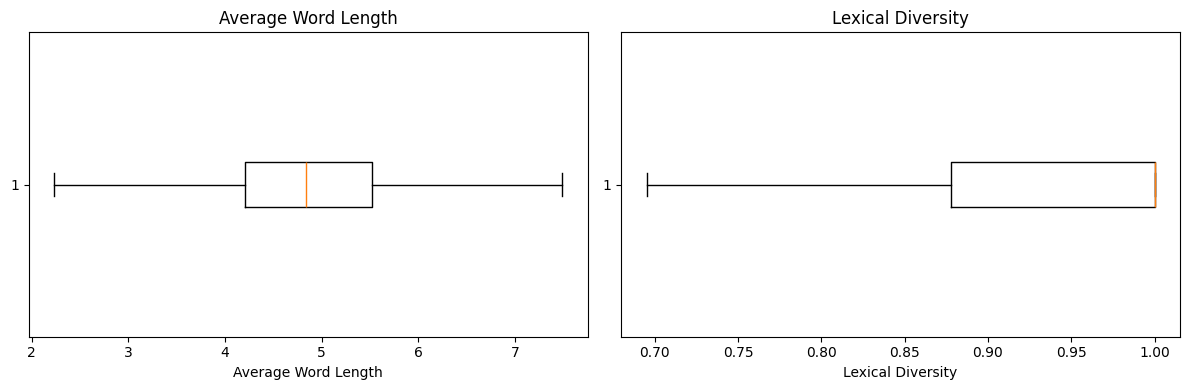

In [ ]:
# Lexical Feature Distributions

fig, axes = plt.subplots(1,2, figsize=(12,4))

features = [
    "average_word_length",
    "lexical_diversity"
]

titles = [
    "Average Word Length",
    "Lexical Diversity"
]

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    ax.boxplot(
        style_analysis_df[feature],
        vert=False,
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel(title)

plt.tight_layout()
plt.show()

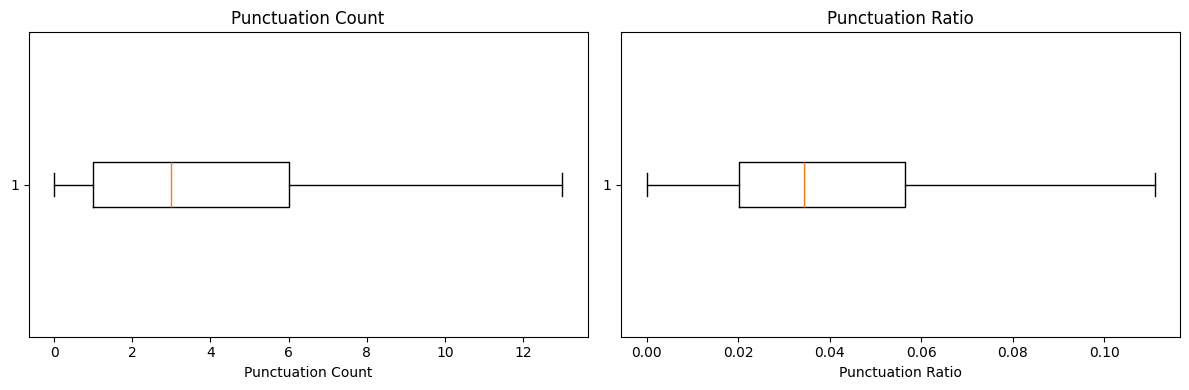

In [ ]:
# Punctuation Feature Distributions

fig, axes = plt.subplots(1,2, figsize=(12,4))

features = [
    "punctuation_count",
    "punctuation_ratio"
]

titles = [
    "Punctuation Count",
    "Punctuation Ratio"
]

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    ax.boxplot(
        style_analysis_df[feature],
        vert=False,
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel(title)

plt.tight_layout()
plt.show()

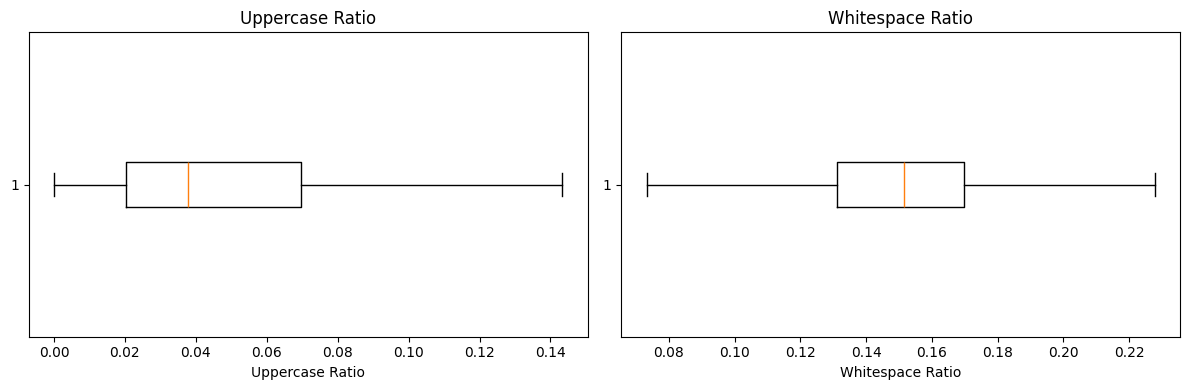

In [ ]:
# Formatting Feature Distributions

fig, axes = plt.subplots(1,2, figsize=(12,4))

features = [
    "uppercase_ratio",
    "whitespace_ratio"
]

titles = [
    "Uppercase Ratio",
    "Whitespace Ratio"
]

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    ax.boxplot(
        style_analysis_df[feature],
        vert=False,
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel(title)

plt.tight_layout()
plt.show()

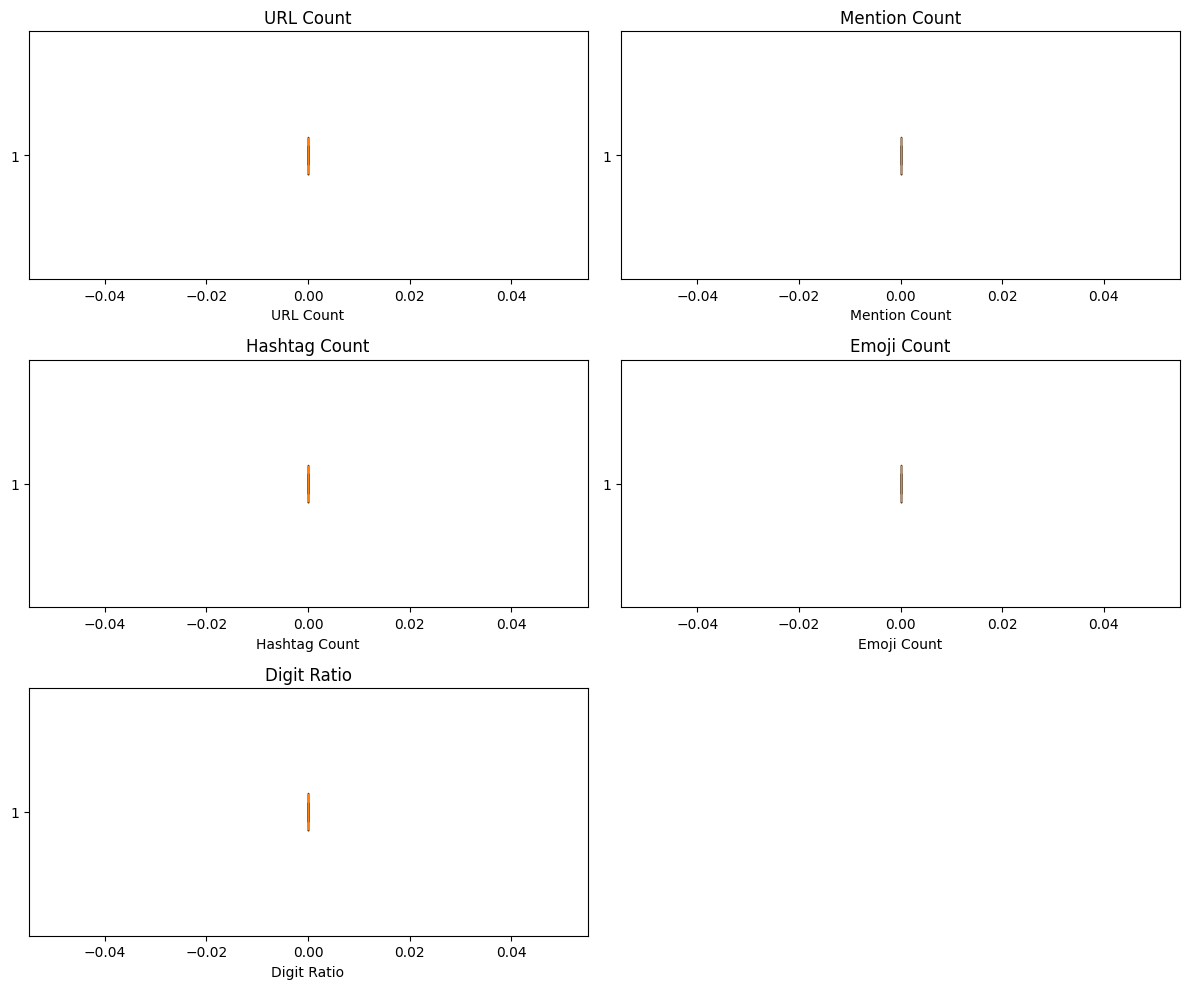

In [ ]:
# Social-Media Feature Distributions

fig, axes = plt.subplots(3,2, figsize=(12,10))

axes = axes.flatten()

features = [
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

titles = [
    "URL Count",
    "Mention Count",
    "Hashtag Count",
    "Emoji Count",
    "Digit Ratio"
]

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    ax.boxplot(
        style_analysis_df[feature],
        vert=False,
        showfliers=False
    )

    ax.set_title(title)
    ax.set_xlabel(title)

# Son boş ekseni kaldır
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

The extracted style features exhibited substantial variability across the multilingual benchmark test set. Text-length measures showed broad distributions, reflecting the heterogeneous nature of social-media posts, while average word length remained relatively stable across the corpus. Lexical diversity was generally high, indicating that many texts contained a high proportion of unique words relative to their length.

Punctuation and formatting features displayed moderate variability, suggesting noticeable differences in writing style without extreme dispersion across the majority of samples. In contrast, social-media-specific features, including URLs, mentions, hashtags, emojis and numerical content, were heavily concentrated at zero, indicating that these elements were absent from most benchmark texts and occurred only in a relatively small subset of samples. Consequently, the corresponding boxplots appear highly compressed because the median and interquartile range are both centred at zero for the majority of observations.

Overall, the feature distributions demonstrate considerable stylistic diversity across the multilingual benchmark test set while highlighting that several social-media-specific characteristics occur relatively infrequently. These descriptive observations characterise the overall stylistic composition of the benchmark dataset rather than differences between Human-written and AI-generated texts, thereby establishing the context for the class-level comparisons presented in the following subsection.

## 19.3 Style Differences Between Human-written and AI-generated Texts

This subsection compares the extracted style features between Human-written and AI-generated texts to investigate whether measurable stylistic differences exist between the two classes. Since several style features exhibit non-normal and highly skewed distributions, the comparison is based primarily on robust descriptive statistics, with the median and interquartile range (IQR) serving as the principal measures of central tendency and variability. Mean and standard deviation are additionally reported to provide complementary descriptive summaries.

For each extracted feature, class-specific distributions are visualised using boxplots, enabling direct comparison of central tendency, variability and distributional spread between Human-written and AI-generated texts. Because several social-media-specific features are sparse, their class-level prevalence is additionally summarised using the percentage of texts containing non-zero values. Together, these descriptive comparisons complement the SHAP explainability analysis by examining whether the behavioural patterns learned by the classifier are also reflected in directly observable stylistic characteristics of the benchmark texts.

In [ ]:
# Create Human-readable Class Labels

style_analysis_df["class_name"] = (
    style_analysis_df["true_label"]
    .map({
        0: "Human-written",
        1: "AI-generated"
    })
)

print(style_analysis_df["class_name"].value_counts())

class_name
AI-generated     123489
Human-written     17399
Name: count, dtype: int64


In [ ]:
# Class-wise Style Feature Summary

style_features = [
    "word_count",
    "character_count",
    "average_word_length",
    "lexical_diversity",
    "punctuation_count",
    "punctuation_ratio",
    "uppercase_ratio",
    "whitespace_ratio",
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

class_summary_rows = []

for class_name, class_df in style_analysis_df.groupby("class_name"):

    for feature in style_features:

        q1 = class_df[feature].quantile(0.25)
        q3 = class_df[feature].quantile(0.75)

        class_summary_rows.append({
            "Class": class_name,
            "Feature": feature,
            "Median": class_df[feature].median(),
            "IQR": q3 - q1,
            "Mean": class_df[feature].mean(),
            "Standard Deviation": class_df[feature].std()
        })

class_style_summary_df = pd.DataFrame(class_summary_rows)

class_style_summary_df[
    ["Median", "IQR", "Mean", "Standard Deviation"]
] = class_style_summary_df[
    ["Median", "IQR", "Mean", "Standard Deviation"]
].round(4)

display(class_style_summary_df)

,Class,Feature,Median,IQR,Mean,Standard Deviation
0,AI-generated,word_count,14.0000,19.0000,24.4815,31.0712
1,AI-generated,character_count,86.0000,118.0000,150.9958,198.6408
2,AI-generated,average_word_length,4.8750,1.2828,5.0468,2.3572
3,AI-generated,lexical_diversity,0.9697,0.1250,0.9200,0.1152
4,AI-generated,punctuation_count,3.0000,5.0000,5.7203,8.6364
5,AI-generated,punctuation_ratio,0.0337,0.0323,0.0414,0.0345
6,AI-generated,uppercase_ratio,0.0357,0.0425,0.0547,0.0818
7,AI-generated,whitespace_ratio,0.1520,0.0369,0.1500,0.0408
8,AI-generated,url_count,0.0000,0.0000,0.0442,0.2382
9,AI-generated,mention_count,0.0000,0.0000,0.0015,0.0427


In [ ]:
# Pivoted Median and IQR Comparison Table

median_comparison_df = (
    class_style_summary_df
    .pivot(
        index="Feature",
        columns="Class",
        values="Median"
    )
    .reset_index()
)

iqr_comparison_df = (
    class_style_summary_df
    .pivot(
        index="Feature",
        columns="Class",
        values="IQR"
    )
    .reset_index()
)

median_comparison_df.columns.name = None
iqr_comparison_df.columns.name = None

print("Class-wise Median Values")
display(median_comparison_df)

print("Class-wise Interquartile Ranges")
display(iqr_comparison_df)

Class-wise Median Values


,Feature,AI-generated,Human-written
0,average_word_length,4.8750,4.4400
1,character_count,86.0000,45.0000
2,digit_ratio,0.0000,0.0000
3,emoji_count,0.0000,0.0000
4,hashtag_count,0.0000,0.0000
5,lexical_diversity,0.9697,1.0000
6,mention_count,0.0000,0.0000
7,punctuation_count,3.0000,2.0000
8,punctuation_ratio,0.0337,0.0476
9,uppercase_ratio,0.0357,0.0714


Class-wise Interquartile Ranges


,Feature,AI-generated,Human-written
0,average_word_length,1.2828,1.5833
1,character_count,118.0000,93.0000
2,digit_ratio,0.0000,0.0073
3,emoji_count,0.0000,0.0000
4,hashtag_count,0.0000,0.0000
5,lexical_diversity,0.1250,0.0769
6,mention_count,0.0000,0.0000
7,punctuation_count,5.0000,7.0000
8,punctuation_ratio,0.0323,0.0909
9,uppercase_ratio,0.0425,0.1233


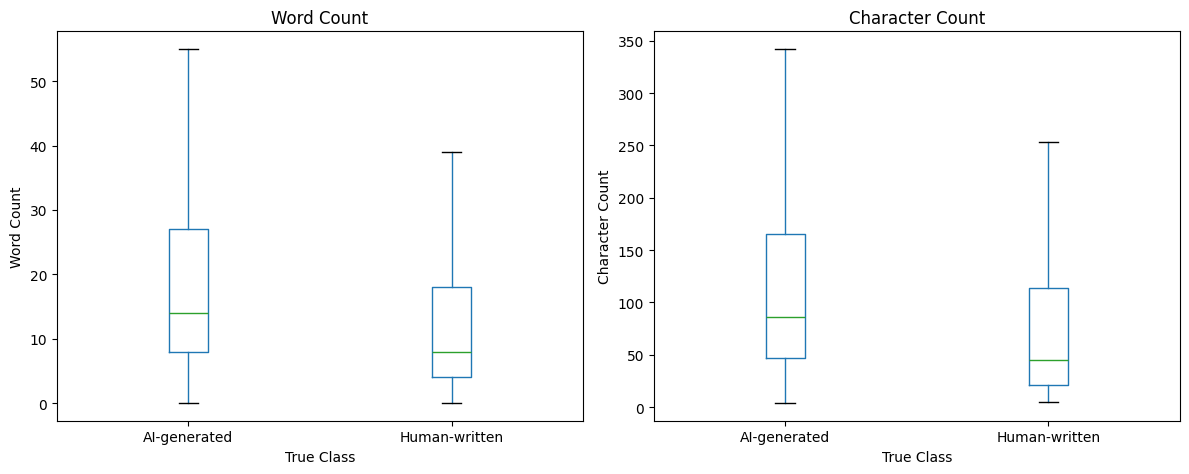

In [ ]:
# Human vs AI Text Length Features

text_length_features = [
    "word_count",
    "character_count"
]

text_length_titles = [
    "Word Count",
    "Character Count"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    text_length_features,
    text_length_titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="class_name",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("True Class")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

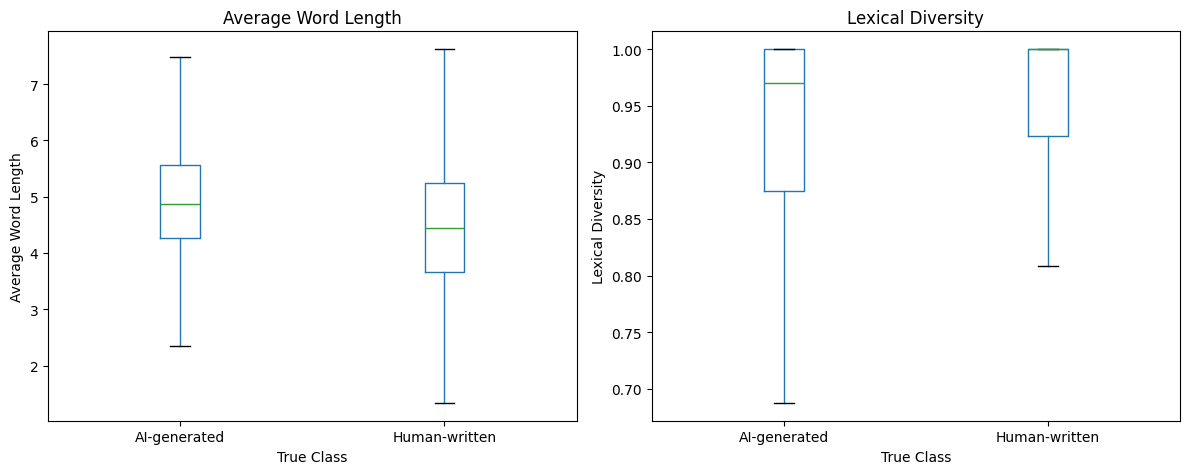

In [ ]:
# Human vs AI Lexical Features

lexical_features = [
    "average_word_length",
    "lexical_diversity"
]

lexical_titles = [
    "Average Word Length",
    "Lexical Diversity"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    lexical_features,
    lexical_titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="class_name",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("True Class")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

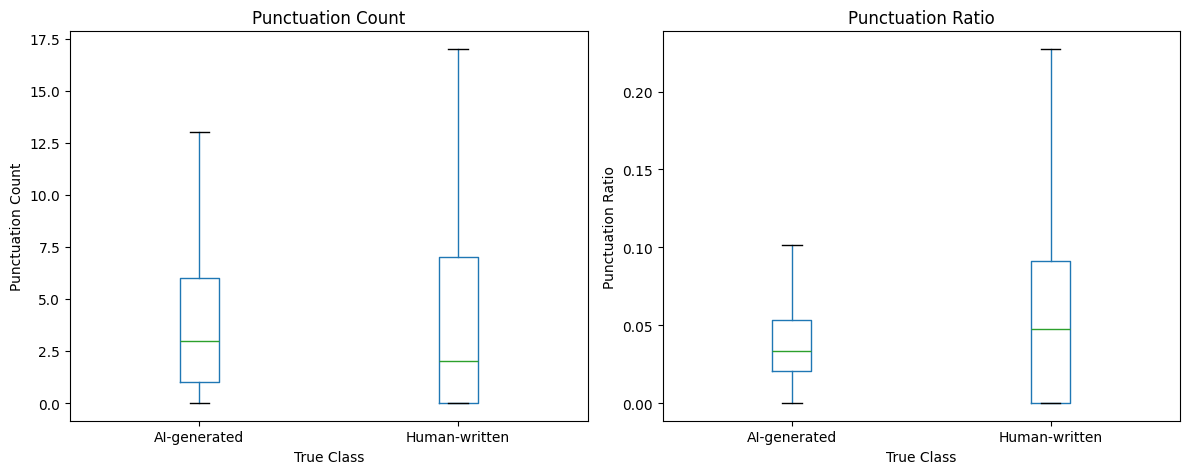

In [ ]:
# Human vs AI Punctuation Features

punctuation_features = [
    "punctuation_count",
    "punctuation_ratio"
]

punctuation_titles = [
    "Punctuation Count",
    "Punctuation Ratio"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    punctuation_features,
    punctuation_titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="class_name",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("True Class")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

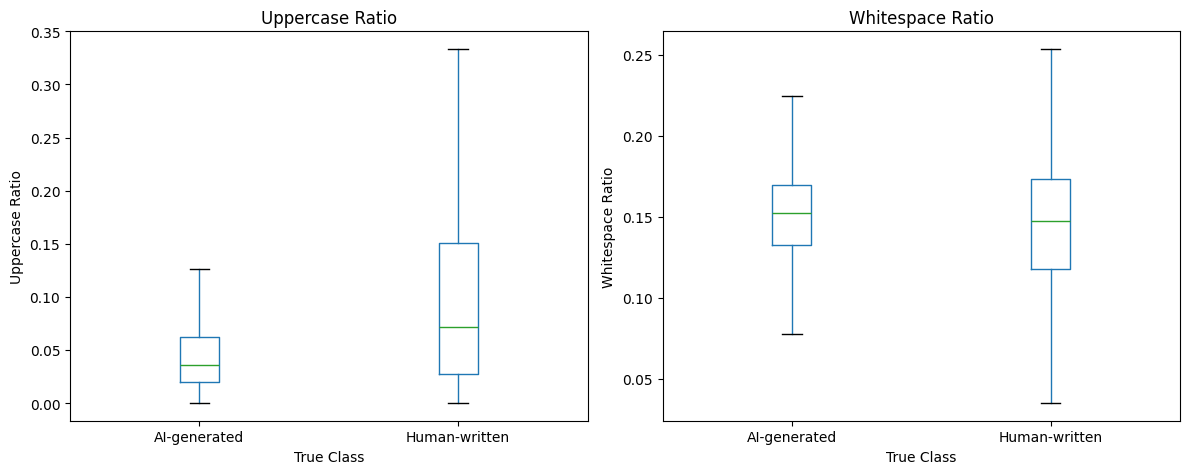

In [ ]:
# Human vs AI Formatting Features

formatting_features = [
    "uppercase_ratio",
    "whitespace_ratio"
]

formatting_titles = [
    "Uppercase Ratio",
    "Whitespace Ratio"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    formatting_features,
    formatting_titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="class_name",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("True Class")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

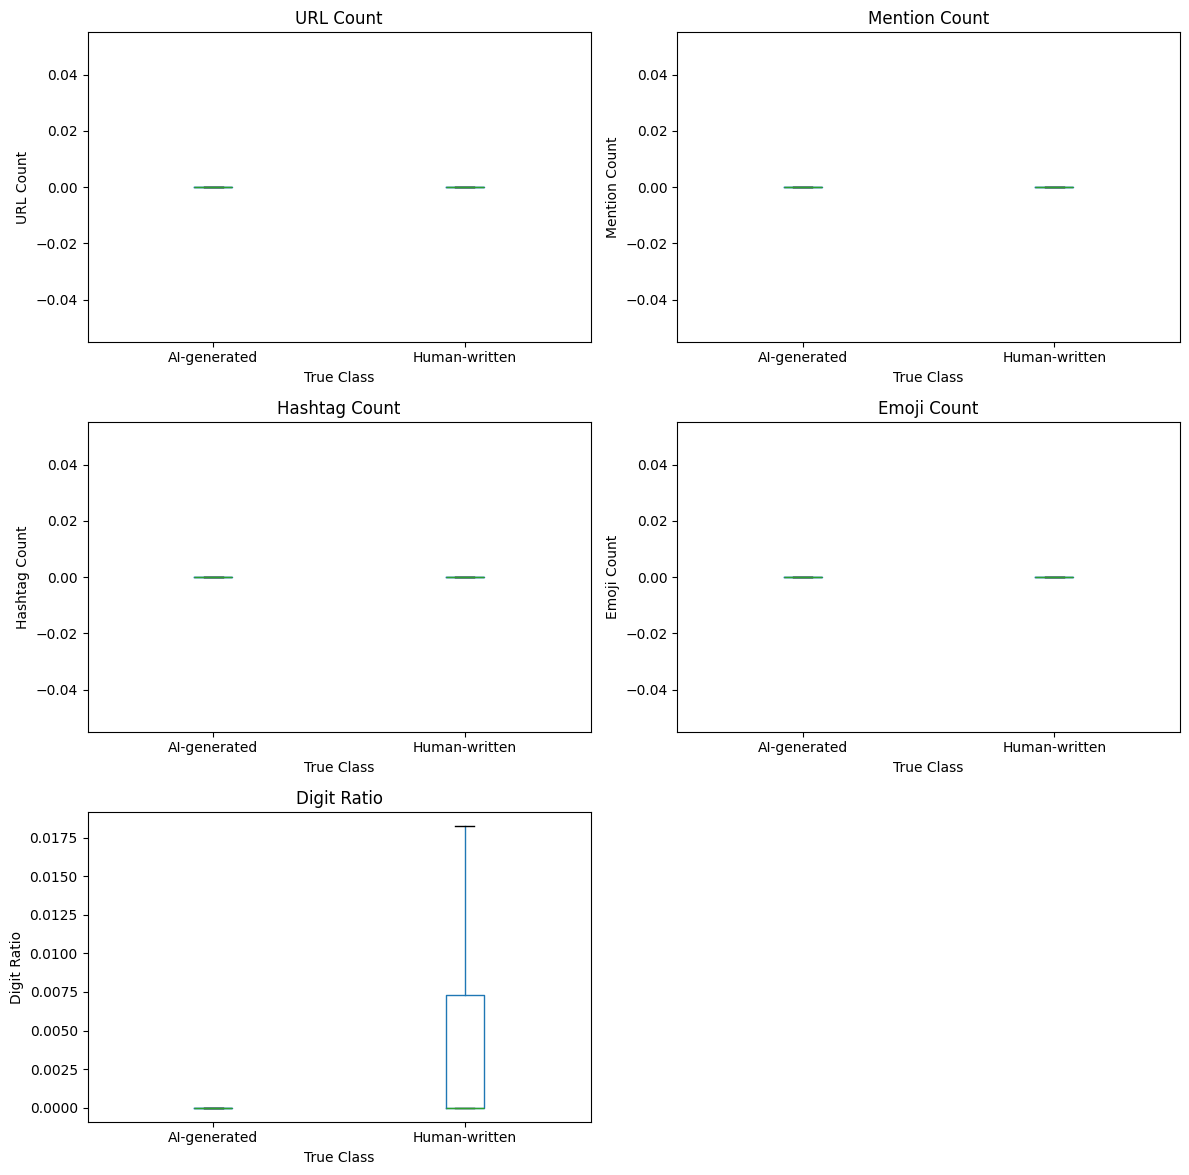

In [ ]:
# Human vs AI Social-Media Features

social_media_features = [
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

social_media_titles = [
    "URL Count",
    "Mention Count",
    "Hashtag Count",
    "Emoji Count",
    "Digit Ratio"
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, feature, title in zip(
    axes,
    social_media_features,
    social_media_titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="class_name",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("True Class")
    ax.set_ylabel(title)

fig.delaxes(axes[-1])

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
# Non-zero Prevalence of Sparse Social-Media Features

sparse_features = [
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

non_zero_rows = []

for class_name, class_df in style_analysis_df.groupby("class_name"):

    for feature in sparse_features:

        non_zero_count = (class_df[feature] > 0).sum()
        total_count = len(class_df)

        non_zero_rows.append({
            "Class": class_name,
            "Feature": feature,
            "Non-zero Count": non_zero_count,
            "Total Samples": total_count,
            "Non-zero Percentage": (
                non_zero_count / total_count
            ) * 100
        })

non_zero_prevalence_df = pd.DataFrame(non_zero_rows)

non_zero_prevalence_df["Non-zero Percentage"] = (
    non_zero_prevalence_df["Non-zero Percentage"]
    .round(2)
)

display(non_zero_prevalence_df)

,Class,Feature,Non-zero Count,Total Samples,Non-zero Percentage
0,AI-generated,url_count,4896,123489,3.96
1,AI-generated,mention_count,169,123489,0.14
2,AI-generated,hashtag_count,6142,123489,4.97
3,AI-generated,emoji_count,5902,123489,4.78
4,AI-generated,digit_ratio,18178,123489,14.72
5,Human-written,url_count,3371,17399,19.37
6,Human-written,mention_count,4,17399,0.02
7,Human-written,hashtag_count,1984,17399,11.40
8,Human-written,emoji_count,1873,17399,10.76
9,Human-written,digit_ratio,4747,17399,27.28


In [ ]:
# Pivoted Non-zero Percentage Table

non_zero_percentage_table = (
    non_zero_prevalence_df
    .pivot(
        index="Feature",
        columns="Class",
        values="Non-zero Percentage"
    )
    .reset_index()
)

non_zero_percentage_table.columns.name = None

display(non_zero_percentage_table)

,Feature,AI-generated,Human-written
0,digit_ratio,14.72,27.28
1,emoji_count,4.78,10.76
2,hashtag_count,4.97,11.40
3,mention_count,0.14,0.02
4,url_count,3.96,19.37


The class-level comparison revealed several measurable stylistic differences between Human-written and AI-generated texts. AI-generated texts were generally longer, with a median word count of 14 compared with 8 for Human-written texts, and a median character count of 86 compared with 45. AI-generated texts also exhibited slightly longer average word lengths, whereas Human-written texts showed marginally higher lexical diversity.

Differences were also observed in punctuation and formatting behaviour. AI-generated texts contained a higher median number of punctuation marks, but Human-written texts had a higher punctuation ratio, indicating that punctuation occupied a larger proportion of the shorter Human-written texts. Human-written texts also displayed substantially higher uppercase ratios and greater variability in uppercase usage, suggesting more frequent use of emphatic or irregular capitalisation. Whitespace ratios were broadly similar across the two classes.

The sparse social-media-specific features produced zero medians and zero interquartile ranges for most variables, meaning that the corresponding boxplots appeared highly compressed and were not sufficient to reveal class differences. Consequently, the prevalence of non-zero values was examined to provide a more informative comparison between the two classes. The non-zero prevalence analysis showed that Human-written texts were substantially more likely to contain URLs, hashtags, emojis and numerical content. URLs appeared in 19.37% of Human-written texts compared with 3.96% of AI-generated texts, while hashtags occurred in 11.40% compared with 4.97%, emojis in 10.76% compared with 4.78%, and numerical content in 27.28% compared with 14.72%. Mentions were rare in both classes and occurred slightly more frequently in AI-generated texts, although the absolute frequencies remained negligible.

Overall, the results indicate that AI-generated texts tended to be longer and exhibited more uniform formatting characteristics, whereas Human-written texts showed greater use of platform-specific and expressive elements, including URLs, hashtags, emojis, digits and uppercase formatting. These descriptive differences provide complementary evidence that the two classes exhibit distinct observable stylistic profiles. Nevertheless, the substantial overlap between the class distributions indicates that no individual style feature is sufficient for reliable classification in isolation.

### 19.4 Statistical Significance and Effect Size

To complement the descriptive comparisons, statistical tests were conducted to assess whether the distributions of the extracted style features differed between Human-written and AI-generated texts. Since the features exhibited non-normal, skewed and zero-inflated distributions, the non-parametric Mann–Whitney U test was applied independently to each feature.

Because multiple features were tested simultaneously, the resulting p-values were adjusted using the Benjamini–Hochberg false discovery rate procedure. Given the large benchmark sample, statistical significance alone may reflect very small differences. Cliff's Delta was therefore calculated as a non-parametric effect-size measure to quantify both the magnitude and direction of each class difference.

Absolute Cliff's Delta values below 0.147 were interpreted as negligible, values from 0.147 to below 0.330 as small, values from 0.330 to below 0.474 as medium and values of 0.474 or above as large. Positive values indicate higher feature values among AI-generated texts, whereas negative values indicate higher values among Human-written texts.

In [ ]:
# Mann–Whitney U Tests and Cliff's Delta Effect Sizes

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


# Style features included in the comparison

style_features = [
    "word_count",
    "character_count",
    "average_word_length",
    "lexical_diversity",
    "punctuation_count",
    "punctuation_ratio",
    "uppercase_ratio",
    "whitespace_ratio",
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]


# Interpret Cliff's Delta magnitude

def interpret_cliffs_delta(delta):
    """
    Return the conventional magnitude category for Cliff's Delta.
    """

    absolute_delta = abs(delta)

    if absolute_delta < 0.147:
        return "Negligible"
    elif absolute_delta < 0.330:
        return "Small"
    elif absolute_delta < 0.474:
        return "Medium"
    else:
        return "Large"

# Prepare class-specific data

ai_df = style_analysis_df[
    style_analysis_df["class_name"] == "AI-generated"
]

human_df = style_analysis_df[
    style_analysis_df["class_name"] == "Human-written"
]

print(f"AI-generated samples: {len(ai_df):,}")
print(f"Human-written samples: {len(human_df):,}")


# Run statistical comparisons

statistical_results = []

for feature in style_features:

    ai_values = (
        ai_df[feature]
        .dropna()
        .to_numpy()
    )

    human_values = (
        human_df[feature]
        .dropna()
        .to_numpy()
    )

    # Mann–Whitney U test
    u_statistic, p_value = mannwhitneyu(
        ai_values,
        human_values,
        alternative="two-sided",
        method="asymptotic"
    )

    # Cliff's Delta derived directly from Mann–Whitney U
    # Positive delta: higher values in AI-generated texts
    # Negative delta: higher values in Human-written texts
    cliffs_delta = (
        (2 * u_statistic) /
        (len(ai_values) * len(human_values))
    ) - 1

    if cliffs_delta > 0:
        direction = "Higher in AI-generated"
    elif cliffs_delta < 0:
        direction = "Higher in Human-written"
    else:
        direction = "No directional difference"

    statistical_results.append({
        "Feature": feature,
        "AI Sample Size": len(ai_values),
        "Human Sample Size": len(human_values),
        "Mann–Whitney U": u_statistic,
        "Raw p-value": p_value,
        "Cliff's Delta": cliffs_delta,
        "Effect Magnitude": interpret_cliffs_delta(cliffs_delta),
        "Direction": direction
    })


statistical_results_df = pd.DataFrame(statistical_results)


# Benjamini–Hochberg multiple-testing correction

reject_null, adjusted_p_values, _, _ = multipletests(
    statistical_results_df["Raw p-value"],
    alpha=0.05,
    method="fdr_bh"
)

statistical_results_df["Adjusted p-value"] = adjusted_p_values
statistical_results_df["Significant after FDR"] = reject_null


# Format and organise the final table

statistical_results_df["Mann–Whitney U"] = (
    statistical_results_df["Mann–Whitney U"]
    .round(0)
    .astype("int64")
)

statistical_results_df["Cliff's Delta"] = (
    statistical_results_df["Cliff's Delta"]
    .round(4)
)

statistical_results_df = statistical_results_df[
    [
        "Feature",
        "Mann–Whitney U",
        "Raw p-value",
        "Adjusted p-value",
        "Cliff's Delta",
        "Effect Magnitude",
        "Direction",
        "Significant after FDR"
    ]
]

display(statistical_results_df)

AI-generated samples: 123,489
Human-written samples: 17,399


,Feature,Mann–Whitney U,Raw p-value,Adjusted p-value,Cliff's Delta,Effect Magnitude,Direction,Significant after FDR
0,word_count,1408204736,0.000000e+00,0.000000e+00,0.3108,Small,Higher in AI-generated,True
1,character_count,1425615640,0.000000e+00,0.000000e+00,0.3270,Small,Higher in AI-generated,True
2,average_word_length,1323195358,0.000000e+00,0.000000e+00,0.2317,Small,Higher in AI-generated,True
3,lexical_diversity,895883423,0.000000e+00,0.000000e+00,-0.1661,Small,Higher in Human-written,True
4,punctuation_count,1184818928,6.844416e-109,8.088855e-109,0.1029,Negligible,Higher in AI-generated,True
5,punctuation_ratio,949760048,7.083235e-136,9.208206e-136,-0.1159,Negligible,Higher in Human-written,True
6,uppercase_ratio,752139222,0.000000e+00,0.000000e+00,-0.2999,Small,Higher in Human-written,True
7,whitespace_ratio,1151561436,2.062191e-53,2.234040e-53,0.0719,Negligible,Higher in AI-generated,True
8,url_count,908694396,0.000000e+00,0.000000e+00,-0.1541,Small,Higher in Human-written,True
9,mention_count,1075515736,5.944452e-05,5.944452e-05,0.0011,Negligible,Higher in AI-generated,True


In [ ]:
# Compact Statistical Results Table

compact_statistical_results_df = (
    statistical_results_df[
        [
            "Feature",
            "Adjusted p-value",
            "Cliff's Delta",
            "Effect Magnitude",
            "Direction",
            "Significant after FDR"
        ]
    ]
    .copy()
)

compact_statistical_results_df["Adjusted p-value"] = (
    compact_statistical_results_df["Adjusted p-value"]
    .apply(
        lambda value:
        "< 0.001" if value < 0.001
        else f"{value:.3f}"
    )
)

display(compact_statistical_results_df)

,Feature,Adjusted p-value,Cliff's Delta,Effect Magnitude,Direction,Significant after FDR
0,word_count,< 0.001,0.3108,Small,Higher in AI-generated,True
1,character_count,< 0.001,0.3270,Small,Higher in AI-generated,True
2,average_word_length,< 0.001,0.2317,Small,Higher in AI-generated,True
3,lexical_diversity,< 0.001,-0.1661,Small,Higher in Human-written,True
4,punctuation_count,< 0.001,0.1029,Negligible,Higher in AI-generated,True
5,punctuation_ratio,< 0.001,-0.1159,Negligible,Higher in Human-written,True
6,uppercase_ratio,< 0.001,-0.2999,Small,Higher in Human-written,True
7,whitespace_ratio,< 0.001,0.0719,Negligible,Higher in AI-generated,True
8,url_count,< 0.001,-0.1541,Small,Higher in Human-written,True
9,mention_count,< 0.001,0.0011,Negligible,Higher in AI-generated,True


The statistical comparisons confirmed that all extracted style features differed significantly between Human-written and AI-generated texts after Benjamini–Hochberg false discovery rate correction (adjusted p < 0.001). However, the corresponding effect sizes indicated that the practical magnitude of these differences varied considerably across features.

The strongest stylistic differences were observed for text-length characteristics. Word count (Cliff's Δ = 0.311), character count (Δ = 0.327) and average word length (Δ = 0.232) all exhibited small effect sizes, indicating that AI-generated texts tended to be longer and contained slightly longer words than Human-written texts. Human-written texts showed marginally higher lexical diversity (Δ = −0.166), suggesting greater variation in vocabulary usage despite their generally shorter length.

Formatting-related characteristics also revealed meaningful differences. Uppercase ratio demonstrated a small effect size (Δ = −0.300), indicating that Human-written texts contained substantially greater use of uppercase characters. In contrast, punctuation count, punctuation ratio and whitespace ratio all produced negligible effect sizes, suggesting that these stylistic characteristics exhibited substantial overlap between the two classes despite their statistical significance.

The remaining social-media-specific features exhibited negligible to small effect sizes. URL occurrence showed a small effect favouring Human-written texts (Δ = −0.154), whereas hashtags, emojis and digit ratio all produced negligible effect sizes despite occurring more frequently in Human-written texts. Mention count showed an almost zero effect size (Δ = 0.001), indicating virtually no practical difference between the two classes.

Overall, the statistical results indicate that text length, average word length, lexical diversity, uppercase usage and URL occurrence provide the strongest observable stylistic distinctions between Human-written and AI-generated texts. Nevertheless, the predominantly negligible to small effect sizes indicate that individual style features alone have limited discriminative power. This finding is consistent with the SHAP analyses, which showed that the multilingual classifier relied on combinations of lexical, structural and contextual cues rather than isolated stylistic characteristics. Together, these analyses suggest that successful multilingual AI-generated text detection emerges from the interaction of multiple complementary features rather than any single observable writing characteristic.

## 19.5 Style Characteristics of Model Predictions

While the previous subsection compared stylistic differences between the two ground-truth classes, this subsection investigates whether extracted style features vary across different prediction outcomes. Rather than grouping texts by their true labels alone, the analysis considers four prediction categories: Correct Human, Correct AI, False Positive and False Negative.

Examining these groups provides insight into whether particular stylistic characteristics are associated with correct classifications or systematic prediction errors. Feature distributions are compared using boxplots together with class-specific summary statistics, allowing differences in central tendency and variability to be examined across prediction outcomes.

This analysis complements the SHAP error analysis by examining whether prediction outcomes are associated with differences in observable stylistic characteristics extracted from the benchmark texts.

In [ ]:
# Order Prediction Outcomes

prediction_order = [
    "Correct Human",
    "Correct AI",
    "False Positive",
    "False Negative"
]

style_analysis_df["prediction_outcome"] = pd.Categorical(
    style_analysis_df["prediction_outcome"],
    categories=prediction_order,
    ordered=True
)

In [ ]:
# Prediction Outcome Summary Statistics

style_features = [
    "word_count",
    "character_count",
    "average_word_length",
    "lexical_diversity",
    "punctuation_count",
    "punctuation_ratio",
    "uppercase_ratio",
    "whitespace_ratio",
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

prediction_summary = (
    style_analysis_df
    .groupby("prediction_outcome")[style_features]
    .agg(["median", "mean"])
    .round(3)
)

display(prediction_summary)

word_count         character_count          average_word_length        lexical_diversity         \
                       median    mean          median     mean              median   mean            median   mean   
prediction_outcome                                                                                                   
Correct Human             8.0  14.689            44.0   88.205               4.417  4.575             1.000  0.944   
Correct AI               14.0  23.745            86.0  146.527               4.889  5.066             0.971  0.922   
False Positive            9.0  14.322            51.0   86.374               4.591  4.871             1.000  0.944   
False Negative           13.0  34.358            80.0  210.932               4.667  4.792             0.967  0.895   

                   punctuation_count         punctuation_ratio        uppercase_ratio        whitespace_ratio         \
                              median    mean            median   mean          median   mean           median   mean   
prediction_outcome                                                                                                     
Correct Human                    2.0   5.487             0.050  0.059           0.076  0.133            0.146  0.146   
Correct AI                       3.0   5.394             0.033  0.040           0.034  0.051            0.152  0.150   
False Positive                   2.0   3.735             0.040  0.049           0.051  0.086            0.152  0.149   
False Negative                   5.0  10.098             0.046  0.057           0.055  0.105            0.150  0.147   

                   url_count        mention_count        hashtag_count        emoji_count        digit_ratio         
                      median   mean        median   mean        median   mean      median   mean      median   mean  
prediction_outcome                                                                                                   
Correct Human            0.0  0.236           0.0  0.000           0.0  0.238         0.0  0.487         0.0  0.014  
Correct AI               0.0  0.036           0.0  0.001           0.0  0.108         0.0  0.185         0.0  0.004  
False Positive           0.0  0.053           0.0  0.000           0.0  0.184         0.0  0.269         0.0  0.005  
False Negative           0.0  0.155           0.0  0.002           0.0  0.293         0.0  0.692         0.0  0.012

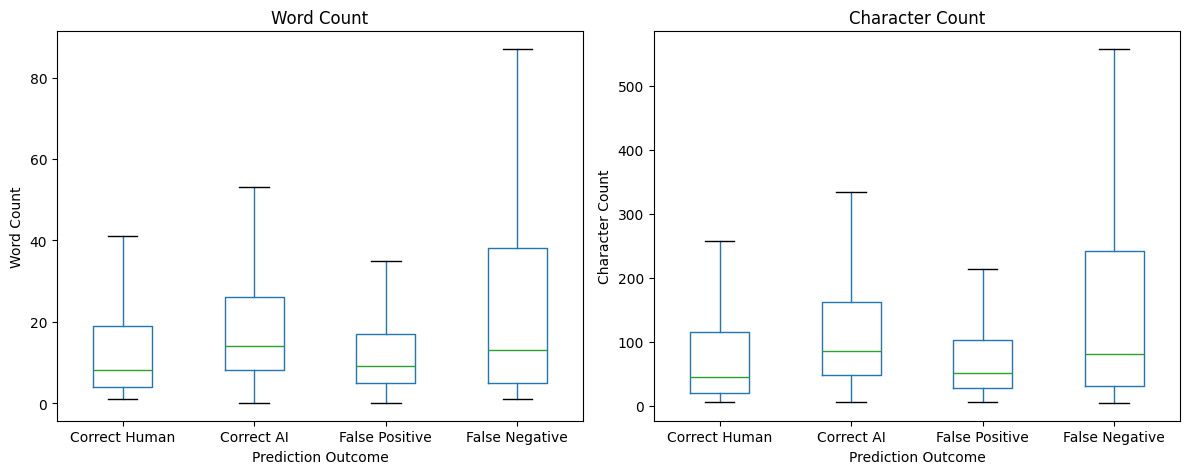

In [ ]:
# Prediction Outcome Comparison
# Text Length Features


features = [
    "word_count",
    "character_count"
]

titles = [
    "Word Count",
    "Character Count"
]

fig, axes = plt.subplots(1,2, figsize=(12,5))

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Prediction Outcome")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

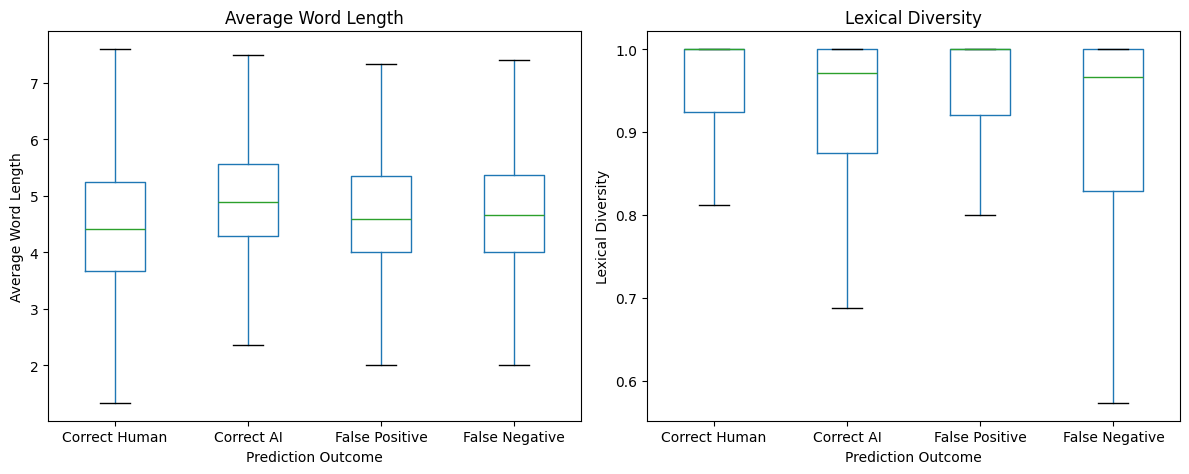

In [ ]:
# Prediction Outcome Comparison
# Lexical Features


features = [
    "average_word_length",
    "lexical_diversity"
]

titles = [
    "Average Word Length",
    "Lexical Diversity"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Prediction Outcome")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

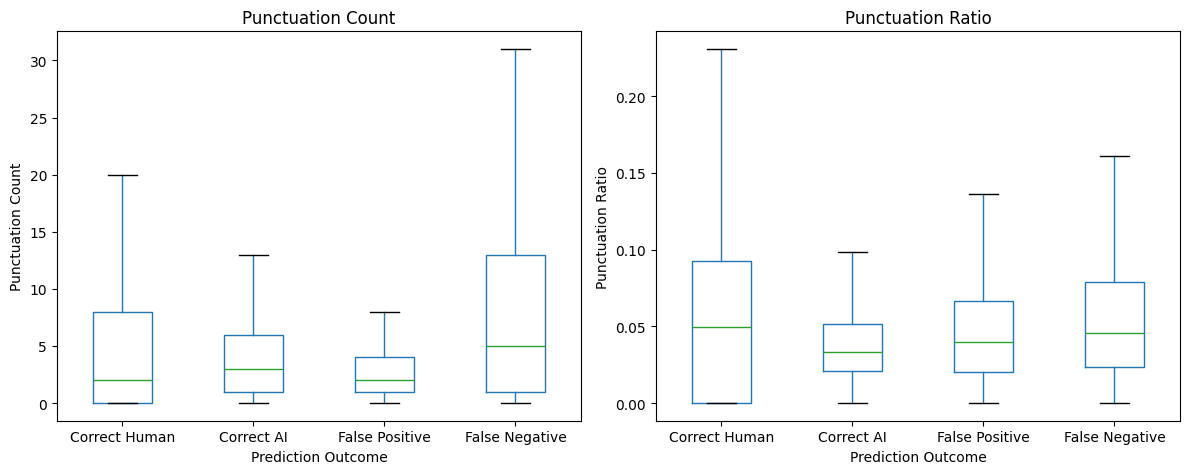

In [ ]:
# Prediction Outcome Comparison
# Punctuation Features

features = [
    "punctuation_count",
    "punctuation_ratio"
]

titles = [
    "Punctuation Count",
    "Punctuation Ratio"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Prediction Outcome")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

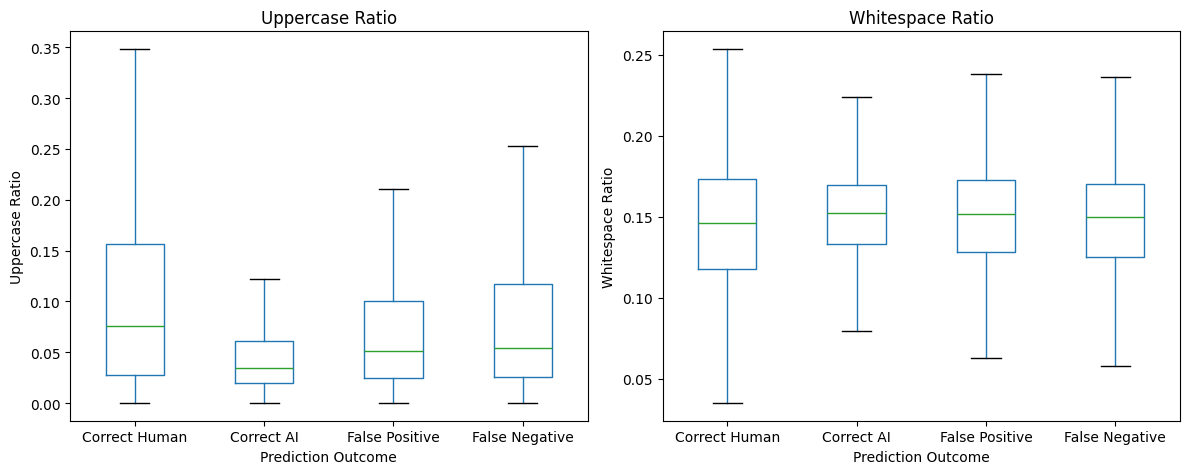

In [ ]:

# Prediction Outcome Comparison
# Formatting Features

features = [
    "uppercase_ratio",
    "whitespace_ratio"
]

titles = [
    "Uppercase Ratio",
    "Whitespace Ratio"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Prediction Outcome")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

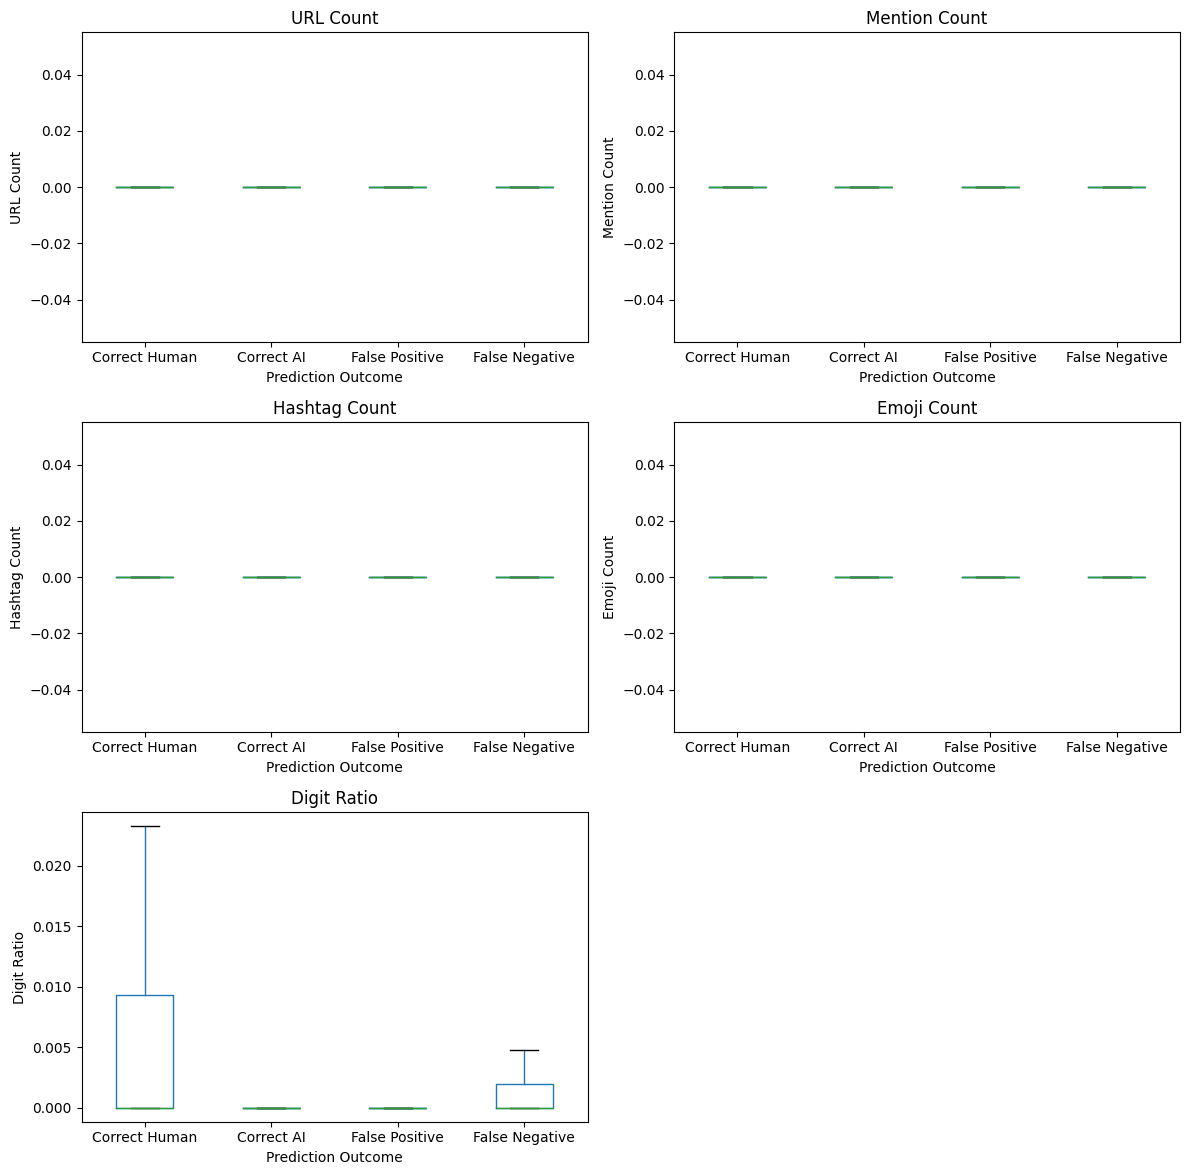

In [ ]:

# Prediction Outcome Comparison
# Social-Media Features

features = [
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

titles = [
    "URL Count",
    "Mention Count",
    "Hashtag Count",
    "Emoji Count",
    "Digit Ratio"
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    style_analysis_df.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Prediction Outcome")
    ax.set_ylabel(title)

fig.delaxes(axes[-1])

plt.suptitle("")
plt.tight_layout()
plt.show()

Grouping texts by prediction outcome revealed several consistent stylistic patterns associated with the classifier's successes and errors. Correctly classified AI-generated texts generally exhibited the longest texts and the highest average word lengths, whereas correctly classified Human-written texts tended to be shorter and displayed higher uppercase and punctuation ratios. These patterns are consistent with the class-level comparisons presented in the previous subsection.

The False Positive and False Negative groups exhibited intermediate stylistic characteristics, indicating that misclassified texts often combined properties associated with both ground-truth classes. In particular, False Negative examples displayed the greatest stylistic variability, with broader distributions for text length and punctuation usage than correctly classified AI-generated texts. They also exhibited higher average values for several social-media-related features, including URLs, hashtags, emojis and digit ratio, suggesting that these AI-generated texts more closely resembled the stylistic profile of Human-written content. False Positive examples likewise tended to resemble correctly classified Human-written texts across several stylistic features, although substantial overlap remained between the prediction-outcome groups.

Consistent with the class-level analysis, the social-media-specific features remained highly sparse across all prediction outcomes. As a result, most groups exhibited zero medians and zero interquartile ranges, causing the corresponding boxplots to appear highly compressed with substantial overlap. Although these features provided limited visual separation overall, correctly classified Human-written texts exhibited a noticeably higher digit ratio than the other prediction groups.

Overall, the results suggest that prediction errors frequently occurred for texts exhibiting stylistic characteristics that overlapped those of the two ground-truth classes rather than for texts displaying entirely distinct stylistic profiles. In particular, the broader stylistic variability observed among False Negative texts provides a plausible explanation for why these AI-generated texts were more difficult for the classifier to identify correctly. This interpretation is consistent with the SHAP analyses, which likewise indicated that misclassifications typically arise from competing evidence rather than from unique discriminative features.

## 19.6 Error-Based Style Analysis

The previous subsection examined stylistic characteristics across all prediction outcomes. This subsection focuses specifically on prediction errors by comparing False Positive and False Negative samples. False Positives correspond to Human-written texts incorrectly classified as AI-generated, whereas False Negatives represent AI-generated texts incorrectly classified as Human-written.

Comparing these two error groups provides further insight into the stylistic characteristics associated with different types of classification errors. Descriptive statistics and boxplots are first used to compare the distributions of the extracted style features. Statistical comparisons are then performed using the non-parametric Mann–Whitney U test together with Cliff's Delta effect sizes to determine whether the observed differences are both statistically and practically meaningful.

This analysis complements the SHAP error analysis by examining whether different prediction error types are associated with differences in observable stylistic characteristics.

In [ ]:
# Prepare Error Analysis Dataset

error_groups = style_analysis_df[
    style_analysis_df["prediction_outcome"].isin(
        [
            "False Positive",
            "False Negative"
        ]
    )
].copy()

print(
    error_groups["prediction_outcome"]
    .value_counts()
    .loc[lambda s: s > 0]
)

prediction_outcome
False Negative    8569
False Positive    1697
Correct AI           0
Correct Human        0
Name: count, dtype: int64


In [ ]:
# Error-group Summary Statistics

style_features = [
    "word_count",
    "character_count",
    "average_word_length",
    "lexical_diversity",
    "punctuation_count",
    "punctuation_ratio",
    "uppercase_ratio",
    "whitespace_ratio",
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

error_summary = (
    error_groups
    .groupby(
        "prediction_outcome",
        observed=True
    )[style_features]
    .agg(
        ["median","mean"]
    )
    .round(3)
)

display(error_summary)

word_count         character_count          average_word_length        lexical_diversity         \
                       median    mean          median     mean              median   mean            median   mean   
prediction_outcome                                                                                                   
False Positive            9.0  14.322            51.0   86.374               4.591  4.871             1.000  0.944   
False Negative           13.0  34.358            80.0  210.932               4.667  4.792             0.967  0.895   

                   punctuation_count         punctuation_ratio        uppercase_ratio        whitespace_ratio         \
                              median    mean            median   mean          median   mean           median   mean   
prediction_outcome                                                                                                     
False Positive                   2.0   3.735             0.040  0.049           0.051  0.086            0.152  0.149   
False Negative                   5.0  10.098             0.046  0.057           0.055  0.105            0.150  0.147   

                   url_count        mention_count        hashtag_count        emoji_count        digit_ratio         
                      median   mean        median   mean        median   mean      median   mean      median   mean  
prediction_outcome                                                                                                   
False Positive           0.0  0.053           0.0  0.000           0.0  0.184         0.0  0.269         0.0  0.005  
False Negative           0.0  0.155           0.0  0.002           0.0  0.293         0.0  0.692         0.0  0.012

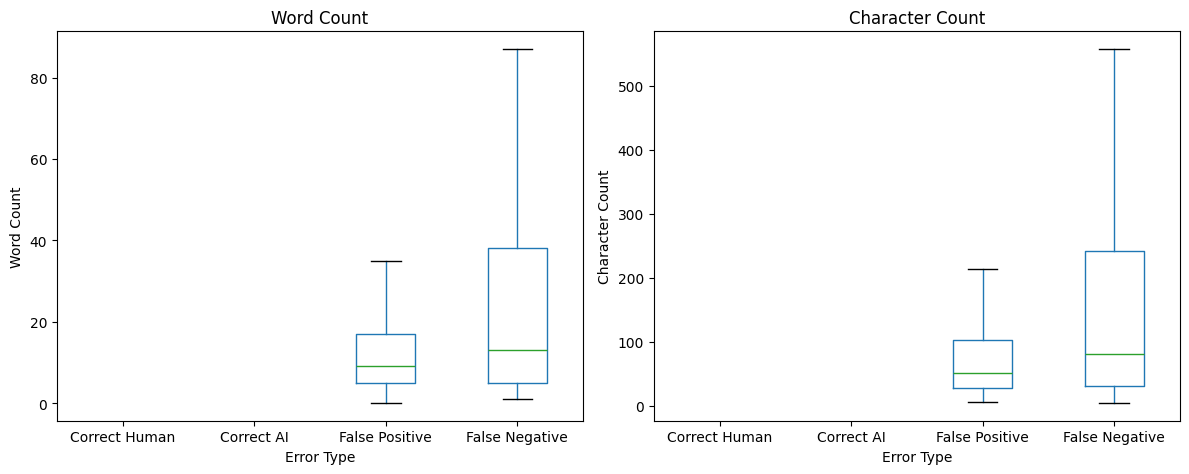

In [ ]:
# Error-group Comparison
# Text Length

features = [
    "word_count",
    "character_count"
]

titles = [
    "Word Count",
    "Character Count"
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    error_groups.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Error Type")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

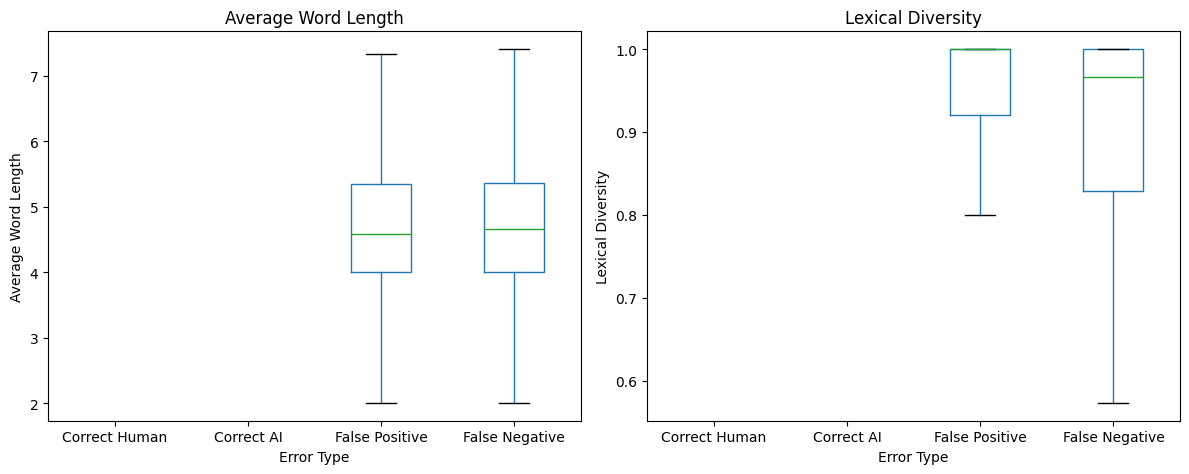

In [ ]:
# Error-group Comparison
# Lexical Features

features = [
    "average_word_length",
    "lexical_diversity"
]

titles = [
    "Average Word Length",
    "Lexical Diversity"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    error_groups.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Error Type")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

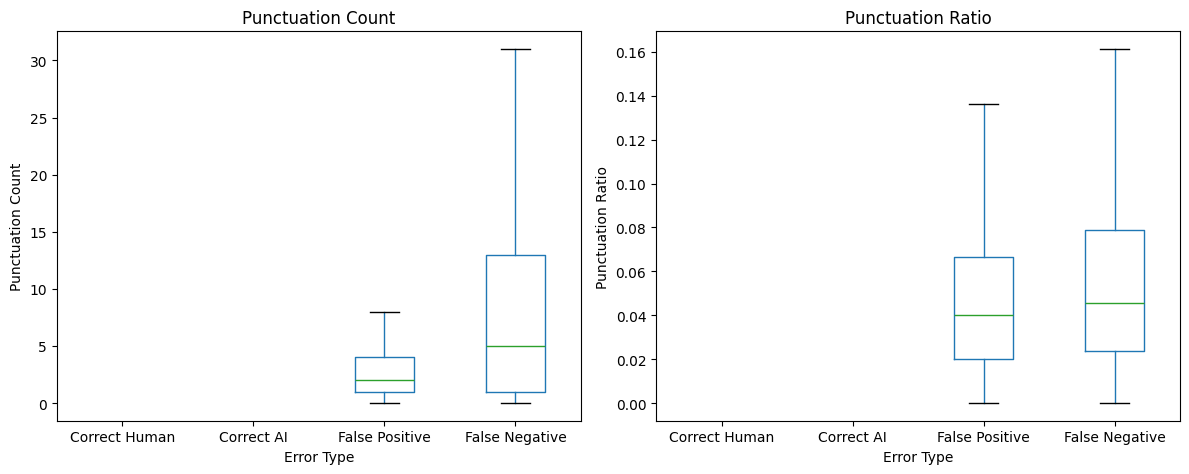

In [ ]:
# Error-group Comparison
# Punctuation Features

features = [
    "punctuation_count",
    "punctuation_ratio"
]

titles = [
    "Punctuation Count",
    "Punctuation Ratio"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    error_groups.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Error Type")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

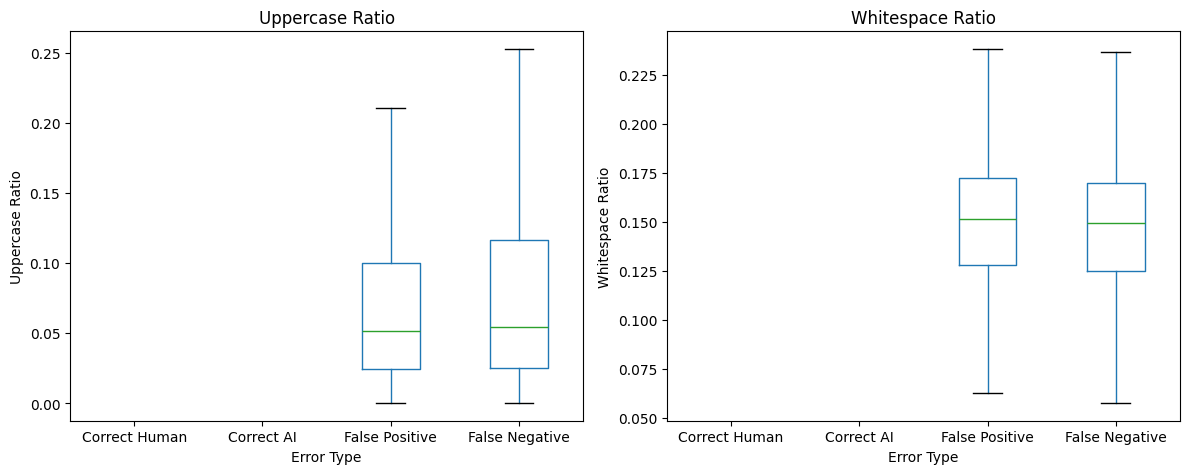

In [ ]:
# Error-group Comparison
# Formatting Features

features = [
    "uppercase_ratio",
    "whitespace_ratio"
]

titles = [
    "Uppercase Ratio",
    "Whitespace Ratio"
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    error_groups.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Error Type")
    ax.set_ylabel(title)

plt.suptitle("")
plt.tight_layout()
plt.show()

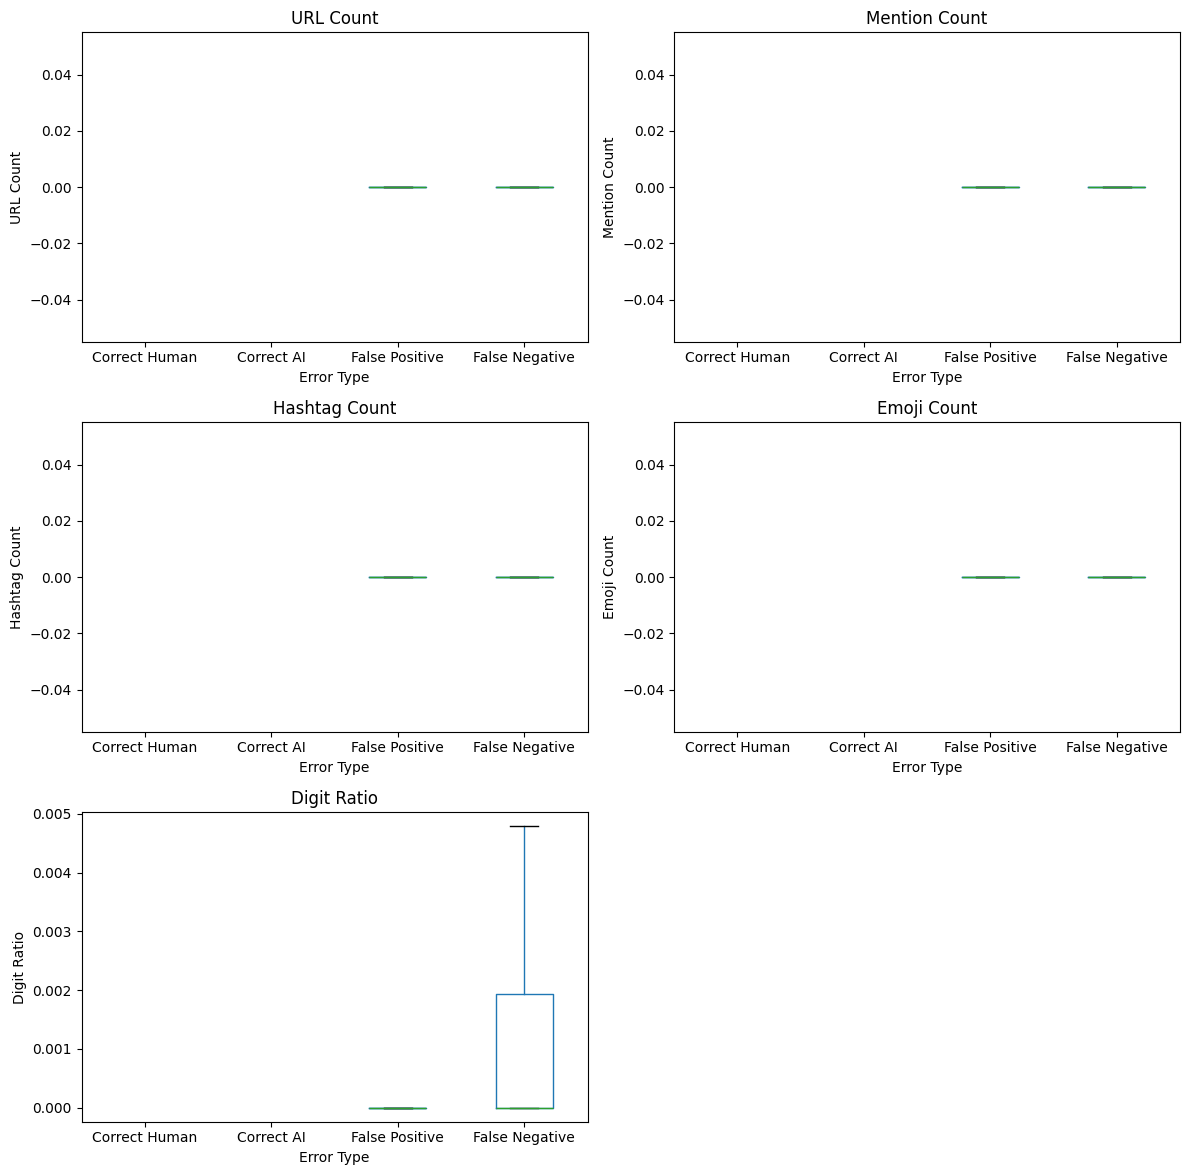

In [ ]:
# Error-group Comparison
# Social-Media Features

features = [
    "url_count",
    "mention_count",
    "hashtag_count",
    "emoji_count",
    "digit_ratio"
]

titles = [
    "URL Count",
    "Mention Count",
    "Hashtag Count",
    "Emoji Count",
    "Digit Ratio"
]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, feature, title in zip(
    axes,
    features,
    titles
):

    error_groups.boxplot(
        column=feature,
        by="prediction_outcome",
        ax=ax,
        showfliers=False,
        grid=False
    )

    ax.set_title(title)
    ax.set_xlabel("Error Type")
    ax.set_ylabel(title)

fig.delaxes(axes[-1])

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
# False Positive vs False Negative
# Statistical Comparison

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

false_positive = error_groups[
    error_groups["prediction_outcome"] == "False Positive"
]

false_negative = error_groups[
    error_groups["prediction_outcome"] == "False Negative"
]


results = []

for feature in style_features:

    fp = false_positive[feature].dropna().to_numpy()
    fn = false_negative[feature].dropna().to_numpy()

    u, p = mannwhitneyu(
        fp,
        fn,
        alternative="two-sided",
        method="asymptotic"
    )

    delta = (
        (2 * u)
        /
        (len(fp) * len(fn))
    ) - 1

    if delta > 0:
        direction = "Higher in False Positive"
    elif delta < 0:
        direction = "Higher in False Negative"
    else:
        direction = "No difference"

    results.append({

        "Feature": feature,

        "Raw p-value": p,

        "Cliff's Delta": delta,

        "Direction": direction

    })

error_statistics = pd.DataFrame(results)

reject, p_adj, _, _ = multipletests(
    error_statistics["Raw p-value"],
    method="fdr_bh"
)

error_statistics["Adjusted p-value"] = p_adj

error_statistics["Significant"] = reject

In [ ]:
# Compact Statistical Results

def interpret_delta(delta):

    delta = abs(delta)

    if delta < 0.147:
        return "Negligible"

    elif delta < 0.330:
        return "Small"

    elif delta < 0.474:
        return "Medium"

    else:
        return "Large"


error_statistics["Effect Size"] = (
    error_statistics["Cliff's Delta"]
    .apply(interpret_delta)
)

error_statistics["Cliff's Delta"] = (
    error_statistics["Cliff's Delta"]
    .round(4)
)

error_statistics["Adjusted p-value"] = (
    error_statistics["Adjusted p-value"]
    .apply(
        lambda x:
        "< 0.001"
        if x < 0.001
        else f"{x:.3f}"
    )
)

display(

    error_statistics[
        [
            "Feature",
            "Adjusted p-value",
            "Cliff's Delta",
            "Effect Size",
            "Direction",
            "Significant"
        ]
    ]

)

,Feature,Adjusted p-value,Cliff's Delta,Effect Size,Direction,Significant
0,word_count,< 0.001,-0.2130,Small,Higher in False Negative,True
1,character_count,< 0.001,-0.2053,Small,Higher in False Negative,True
2,average_word_length,0.105,-0.0248,Negligible,Higher in False Negative,False
3,lexical_diversity,< 0.001,0.2048,Small,Higher in False Positive,True
4,punctuation_count,< 0.001,-0.2777,Small,Higher in False Negative,True
5,punctuation_ratio,< 0.001,-0.0838,Negligible,Higher in False Negative,True
6,uppercase_ratio,0.007,-0.0424,Negligible,Higher in False Negative,True
7,whitespace_ratio,0.015,0.0381,Negligible,Higher in False Positive,True
8,url_count,< 0.001,-0.0891,Negligible,Higher in False Negative,True
9,mention_count,0.064,-0.0021,Negligible,Higher in False Negative,False


The error-focused analysis revealed that False Positive and False Negative samples exhibited several measurable stylistic differences despite both representing model misclassifications. False Negative samples were generally longer, with significantly higher word counts (Cliff's Δ = −0.213) and character counts (Δ = −0.205), indicating that AI-generated texts incorrectly classified as Human-written tended to contain substantially more textual content than Human-written texts incorrectly classified as AI-generated.

False Negative samples also displayed higher punctuation counts (Δ = −0.278), whereas False Positive samples exhibited slightly higher lexical diversity (Δ = 0.205). These findings indicate that the two error types differed primarily in text length, punctuation usage and lexical diversity rather than across the full range of extracted stylistic characteristics.

The remaining style features produced only negligible effect sizes despite several statistically significant differences. Average word length and mention count showed no statistically significant differences after false discovery rate correction, indicating that these features contributed little to distinguishing the two error types. Punctuation ratio, uppercase ratio, whitespace ratio, URLs, hashtags, emojis and digit ratio likewise exhibited only negligible practical differences between False Positive and False Negative samples.

Consistent with the previous style analyses, the social-media-specific features remained highly sparse in both error groups. Consequently, most of the corresponding boxplots exhibited zero medians and zero interquartile ranges, appearing highly compressed and providing limited visual separation between the two error types.

Overall, the results indicate that False Positive and False Negative errors differ primarily in text length, punctuation count and lexical diversity, while the remaining stylistic characteristics exhibit only negligible practical differences. Consistent with the preceding SHAP analyses, these findings suggest that different prediction errors arise from distinct combinations of common stylistic characteristics rather than from unique stylistic signatures associated with either error type.

## 19.7 Style Analysis Summary

This section investigated whether Human-written and AI-generated texts exhibit measurable stylistic differences beyond the contextual patterns identified through SHAP explainability. A complementary style-level analysis was conducted using thirteen interpretable features capturing text length, lexical characteristics, punctuation usage, formatting behaviour and social-media-specific content.

The descriptive analysis demonstrated substantial stylistic diversity across the multilingual benchmark test set while revealing that several social-media-specific features, including URLs, hashtags and emojis, were highly sparse. Despite this sparsity, class-level comparisons showed that AI-generated texts were generally longer and contained slightly longer words, whereas Human-written texts exhibited higher lexical diversity, greater uppercase usage and more frequent inclusion of platform-specific elements such as URLs, hashtags, emojis and numerical content. Statistical testing confirmed that these differences were statistically significant, although most individual features exhibited only negligible to small effect sizes, indicating that the practical stylistic separation between the two classes remained limited.

Analysing prediction outcomes further showed that correctly classified AI-generated texts generally exhibited the longest texts and highest average word lengths, whereas misclassified samples tended to occupy intermediate positions between the two classes across several stylistic features. The dedicated error analysis further showed that False Negative samples tended to be longer and contained more punctuation, while False Positive samples exhibited slightly greater lexical diversity. However, the relatively small effect sizes indicated that the two error types differed primarily in subtle variations of common stylistic characteristics rather than fundamentally different writing styles.

Overall, the style-level analysis provides an interpretable description of the observable writing characteristics present within the benchmark dataset and complements the token-level explanations obtained through SHAP. Although several consistent stylistic differences were identified, the substantial overlap between Human-written and AI-generated texts indicates that no individual stylistic feature provides sufficient discriminative power for reliable AI-generated text detection. Instead, the findings suggest that successful detection relies on combining multiple complementary stylistic and contextual cues, supporting the use of transformer-based contextual representations capable of modelling more complex linguistic patterns than can be captured by individual observable style features alone.